# ToE Demonstartion on GMST

This notebook is designed to be both technically reproducible and presentation-friendly.


<div class="nb-card nb-accent">
  <strong>Notebook Goal</strong><br>
  Build a transparent, reproducible <em>Time of Emergence</em> workflow on ACCESS ensembles, compare multiple emergence metrics, and generate publication-ready summary figures.
</div>

<div class="nb-card nb-info">
  <strong>What You Will Get</strong><br>
  <span class="nb-chip">GMST anomalies (members + median)</span>
  <span class="nb-chip">S/N families (incl. piControl noise)</span>
  <span class="nb-chip">KS / t-test / overlap metrics</span>
  <span class="nb-chip">Probability Ratio (PR)</span>
  <span class="nb-chip">Merged ToE estimates</span>
  <span class="nb-chip">Core toe_plots panel + helper figures</span>
</div>


## Notebook Flow 

<div class="nb-flow">
<b>Step 1:</b> Load ACCESS and piControl datasets  
<b>Step 2:</b> Compute global-mean series and base-period anomalies  
<b>Step 3:</b> Build S/N methods (trend-fit, anomaly, ensemble-median, piControl-noise)  
<b>Step 4:</b> Build statistical and overlap metrics + PR  
<b>Step 5:</b> Apply permanent-exceedance rules to infer ToE year by metric  
<b>Step 6:</b> Plot core ToE panel and communication figures
</div>

### Metric Logic Summary

- **S/N metrics:** emergence when \(|S/N| \ge 1\)
- **KS / t-test:** emergence when p-values cross threshold (`PVALUE_THESHOLD1`)
- **Overlap metrics (`frac`, `hd`):** emergence from overlap/distance threshold (`OVERLAP_THRESHOLD`)
- **PR metric:** emergence when \(PR \ge 2\)
- **`nn` metric:** emergence via permanent boolean exceedance


## 1) Imports and Environment


In [1]:
# Standard library
import os
import sys
import warnings
from importlib import reload
from functools import partial
from typing import Optional, Tuple


In [2]:
# Third-party scientific stack
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from scipy.stats import ks_2samp
from statsmodels.distributions.empirical_distribution import ECDF


mkdir -p failed for path /scratch/v45/dr4292/tmp/.cache/matplotlib: [Errno 13] Permission denied: '/scratch/v45/dr4292/tmp/.cache'
Matplotlib created a temporary cache directory at /jobfs/162918510.gadi-pbs/matplotlib-p3kbjw9c because there was an issue with the default path (/scratch/v45/dr4292/tmp/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
# Local project imports
sys.path.append(os.path.join(os.getcwd(), 'Documents', 'time_of_emergene_drafts'))
sys.path.append(os.path.join(os.getcwd(), 'Documents', 'time_of_emergene_drafts', 'src'))

import climate_utils
import my_stats
import toe_plots
import toe_calc as toe
import toe_constants as toe_const
# import open
from toe_constants import PVALUE_THESHOLD1, OVERLAP_THRESHOLD
import constants

In [4]:
warnings.filterwarnings('ignore')
xr.set_options(display_expand_attrs=False)
xr.set_options(display_expand_data=False)

In [5]:
# client.close()

In [6]:
from dask.distributed import Client, wait
client = Client(threads_per_worker=1, memory_limit=None, n_workers=4)

client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 0 B
Status: running,Using processes: True
Comm: tcp://127.0.0.1:36669,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38219,Total threads: 1
Dashboard: /proxy/40393/status,Memory: 0 B
Nanny: tcp://127.0.0.1:37489,


## 2) Analysis Configuration


In [7]:
base_period_tuple = (1850, 1880)
window = 30

pr_event_quantile = 0.95
pr_window = window

In [8]:
base_period_length = base_period_tuple[-1] - base_period_tuple[0]
base_period_length

30

### Configuration Notes

- `base_period_tuple` defines the reference climate used to center anomalies.
- `window` is the moving-window length used by several statistics.
- PR settings:
  - `pr_event_quantile` defines the exceedance event threshold from the base period.
  - `pr_window` is the rolling window used to estimate time-varying event probability.


## 3) Load ACCESS + piControl


In [9]:
# # ACCESS
# model = 'access'
# experiment = 'ssp585'
# variable = 'tas'#'tas' #pr
# dataset_name = f'{model}_{experiment}'

In [10]:
# CHUNK_DICT = {
#     'best': {'time':-1, 'lat': 180//10, 'lon': 360//10},
#     'access': {'time':-1, 'member':1, 'lat': 72//4, 'lon':-1}
# }
# chunks = CHUNK_DICT[model]

In [11]:
# FILE_NAME = f'/g/data/w40/ab2313/time_of_emergence/{dataset_name}_{variable}.zarr'
# print(FILE_NAME)
# ds = xr.open_dataset(FILE_NAME, engine='zarr', chunks=chunks, use_cftime=True)[variable].persist()
# wait(ds);

In [12]:
import open_data
ds = open_data.open_best()

Opening best dataset from - /g/data/w40/ab2313/time_of_emergence/best/Land_and_Ocean_LatLong1_time_chunk.zarr


  -- overriding time to use cftime
  -- resampling to yearly mean


In [13]:
ds = ds.drop('height', errors='ignore')

In [14]:
# PI_CHUNKS = {'time':-1, 'lat':'auto', 'lon':'auto'}
# version = '04'
# PICONTROL_PATH = os.path.join(constants.TOE_SAVE_DIR, f'access_ssp585_tas_(1880_1909)_{version}/piControl_tas.zarr')
# pi_ds = xr.open_dataset(PICONTROL_PATH, engine='zarr', use_cftime=True).chunk(PI_CHUNKS).persist()['tas']
# wait(pi_ds);
# pi_ds

In [15]:
# Keep this logic exactly as requested
if 'member' in list(ds.coords):
    plotting_dict = {'hue': 'member', 'add_legend': False}
    member_kwargs = {'member':0}
else:
    plotting_dict = {}
    member_kwargs = {}

### Data Expectations

This notebook assumes ACCESS-like ensemble structure with a `member` dimension.

For `pi_ds`, you only need a dataset that can be reduced to a global mean and has enough samples to estimate variability noise.


## 4) Global Mean and Base-Period Anomalies


In [16]:
# Global mean (ensemble members retained)
smean_ds = climate_utils.weighted_lat_lon_mean(ds)

In [17]:
if 'member' in list(smean_ds.coords):
    smean_ds = smean_ds.chunk({'time':-1, 'member': 10}).persist()
else:
    smean_ds = smean_ds.compute()

In [18]:
smean_ds

<xarray.DataArray 'temperature' (time: 175)> Size: 700B
-0.3587 -0.2924 -0.2442 -0.26 -0.2722 ... 1.025 0.8704 0.9127 1.204 1.273
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [19]:
# pi_smean_ds = climate_utils.weighted_lat_lon_mean(pi_ds).compute()

### Why Global Mean First?

The ToE workflow here is intentionally 1D in time:

1. reduce each member to global mean,
2. build anomaly time series,
3. run distribution and threshold metrics consistently across methods.

This keeps all methods comparable and makes interpretation straightforward.


In [20]:
# Restrict to configured start year
smean_ds = smean_ds.sel(time=smean_ds.time.dt.year >= base_period_tuple[0])

In [21]:
# Base-period subset
base_period_ds = smean_ds.where(
    smean_ds.time.dt.year.isin(np.arange(*base_period_tuple)),
    drop=True,
)
base_period_ds

<xarray.DataArray 'temperature' (time: 30)> Size: 120B
-0.3587 -0.2924 -0.2442 -0.26 -0.2722 ... -0.3081 -0.3222 0.0477 0.1164 -0.1994
Coordinates:
  * time     (time) object 240B 1850-12-31 00:00:00 ... 1879-12-31 00:00:00

In [22]:
# Convert to anomalies relative to base-period mean
smean_anom_ds = smean_ds - base_period_ds.mean(dim='time').persist()
base_period_anom_ds = base_period_ds - base_period_ds.mean(dim='time').persist()

wait(smean_anom_ds);
wait(base_period_anom_ds);

In [23]:
base_period_anom_ds

<xarray.DataArray 'temperature' (time: 30)> Size: 240B
-0.08897 -0.02272 0.02549 0.009678 -0.002541 ... -0.05252 0.3174 0.3861 0.07033
Coordinates:
  * time     (time) object 240B 1850-12-31 00:00:00 ... 1879-12-31 00:00:00

### Checkpoint: Preprocessing Sanity Check

Use this block to verify:
- member count,
- time span,
- anomaly centering,
- median extraction.


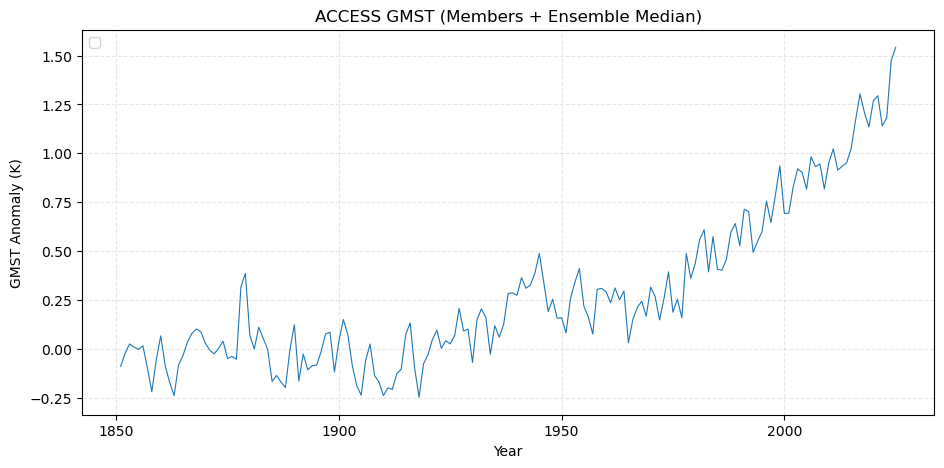

In [24]:
# Quick visual check: all members + median
fig, ax = plt.subplots(figsize=(11, 5))
smean_anom_ds.plot(ax=ax, linewidth=0.8, add_legend=False, **plotting_dict)
ax.set_xlabel('Year')
ax.set_ylabel('GMST Anomaly (K)')
ax.set_title('ACCESS GMST (Members + Ensemble Median)')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(loc='upper left')

In [25]:
print('smean_anom_ds dims:', smean_anom_ds.dims)
print('smean_anom_ds shape:', tuple(smean_anom_ds.shape))

# base-period mean should be near zero after anomaly conversion
base_mean_check = float(base_period_anom_ds.mean(dim=['time']).values)
print('base-period mean (should be ~0):', round(base_mean_check, 6))

smean_anom_ds dims: ('time',)
smean_anom_ds shape: (175,)
base-period mean (should be ~0): 0.0


## 5) Signal-to-Noise Construction


### Signal-to-Noise Strategy

We compute multiple S/N variants to stress-test emergence timing:

- trend-fit S/N (`LOWESS`, rolling mean, polynomial),
- anomaly-scaled S/N (`sn_anom_base`),
- ensemble-median S/N using historical internal variability (`sn_ens_med_full`),
- ensemble-median S/N using piControl variability (`sn_ens_med_pi`).


In [26]:
smean_anom_ds

<xarray.DataArray 'temperature' (time: 175)> Size: 1kB
-0.08897 -0.02272 0.02549 0.009678 -0.002541 ... 1.295 1.14 1.182 1.474 1.543
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [27]:
# Smooth components on median trajectory
# LOWESS
lowess_ds = my_stats.trend_fit(smean_anom_ds, 'LOWESS', lowess_window=41)
lowess_ds.name = 'lowess'

In [28]:
# Polynomial trend
poly4_ds = my_stats.trend_fit(smean_anom_ds, 'POLYNOMIAL', order=4)
poly4_ds.name = 'poly'

In [29]:
# ENs mean trend
# ens_mean_ds = smean_anom_ds.median(dim='member')
# ens_mean_ds.name = 'ens_med'

In [30]:
# Rolling 20 year trend
rolling_20_ds = smean_anom_ds.rolling(time=20, center=True, min_periods=19).mean()
rolling_20_ds.name = 'mean'

In [31]:
# Merge and compute residual/noise

signal_ds = xr.merge(
    [rolling_20_ds, poly4_ds, lowess_ds
     # , ens_mean_ds
    ]
).to_array('signal_type')

ds_no_trend = smean_anom_ds - signal_ds

In [32]:
signal_ds.sel(signal_type='lowess')

<xarray.DataArray (time: 175)> Size: 1kB
-0.05297 -0.05059 -0.04818 -0.04573 -0.04325 ... 1.244 1.267 1.292 1.316 1.34
Coordinates:
  * time         (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00
    signal_type  <U6 24B 'lowess'

In [33]:
# pi_noise_ds = pi_smean_ds.std(dim='time').compute()
base_noise_ds = ds_no_trend.isel(time=slice(0, 30)).std(dim='time').compute()
full_noise_ds = ds_no_trend.std(dim='time').compute()

### Trend Decomposition

This plot confirms the median GMST series and each fitted signal component.


In [34]:
sn_lowess_full_ds = signal_ds.sel(signal_type='lowess')/full_noise_ds.sel(signal_type='lowess')
sn_lowess_full_ds.name = 'sn_lowess_full'
# sn_lowess_full_ds['signal_type'] = 'sn_lowess_full'

In [35]:
# sn_lowess_pi_ds = signal_ds.sel(signal_type='lowess')/pi_noise_ds
# sn_lowess_pi_ds.name = 'sn_lowess_pi'

In [36]:
# S/N from anomaly scaling
sn_anom_ds = smean_anom_ds / base_noise_ds.sel(signal_type='lowess')
sn_anom_ds.name = 'sn_anom_base'

In [37]:
# S/N from smooth/noise
sn_base_ds = signal_ds / base_noise_ds
sn_base_ds = sn_base_ds.assign_coords(
    signal_type=[f'sn_{var}_base' for var in sn_base_ds['signal_type'].values]
)

In [38]:
sn_base_ds

<xarray.DataArray (signal_type: 3, time: 175)> Size: 4kB
nan nan nan nan nan nan nan nan ... 9.882 10.08 10.28 10.47 10.67 10.87 11.07
Coordinates:
  * signal_type  (signal_type) <U14 168B 'sn_mean_base' ... 'sn_lowess_base'
  * time         (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [39]:
sn_multi_ds = xr.merge(
    [sn_base_ds.to_dataset('signal_type'), 
     sn_lowess_full_ds.to_dataset(),
     sn_lowess_full_ds.to_dataset(),
     # sn_lowess_pi_ds.to_dataset(),
     sn_anom_ds.to_dataset()
    ]).drop_vars(['signal_type', 'height'], errors='ignore')

In [40]:
sn_multi_ds = sn_multi_ds.to_array(dim='signal_type')

In [41]:
sn_multi_ds

<xarray.DataArray (signal_type: 5, time: 175)> Size: 7kB
nan nan nan nan nan nan nan nan ... 9.98 9.38 10.48 10.7 9.421 9.77 12.18 12.75
Coordinates:
  * signal_type  (signal_type) object 40B 'sn_mean_base' ... 'sn_anom_base'
  * time         (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [42]:
# sn_multi_ds = xr.concat(
#     [sn_base_ds, sn_lowess_full_ds, sn_lowess_full_ds, sn_lowess_pi_ds, sn_anom_ds],
#     dim='signal_type')

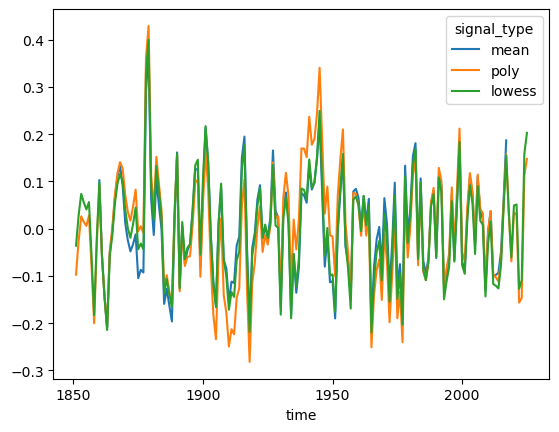

In [43]:
ds_no_trend.isel(**member_kwargs).plot(hue='signal_type');

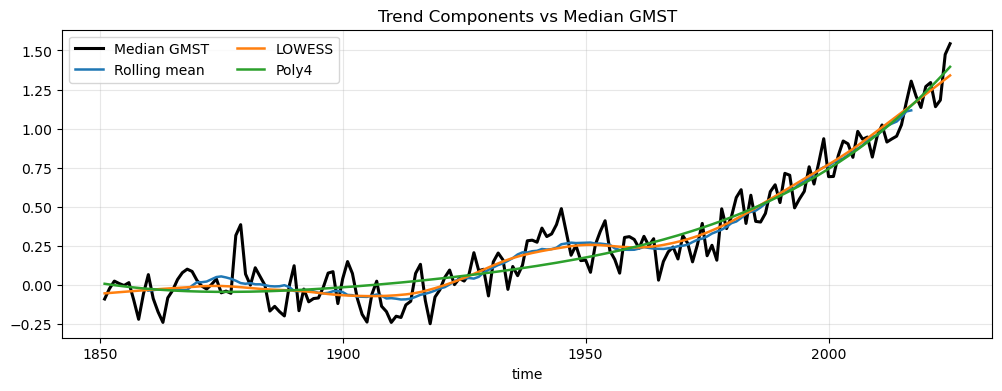

In [44]:
fig, ax = plt.subplots(figsize=(12, 4))
smean_anom_ds.plot(ax=ax, color='black', linewidth=2.2, label='Median GMST')

signal_ds.isel(**member_kwargs).sel(signal_type='mean').plot(ax=ax, linewidth=1.8, label='Rolling mean')
signal_ds.isel(**member_kwargs).sel(signal_type='lowess').plot(ax=ax, linewidth=1.8, label='LOWESS')
signal_ds.isel(**member_kwargs).sel(signal_type='poly').plot(ax=ax, linewidth=1.8, label='Poly4')

ax.set_title('Trend Components vs Median GMST')
ax.grid(alpha=0.3)
ax.legend(ncol=2)


### Interpreting S/N

Generic interpretation used in this notebook:

- `S/N >= 1`: unusual
- `S/N >= 2`: unfamiliar
- `S/N >= 3`: unknown
- `S/N >= 5`: inconceivable

These labels are visualization aids and can be changed if your framing differs.


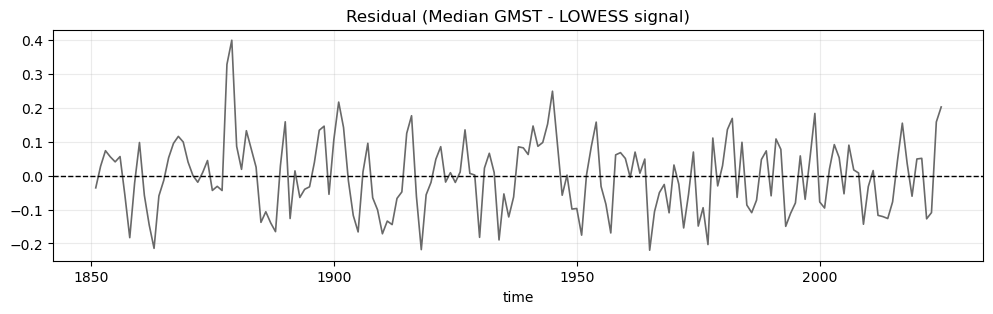

In [45]:
fig, ax = plt.subplots(figsize=(12, 3))
ds_no_trend.sel(signal_type='lowess').plot(ax=ax, color='dimgray', linewidth=1.2)
ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.set_title('Residual (Median GMST - LOWESS signal)')
ax.grid(alpha=0.25)


In [46]:
# # S/N with ACCESS internal variability noise
# median_noise = base_period_anom_ds.std(dim=['member', 'time'])
# ds_median_sn = smean_anom_ds / median_noise
# ds_median_sn.name = 'sn_ens_med_full'
# ds_median_sn = ds_median_sn.expand_dims(dim={'method': ['sn_ens_med_full']})


In [47]:
# # S/N with piControl variability noise
# pi_smean_ds_raw = climate_utils.weighted_lat_lon_mean(pi_ds).compute()
# pi_noise = pi_smean_ds_raw.std(dim=['member', 'time'])
# ds_median_sn_pi = smean_anom_ds / pi_noise
# ds_median_sn_pi.name = 'sn_ens_med_pi'
# ds_median_sn_pi = ds_median_sn_pi.expand_dims(dim={'method': ['sn_ens_med_pi']})


In [48]:
def format_timeseries_ax(ax):
    start_year = int(best_ds_smean_median.time.dt.year.min())
    end_year = int(best_ds_smean_median.time.dt.year.max())
    tick_start = 25 * (start_year // 25)

    ax.set_xlim(start_year - 3, end_year + 1)
    ax.set_xticks(np.arange(tick_start, end_year + 1, 25))
    ax.set_xlabel('Year', fontsize=SHCEMATIC_FIGURE_DICT['labels'])

    # Keep visual style consistent with the polished figure theme
    ax.set_facecolor('#f1f1f1')
    ax.grid(True, linestyle='-', color='#c6c6c6', alpha=0.55)


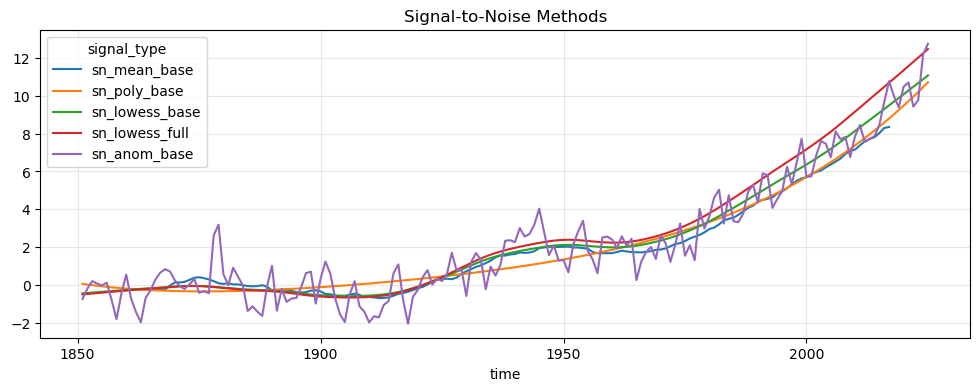

In [49]:
# Diagnostic plot
fig, ax = plt.subplots(figsize=(12, 4))
sn_multi_ds.isel(member_kwargs).plot(ax=ax, hue='signal_type')
ax.set_title('Signal-to-Noise Methods')
ax.grid(alpha=0.3)

## 6) Statistical / Overlap / PR Metrics


### Metric Families

- **p-value metrics** (`ks`, `ttest`) detect distributional shifts.
- **overlap metrics** (`frac`, `hd`) quantify distribution separation.
- **new normal** (`nn`) tracks sustained exceedance over baseline maximum.
- **probability ratio** (`pr`) tracks multiplicative change in event likelihood.


In [50]:
import toe_calc_variations
import toe_calc

In [51]:
smean_anom_ds

<xarray.DataArray 'temperature' (time: 175)> Size: 1kB
-0.08897 -0.02272 0.02549 0.009678 -0.002541 ... 1.295 1.14 1.182 1.474 1.543
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [52]:
data_ds_window = (smean_anom_ds
                  .rolling(time=window, center=True, min_periods=window)
                  .construct('window_dim')
                  .persist()
                 ) 

base_period_window_ds = (base_period_anom_ds
                         .rename({'time':'window_dim'})
                         .persist()
                        )
wait(data_ds_window);
wait(base_period_window_ds);

### p-value methods

Both lines should show when each test starts indicating a statistically unusual state.


In [53]:
%%time
ks_ds = toe_calc_variations.ks(data_ds_window, base_period_window_ds)

CPU times: user 114 ms, sys: 6.41 ms, total: 121 ms
Wall time: 110 ms


In [54]:
ttest_ds = toe_calc_variations.ttest(data_ds_window, base_period_window_ds)

In [55]:
ks_ds

<xarray.DataArray 'ks' (time: 175)> Size: 1kB
0.4586 0.5445 0.6691 0.8159 0.8957 ... 1.061e-13 2.736e-13 7.296e-13 2.017e-12
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

In [56]:
ttest_ds

<xarray.DataArray 'ttest' (time: 175)> Size: 1kB
0.08229 0.1064 0.1558 0.2301 0.3056 ... 4.647e-28 1.224e-27 3.433e-27 1.701e-27
Coordinates:
  * time     (time) object 1kB 1850-12-31 00:00:00 ... 2024-12-31 00:00:00

###  Overlap Metrics

`frac` typically decreases with emergence; `hd` typically increases.


In [57]:
data_max = smean_anom_ds.max().persist().values.item()
data_min = smean_anom_ds.min().persist().values.item()
x = toe_calc.create_x(bmin=data_min, bmax=data_max, num_points=1000)
print(x[:5], x[-5:], sep='\n')

[-0.84364016 -0.8406542  -0.83766824 -0.83468228 -0.83169631]
[2.12739114 2.1303771  2.13336306 2.13634903 2.13933499]


In [58]:
base_period_kde = toe_calc_variations._create_base_period_kde(base_period_anom_ds, x)

In [59]:
base_period_kde

<xarray.DataArray 'temperature' (x: 1000)> Size: 8kB
7.759e-125 1.285e-123 2.098e-122 3.379e-121 5.366e-120 ... 0.0 0.0 0.0 0.0 0.0
Dimensions without coordinates: x

In [60]:
frac_geom_ds = toe_calc_variations.fga(base_period_kde=base_period_kde, data_ds_window=data_ds_window)
hd_ds = toe_calc_variations.hd(base_period_kde=base_period_kde, data_ds_window=data_ds_window)

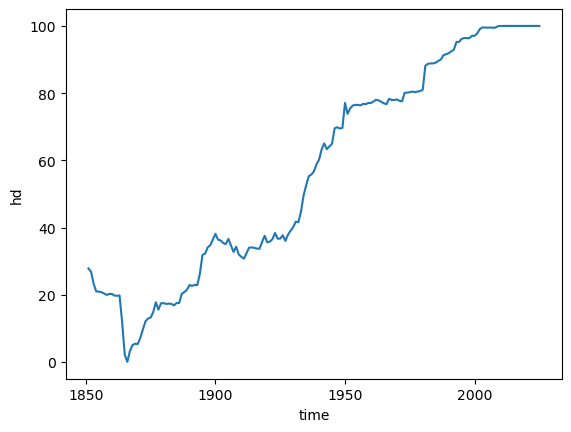

In [61]:
hd_ds.plot(**plotting_dict);

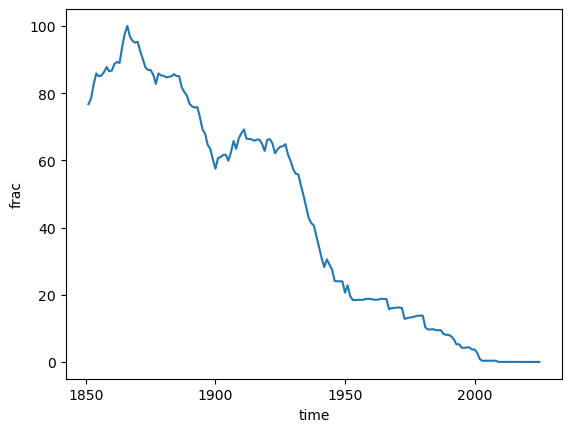

In [62]:
frac_geom_ds.plot(**plotting_dict);

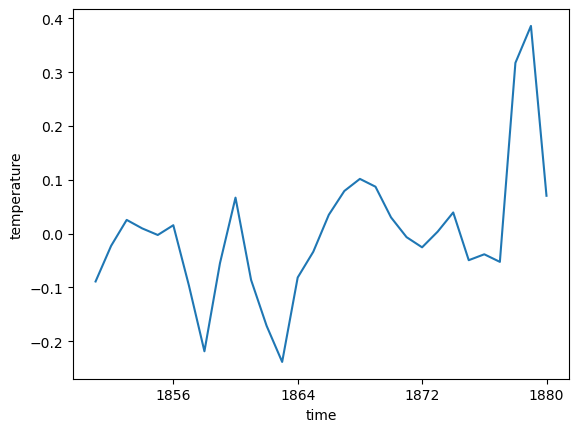

In [63]:
base_period_anom_ds.plot(**plotting_dict);

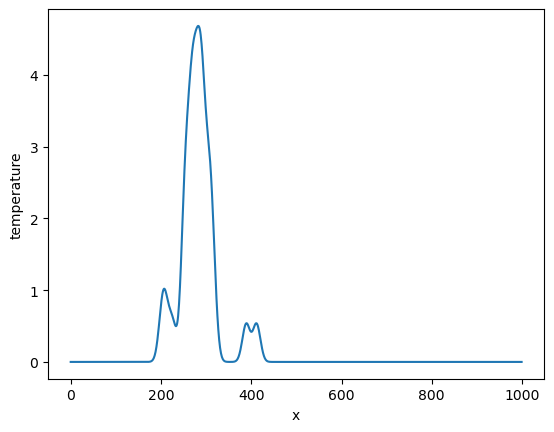

In [64]:
base_period_kde.plot(**plotting_dict);

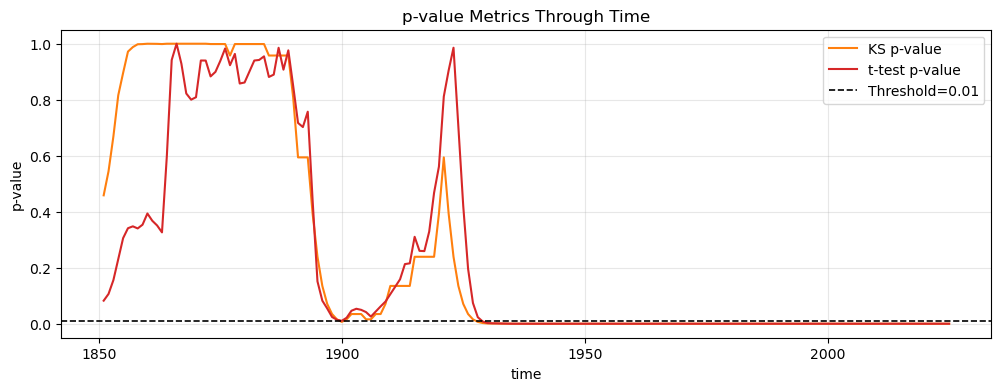

In [65]:
fig, ax = plt.subplots(figsize=(12, 4))
ks_ds.isel(member_kwargs).plot(ax=ax, label='KS p-value', color='tab:orange')
ttest_ds.isel(member_kwargs).plot(ax=ax, label='t-test p-value', color='tab:red')
ax.axhline(PVALUE_THESHOLD1, linestyle='--', color='k', linewidth=1.2, label=f'Threshold={PVALUE_THESHOLD1}')
ax.set_title('p-value Metrics Through Time')
ax.set_ylabel('p-value')
ax.grid(alpha=0.3)
ax.legend()


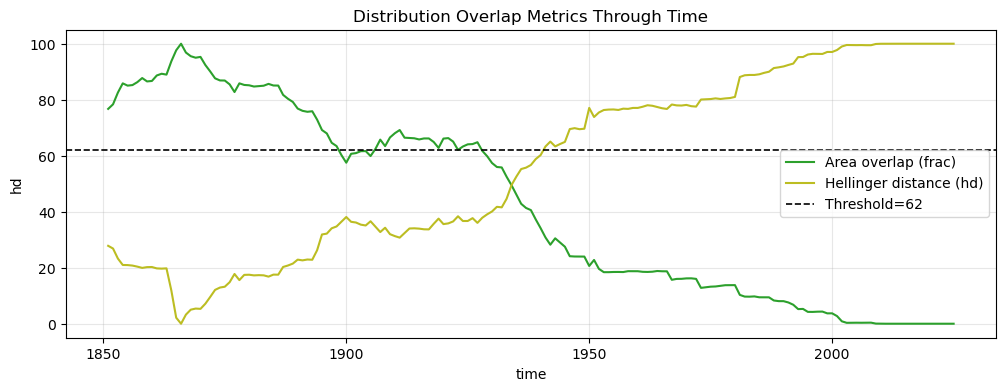

In [66]:
fig, ax = plt.subplots(figsize=(12, 4))
frac_geom_ds.isel(member_kwargs).plot(ax=ax, label='Area overlap (frac)', color='tab:green')
hd_ds.isel(member_kwargs).plot(ax=ax, label='Hellinger distance (hd)', color='tab:olive')
ax.axhline(OVERLAP_THRESHOLD, linestyle='--', color='k', linewidth=1.2, label=f'Threshold={OVERLAP_THRESHOLD}')
ax.set_title('Distribution Overlap Metrics Through Time')
ax.grid(alpha=0.3)
ax.legend()


### PR Construction

The first panel tracks rolling event probability (`p1`), and the second panel tracks `PR = p1/p0`.


### Probability Ratio (PR) Definition

Define event threshold from base climate quantile (`q=0.95` by default).

\[
PR(t) = rac{p_1(t)}{p_0}
\]

- `p0`: base-period event probability
- `p1(t)`: rolling event probability over time

`PR = 1` means no change in event likelihood; `PR > 1` means increased likelihood.


In [67]:
# Threshold from base period
pr_threshold = base_period_anom_ds.quantile(pr_event_quantile, dim='time')

# Event occurrence over full dataset
pr_event_da = xr.where(smean_anom_ds > pr_threshold, 1.0, 0.0)

# Base probability per member (from base period only)
p0 = xr.where(base_period_anom_ds > pr_threshold, 1.0, 0.0).mean(dim='time')
p0_safe = xr.where(p0 > 1e-6, p0, 1e-6)

# Rolling probability over full time series (per member)
p1 = pr_event_da.rolling(time=pr_window, center=True).mean()

# Probability ratio per member
pr_ds = (p1 / p0_safe).rename('pr')

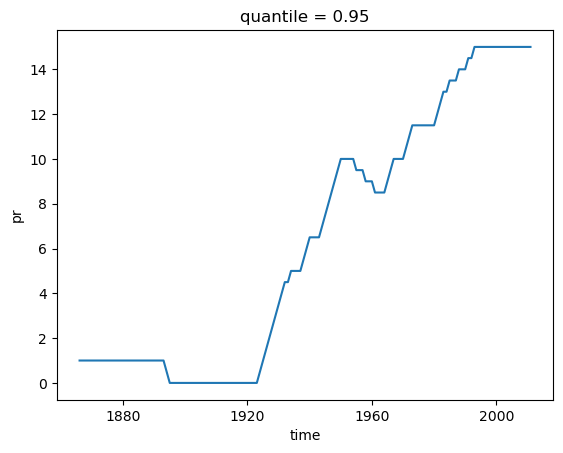

In [68]:
pr_ds.plot(**plotting_dict);

In [69]:
# new normal metric
base_max_value = base_period_anom_ds.max().values.item()
new_normal_ds = xr.where(rolling_20_ds > base_max_value, 1, 0)

In [70]:
pr_ds = pr_ds.compute()

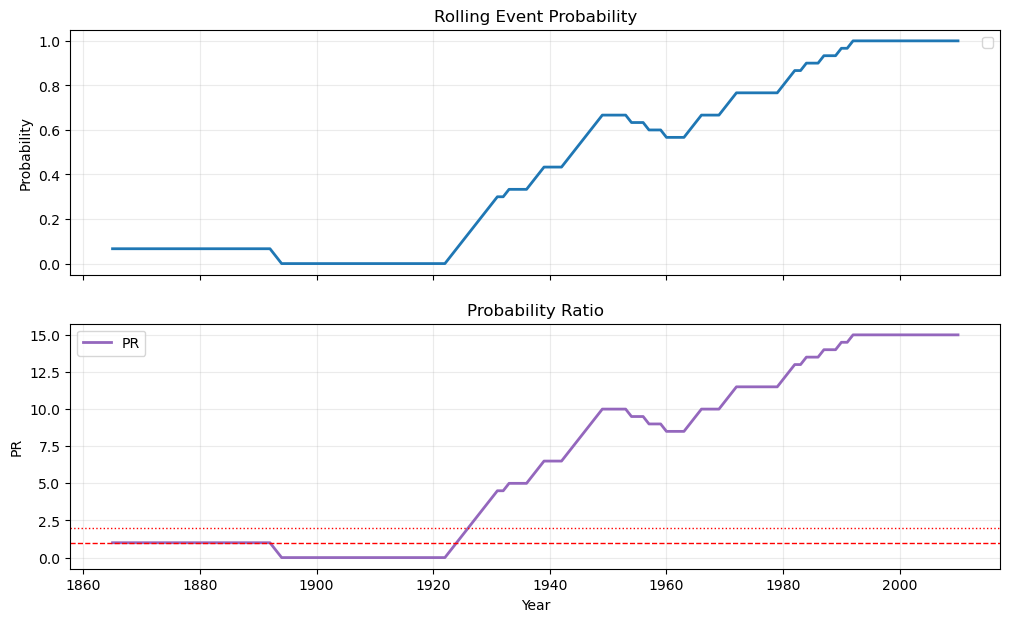

In [71]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

years = p1.time.dt.year.values
ax1.plot(years, p1.isel(member_kwargs).values, color='tab:blue', linewidth=2)
# ax1.axhline(p0.isel(member_kwargs).values, color='tab:orange', linestyle='--', linewidth=1.5, label=f'p0={p0:.3f}')
ax1.set_ylabel('Probability')
ax1.set_title('Rolling Event Probability')
ax1.grid(alpha=0.25)
ax1.legend()

ax2.plot(pr_ds.time.dt.year.values, pr_ds.isel(member_kwargs).values, color='tab:purple', linewidth=2, label='PR')
ax2.axhline(1, color='red', linestyle='--', linewidth=1)
ax2.axhline(2, color='red', linestyle=':', linewidth=1)
ax2.set_ylabel('PR')
ax2.set_xlabel('Year')
ax2.set_title('Probability Ratio')
ax2.grid(alpha=0.25)
ax2.legend()


## 7) Time of Emergence (ToE)


###  Combined Metric Dataset

A quick subset plot to verify everything merged correctly before ToE extraction.


In [72]:
# standardize names for merge/readability
ks_ds.name = 'ks'
ttest_ds.name = 'ttest'
frac_geom_ds.name = 'frac'
hd_ds.name = 'hd'
new_normal_ds.name = 'nn'

In [73]:
# merge metrics

toe_metrics_ds = xr.merge([
    ks_ds,
    ttest_ds,
    sn_multi_ds.to_dataset('signal_type'),
    frac_geom_ds,
    hd_ds,
    new_normal_ds,
    pr_ds,
])

toe_metrics_ds = toe_metrics_ds.isel(time=slice(None, -int(window / 2))).compute()
toe_metrics_ds = toe_metrics_ds.compute()

In [74]:
toe_metrics_ds

<xarray.Dataset> Size: 15kB
Dimensions:         (time: 160)
Coordinates:
  * time            (time) object 1kB 1850-12-31 00:00:00 ... 2009-12-31 00:0...
    quantile        float64 8B 0.95
Data variables:
    ks              (time) float64 1kB 0.4586 0.5445 ... 1.691e-17 1.691e-17
    ttest           (time) float64 1kB 0.08229 0.1064 ... 3.053e-29 2.507e-29
    sn_mean_base    (time) float64 1kB nan nan nan nan ... 6.927 7.085 7.16
    sn_poly_base    (time) float64 1kB 0.06331 0.02838 -0.004632 ... 7.192 7.378
    sn_lowess_base  (time) float64 1kB -0.4376 -0.418 -0.3981 ... 7.945 8.137
    sn_lowess_full  (time) float64 1kB -0.4927 -0.4706 -0.4482 ... 8.944 9.161
    sn_anom_base    (time) float64 1kB -0.7351 -0.1877 0.2106 ... 6.76 7.872
    frac            (time) float64 1kB 76.72 78.36 82.55 ... 0.04367 0.005561
    hd              (time) float64 1kB 27.82 26.85 23.27 ... 99.47 99.91 99.98
    nn              (time) int64 1kB 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1 1
    pr              (time) float64 1kB nan nan nan nan ... 15.0 15.0 15.0 15.0

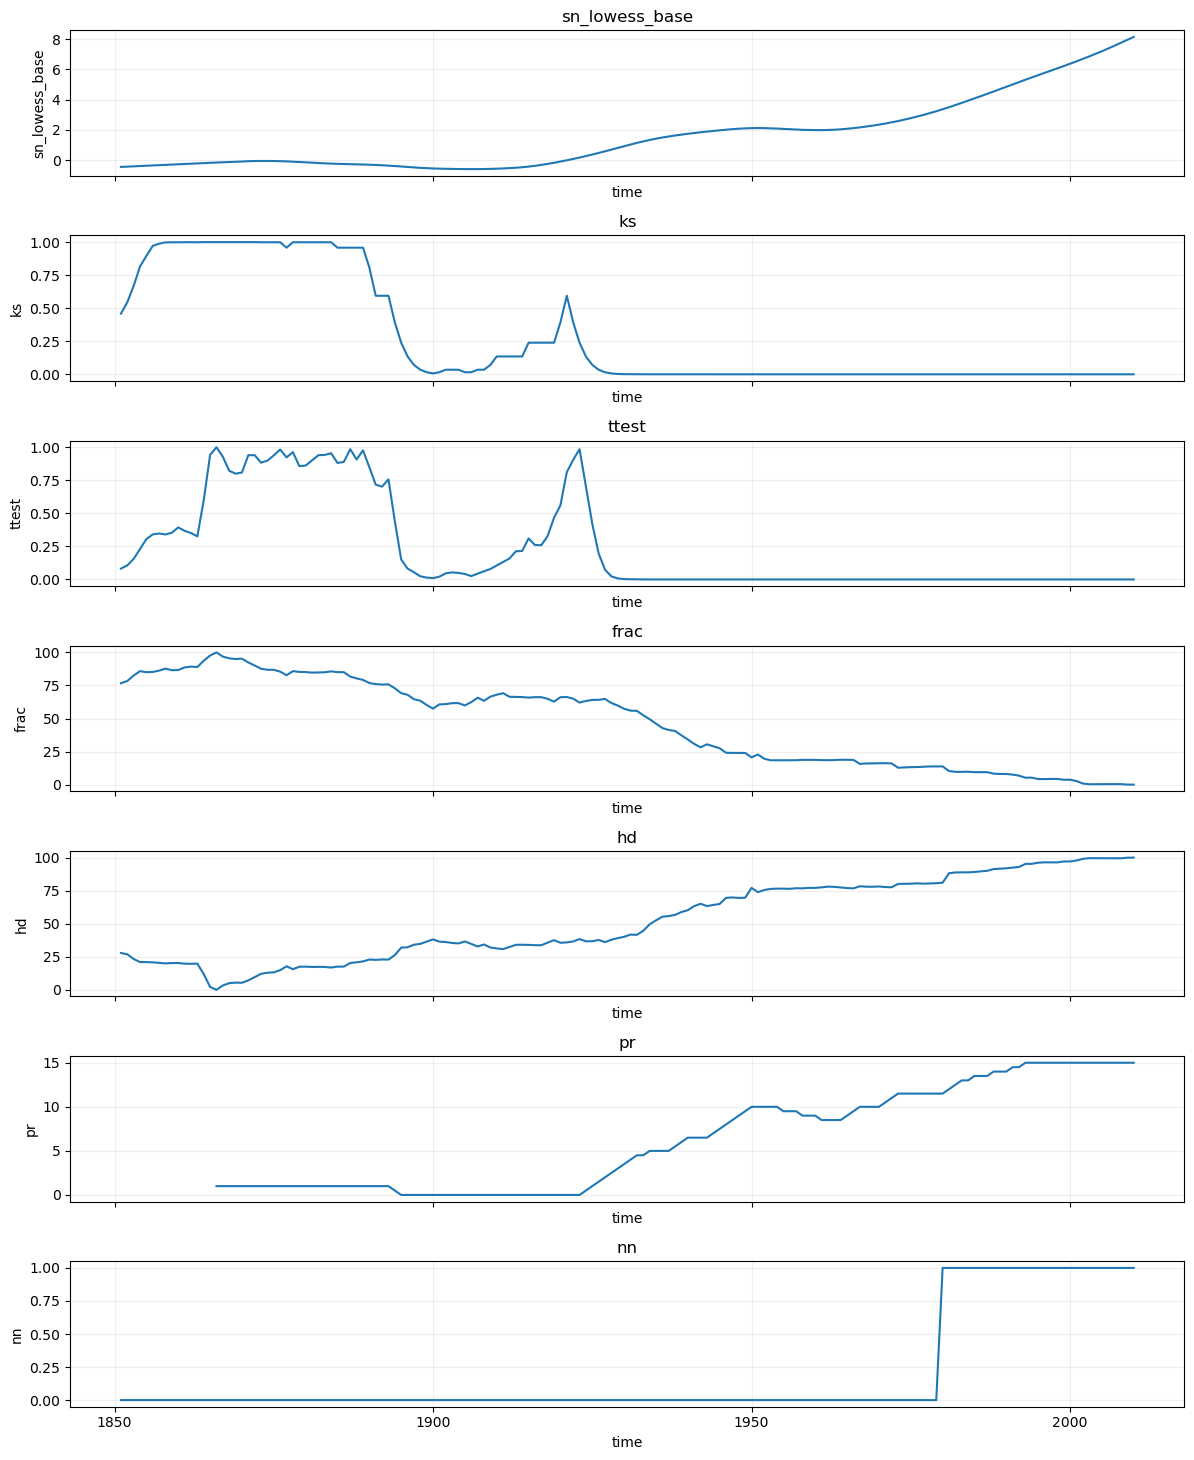

In [75]:
preview_vars = [v for v in ['sn_lowess_base', 'ks', 'ttest', 'frac', 'hd', 'pr', 'nn'] if v in toe_metrics_ds.data_vars]
fig, axes = plt.subplots(len(preview_vars), 1, figsize=(12, 2.1 * len(preview_vars)), sharex=True)
if len(preview_vars) == 1:
    axes = [axes]
for ax, name in zip(axes, preview_vars):
    toe_metrics_ds[name].plot(ax=ax)
    ax.set_title(name)
    ax.grid(alpha=0.2)
plt.tight_layout()


### ToE Rule Set

Permanent exceedance is computed per metric with method-specific thresholds:

- S/N metrics: `|S/N| >= 1`
- KS / t-test: `p < PVALUE_THESHOLD1`
- Fraction overlap: `<= OVERLAP_THRESHOLD`
- Hellinger distance: `>= OVERLAP_THRESHOLD`
- Probability ratio: `PR >= 2`
- New normal: boolean permanent exceedance

Final ToE years are clipped to the available data range.


In [76]:
# toe_metrics_ds = toe_metrics_ds.chunk({'time':-1, 'member':10}).persist()
# wait(toe_metrics_ds);

In [77]:
import toe_calc as toe

In [78]:
toe_metrics_ds

<xarray.Dataset> Size: 15kB
Dimensions:         (time: 160)
Coordinates:
  * time            (time) object 1kB 1850-12-31 00:00:00 ... 2009-12-31 00:0...
    quantile        float64 8B 0.95
Data variables:
    ks              (time) float64 1kB 0.4586 0.5445 ... 1.691e-17 1.691e-17
    ttest           (time) float64 1kB 0.08229 0.1064 ... 3.053e-29 2.507e-29
    sn_mean_base    (time) float64 1kB nan nan nan nan ... 6.927 7.085 7.16
    sn_poly_base    (time) float64 1kB 0.06331 0.02838 -0.004632 ... 7.192 7.378
    sn_lowess_base  (time) float64 1kB -0.4376 -0.418 -0.3981 ... 7.945 8.137
    sn_lowess_full  (time) float64 1kB -0.4927 -0.4706 -0.4482 ... 8.944 9.161
    sn_anom_base    (time) float64 1kB -0.7351 -0.1877 0.2106 ... 6.76 7.872
    frac            (time) float64 1kB 76.72 78.36 82.55 ... 0.04367 0.005561
    hd              (time) float64 1kB 27.82 26.85 23.27 ... 99.47 99.91 99.98
    nn              (time) int64 1kB 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1 1
    pr              (time) float64 1kB nan nan nan nan ... 15.0 15.0 15.0 15.0

In [79]:
OVERLAP_THRESHOLD

62

In [80]:
hd_ds = hd_ds/100

In [81]:
HD_THESHOLD = np.sqrt(1-OVERLAP_THRESHOLD/100)
HD_THESHOLD

0.6164414002968976

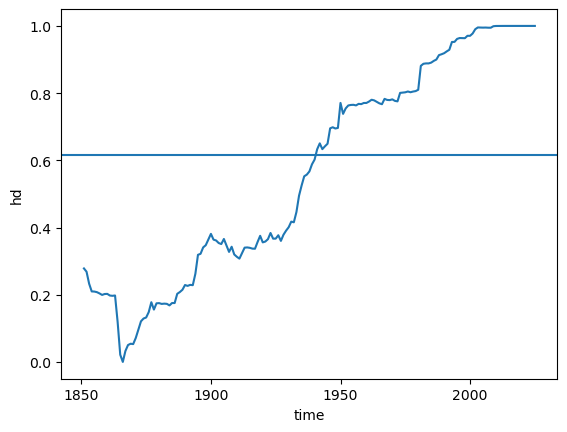

In [82]:
fig, ax = plt.subplots()
hd_ds.plot(ax=ax)
ax.axhline(HD_THESHOLD)

In [83]:
sn_vars = [var for var in toe_metrics_ds.data_vars if var.startswith('sn_')]
sn_toe_ds = toe.get_permanent_exceedance(
    np.abs(toe_metrics_ds[sn_vars]),
    threshold=1,
    greater=True,
).compute()
nn_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['nn'], threshold=0.5, greater=True)
ks_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['ks'], threshold=PVALUE_THESHOLD1, greater=False)
ttest_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['ttest'], threshold=PVALUE_THESHOLD1, greater=False)
frac_geom_toe_ds = toe.get_permanent_exceedance(frac_geom_ds, threshold=OVERLAP_THRESHOLD, greater=False)
hd_toe_ds = toe.get_permanent_exceedance(hd_ds, threshold=HD_THESHOLD, greater=True)
pr_toe_ds = toe.get_permanent_exceedance(pr_ds, threshold=2.0, greater=True)

In [84]:
# merge TOE estimates

toe_ds = xr.merge([
    sn_toe_ds,
    ks_toe_ds,
    ttest_toe_ds,
    frac_geom_toe_ds,
    hd_toe_ds,
    nn_toe_ds,
    pr_toe_ds,
])

max_year = int(smean_anom_ds.time.dt.year.max())
toe_ds = xr.where(toe_ds <= max_year, toe_ds, np.nan).compute()
wait(toe_ds);

# toe_ds.to_pandas()


In [85]:
toe_df = toe_ds.to_pandas()
toe_df.head(10)

sn_mean_base      1932.0
sn_poly_base      1941.0
sn_lowess_base    1930.0
sn_lowess_full    1929.0
sn_anom_base      1965.0
ks                1927.0
ttest             1928.0
frac              1927.0
hd                1940.0
nn                1979.0
dtype: float64

(1890.0, 2010.0)

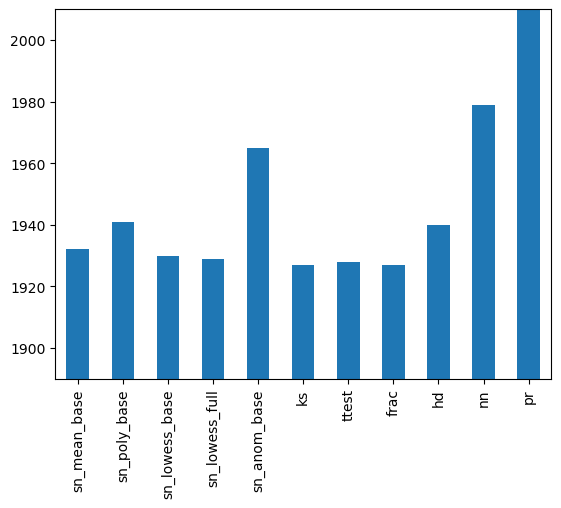

In [86]:
toe_ds.isel(member_kwargs).to_pandas().plot.bar()
plt.ylim(1890, 2010)

In [87]:
# sn_vars = [var for var in toe_metrics_ds.data_vars if var.startswith('sn_')]

# sn_toe_ds = toe.get_permanent_exceedance(
#     np.abs(toe_metrics_ds[sn_vars]),
#     threshold=1,
#     comparison_func=np.greater_equal,
# ).compute()

# nn_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['nn'], threshold=0.5, comparison_func=np.greater)
# ks_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['ks'], threshold=PVALUE_THESHOLD1, comparison_func=np.less)
# ttest_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['ttest'], threshold=PVALUE_THESHOLD1, comparison_func=np.less)
# frac_geom_toe_ds = toe.get_permanent_exceedance(frac_geom_ds, threshold=OVERLAP_THRESHOLD, comparison_func=np.less_equal)
# hd_toe_ds = toe.get_permanent_exceedance(hd_ds, threshold=OVERLAP_THRESHOLD, comparison_func=np.greater_equal)
# pr_toe_ds = toe.get_permanent_exceedance(toe_metrics_ds['pr'], threshold=2.0, comparison_func=np.greater_equal)


## 8) Core ToE Panel (`toe_plots`)


In [88]:

from __future__ import annotations

from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from scipy.stats import ks_2samp
from statsmodels.distributions.empirical_distribution import ECDF

In [89]:
# toe_series = toe_ds.to_pandas().dropna().sort_values()

# fig, ax = plt.subplots(figsize=(12, 4))
# toe_series.plot(kind='bar', ax=ax, color='steelblue')
# ax.set_ylabel('Year')
# ax.set_title('Time of Emergence by Method')
# ax.grid(axis='y', alpha=0.25)
# plt.xticks(rotation=45, ha='right')
# plt.tight_layout()


## Functions

In [90]:
# ---------------------------------------------------------------------------
# Nature Reviews Earth & Environment – publication style
# ---------------------------------------------------------------------------

def apply_nature_rcparams() -> None:
    """Set matplotlib rcParams for Nature Reviews Earth & Environment style."""
    plt.rcParams.update({
        "font.family":           "sans-serif",
        "font.sans-serif":       ["Arial", "Helvetica Neue", "Helvetica",
                                   "Liberation Sans", "DejaVu Sans"],
        "font.size":             7,
        "mathtext.fontset":      "dejavusans",

        "axes.spines.top":       False,
        "axes.spines.right":     False,
        "axes.linewidth":        0.75,
        "axes.labelsize":        8,
        "axes.titlesize":        8,
        "axes.titleweight":      "bold",
        "axes.labelpad":         3,

        "xtick.labelsize":       7,
        "ytick.labelsize":       7,
        "xtick.major.width":     0.75,
        "ytick.major.width":     0.75,
        "xtick.minor.width":     0.5,
        "ytick.minor.width":     0.5,
        "xtick.major.size":      3.5,
        "ytick.major.size":      3.5,
        "xtick.minor.size":      2.0,
        "ytick.minor.size":      2.0,
        "xtick.direction":       "out",
        "ytick.direction":       "out",

        "legend.fontsize":       7,
        "legend.frameon":        True,
        "legend.framealpha":     0.9,
        "legend.edgecolor":      "none",
        "legend.borderpad":      0.4,
        "legend.labelspacing":   0.3,
        "legend.handlelength":   1.5,
        "legend.handletextpad":  0.4,
        "legend.fancybox":       False,

        "lines.linewidth":       1.2,
        "lines.markersize":      3.5,

        "grid.linewidth":        0.5,
        "grid.alpha":            0.35,
        "grid.linestyle":        "--",
        "grid.color":            "0.75",

        "figure.dpi":            150,
        "savefig.dpi":           300,
        "savefig.bbox":          "tight",
        "savefig.pad_inches":    0.05,

        "patch.linewidth":       0.75,
    })
apply_nature_rcparams()

In [91]:
import matplotlib.ticker as mticker

In [92]:
def convert_multi_to_name(arr):
    if len(arr) == 1:
        return toe_const.NAME_CONVERSION_DICT_SHORT.get(arr[0], arr[0])
    return '(' + ', '.join(toe_const.NAME_CONVERSION_DICT_SHORT.get(k, k) for k in arr) + ')'


In [93]:
"""
Plotting functions for the ToE method schematic figure (fig_02).

Style via S dict. No rcParams side effects.
Organisation: style → helpers → compute → plot → annotate.
"""

from __future__ import annotations
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from scipy.stats import ks_2samp
from statsmodels.distributions.empirical_distribution import ECDF


# ── Helpers ──────────────────────────────────────────────────────────────

def _shade_base(ax, base_period):
    c = S["base_color"]
    ax.axvspan(base_period[0], base_period[1], color=c, alpha=0.08, zorder=0)
    ax.axvline(base_period[0], color=c, lw=0.6, ls="--", alpha=0.4)
    ax.axvline(base_period[1], color=c, lw=0.6, ls="--", alpha=0.4)

def _grid(ax): ax.grid(True, ls="--", alpha=0.35)
def _ticks(ax): ax.tick_params(axis="both", labelsize=S["tick"], direction="out")

def _draw_kde(ax, x, kb, kf, *, labels=True):
    ax.plot(x, kb, color=S["base_color"], lw=S["lw"], alpha=0.5,
            label=r"$f_1(x)$: $Base Period" if labels else None)
    ax.plot(x, kf, color=S["future_color"], lw=S["lw"], alpha=0.5,
            label="$f_2(x)$: Future Climate" if labels else None)


# ── Compute ──────────────────────────────────────────────────────────────

def compute_probability_ratio(data_ens, base_period, *,
                              event_quantile=0.95, rolling_window=30):
    """Rolling event probability and probability ratio."""
    ens_dim = "member"
    has_ens = ens_dim in data_ens.dims and data_ens.sizes[ens_dim] > 1
    q_dims = ["time"] + ([ens_dim] if has_ens else [])

    base = data_ens.sel(time=slice(str(base_period[0]), str(base_period[1])))
    thresh = float(base.quantile(event_quantile, dim=q_dims).values.item())

    event = xr.where(data_ens > thresh, 1.0, 0.0)
    p0 = max(float(event.sel(time=slice(str(base_period[0]), str(base_period[1])))
                   .mean(dim=q_dims).values.item()), 1e-6)

    p1 = event.rolling(time=rolling_window, center=True).mean()
    if has_ens:
        p1 = p1.mean(dim=ens_dim)

    pr = p1 / p0
    return pr.time.dt.year.values, p1.values, pr.values, p0


# ── Plot functions ───────────────────────────────────────────────────────

def plot_gmst_and_toe(ax, smean_anom, toe_df, base_period, *,
                      smean_anom_ens=None, test_styles=None, name_map=None):
    """GMST anomaly time-series with ToE vertical markers."""
    test_styles = test_styles or {}
    name_map = name_map or {}
    time = smean_anom.time.dt.year.values
    arr = smean_anom.values

    if smean_anom_ens is not None:
        n = smean_anom_ens.sizes.get("member", 1)
        if "member" in smean_anom_ens.dims and n > 1:
            for i in range(n):
                ax.plot(time, smean_anom_ens.isel(member=i).values,
                        color=S["ensemble_color"], alpha=S["ensemble_alpha"],
                        lw=S["member_lw"])

    ax.plot(time, arr, lw=1.2, color="grey", alpha=0.8)
    _shade_base(ax, base_period)
    ax.annotate("Base Period", xy=(np.mean(base_period), 0.53),
                fontsize=S["text"], ha="center",
                color=S["base_color"], fontweight="bold")
    ax.axhline(0, color=S["base_color"], ls="--", lw=S["lw"] * 0.6,
               alpha=0.5, zorder=1)

    for metric, year in toe_df.items():
        color = toe_plots.TEST_STYLES.get(metric, {"color": "black"})["color"]
        label = toe_plots.METRIC_NAME_MAP_SHORT.get(metric, metric).replace("base", "").replace(",", "")
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.5, yval], label=label, alpha=1, color=color)
        ax.scatter([year], [yval], color=color, s=S["marker_s"],
                   zorder=100, edgecolors="white", linewidths=0.6)

    leg = ax.legend(fontsize=S["legend"], labelspacing=0.25,
                    handletextpad=0.4, loc="upper center", ncol=2)
    leg.set_title("Time of Emergence (ToE)",
                  prop={"size": S["legend"], "weight": "bold"})
    ax.set_ylabel("GMST Anomaly (°C)", fontsize=S["label"])
    ax.set_ylim(-0.35, 1.5)
    _grid(ax)
    _ticks(ax)


def plot_sn_ratio(ax, toe_metrics_ds, *, line_styles=None, overlap_var=None):
    """S/N ratio curves with optional overlap twin axis."""
    line_styles = line_styles or {}
    sn_vars = [k for k in line_styles
               if k.startswith("sn_") and k in toe_metrics_ds.data_vars]

    for i, name in enumerate(sn_vars):
        color = dict(line_styles.get(name, {})).pop("color", "black")
        alpha = 0.4 if "anom" in name else 0.9
        zorder = 1 if "anom" in name else 5 + i
        ax.plot(toe_metrics_ds.time.dt.year.values,
                toe_metrics_ds[name].values,
                color=color, ls="solid", alpha=alpha, zorder=zorder,
                label=SIGNAL_NAME_MAP.get(name, name), lw=S["lw"])

    # Threshold lines
    tkw = dict(ls="--", color=S["future_color"], lw=S["lw"] * 0.55,
               alpha=0.65, zorder=0)
    for yval, label in [(1, "Unusual"), (2, "Unfamiliar"),
                        (3, "Unknown"), (5, "Inconceivable")]:
        ax.axhline(yval, **tkw)
        ax.annotate(label, xy=(1.0, yval), xycoords=("axes fraction", "data"),
                    xytext=(-4, 2), textcoords="offset points",
                    ha="right", va="bottom", size=S["text"] - 0.5,
                    color=S["future_color"], annotation_clip=False)

    ax.set_ylabel("S/N Ratio", fontsize=S["label"])
    ax.set_xlabel("Year", fontsize=S["label"])
    ax.set_title("Signal-to-noise (S/N) Ratio", fontsize=S["title"])
    ax.legend(fontsize=S["legend"], loc="upper left", ncol=1)
    _grid(ax)
    _ticks(ax)

    # Overlap twin axis
    ax_right = None
    if overlap_var and overlap_var in toe_metrics_ds.data_vars:
        ov = toe_metrics_ds[overlap_var]
        ax_right = ax.twinx()
        yrs, vals = ov.time.dt.year.values, ov.values
        ax_right.fill_between(yrs, vals, 100, color=S["overlap_color"],
                              alpha=S["overlap_alpha"], zorder=0)
        ax_right.plot(yrs, vals, color=S["overlap_color"], lw=S["lw"],
                      label="Area of\nOverlap", zorder=1)
        ax_right.set_ylim(100, 0)
        ax_right.set_ylabel("Overlap  %", fontsize=S["label"],
                             color=S["overlap_color"])
        ax_right.tick_params(axis="y", labelcolor=S["overlap_color"],
                              labelsize=S["tick"])
        ax_right.spines["right"].set_visible(True)
        ax_right.spines["right"].set_color(S["overlap_color"])
        ax_right.spines["right"].set_linewidth(0.75)
        ax_right.spines["top"].set_visible(False)

        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax_right.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=S["legend"], loc="upper left")

    return ax, ax_right




def plot_lower_panels(ax_tt, ax_ov, ax_hd, smean_anom, emergence_year, fga_fn,
                      *, base_window=50, half_window=15):
    """Orchestrate T-test, Overlap, Hellinger panels."""
    start_year = int(smean_anom.time.dt.year.values[0])
    base_arr = smean_anom.isel(time=slice(0, base_window)).values
    idx = emergence_year - start_year - half_window
    future_arr = smean_anom.isel(time=slice(idx, idx + 30)).values

    x, kf, kb, ov = fga_fn(base_arr, future_arr, return_all=True,
                            method_kwargs=dict(bw_method=0.2),
                            bmin=-0.6, bmax=0.6)
    plot_ttest_panel(ax_tt, x, kb, kf, base_arr, future_arr)
    plot_overlap_panel(ax_ov, x, kb, kf, ov)
    plot_hellinger_panel(ax_hd, x, kb, kf)




def plot_event_probability(ax, years, p1, p0):
    """Rolling event-probability curve."""
    ax.plot(years, p1, color=S["base_color"], lw=S["lw"],
            label=r"Rolling event probability $p_1(t)$")
    ax.axhline(p0, color=S["future_color"], ls="--", lw=S["lw"],
               label=f"Base probability $p_0$ = {p0:.3f}")
    ax.set(ylabel="Probability", title="Event Probability: Base vs Rolling")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(fontsize=S["legend"])
    _grid(ax)
    _ticks(ax)


def plot_probability_ratio(ax, years, pr):
    """Probability Ratio time-series."""
    c = S["future_color"]
    ax.plot(years, pr, color=S["last_color"], lw=S["lw"],
            label=r"PR = $p_1(t)/p_0$")
    ax.axhline(1, color=c, ls="--", lw=S["lw"] * 0.8)
    ax.axhline(2, color=c, ls=":", lw=S["lw"] * 0.7)
    ax.annotate("No change (PR=1)", xy=(years[5], 1.02), color=c, fontsize=S["text"])
    ax.annotate("PR=2", xy=(years[5], 2.05), color=c, fontsize=S["text"])
    ax.set(ylabel="Probability Ratio", xlabel="Year",
           title="Probability Ratio Demonstration")
    ax.yaxis.label.set_size(S["label"])
    ax.xaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(fontsize=S["legend"])
    _grid(ax)
    _ticks(ax)


# ── Annotation ───────────────────────────────────────────────────────────

def annotate_panels(axes, *, xy=(0.01, 1.03), xy_overrides=None):
    """Bold a), b), … panel labels."""
    xy_overrides = xy_overrides or {}
    for i, ax in enumerate(axes):
        pos = xy_overrides.get(i, xy)
        ax.annotate(f"{chr(97 + i)})", xy=pos, xycoords="axes fraction",
                    fontsize=S["panel"], fontweight="bold")

In [94]:
def plot_ks_test(ax, smean_anom, base_period, emergence_year, *, window=10):
    """KS-test CDFs and max-statistic marker with colored annotation and legend."""
    base = smean_anom.sel(time=slice(str(base_period[0]), str(base_period[1]))).values
    emrg = smean_anom.sel(time=slice(str(emergence_year - window),
                                     str(emergence_year + window))).values
    ecdf_b, ecdf_e = ECDF(base), ECDF(emrg)
    ks = ks_2samp(base, emrg)

    ax.plot(ecdf_b.x, ecdf_b.y, color=S["base_color"], lw=S["lw"],
            alpha=0.5, label="Base Period\n"+r"($F_1(x)$)")
    ax.plot(ecdf_e.x, ecdf_e.y, color=S["future_color"], lw=S["lw"],
            alpha=0.5, label="Future Climate\n"+r"($F_2(x)$)")

    mx = ks.statistic_location
    ax.plot([mx, mx], [ecdf_b(mx), ecdf_e(mx) + 0.05],
            color=S["median_color"], ls="--", lw=S["lw"])

    labely = ecdf_e(mx)
    ax.annotate(
        r"$D = \sup_x \left| F_1(x) - F_2(x) \right|$",
        xy=(mx+0.05, labely-0.05),
        bbox=dict(edgecolor="black", facecolor='white'),
        ha='left', va='top', fontsize=S["text"],
    )

    ax.set_ylabel("Cumulative Density", fontsize=S["label"])
    ax.set_xlabel("GMST Anomaly (°C)", fontsize=S["label"])
    ax.set_ylim(0, 1.02)
    ax.set_title("Kolmogorov-Smirnov Test", fontsize=S["title"])
    ax.legend(fontsize=S["legend"], loc='upper left')
    _ticks(ax)

def plot_ttest_panel(ax, x, kb, kf, base_arr, future_arr,
                     *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """T-test: KDE curves with mean markers."""
    from scipy.stats import ttest_ind

    _draw_kde(ax, x, kb, kf, labels=True)

    mb, mf = float(np.mean(base_arr)), float(np.mean(future_arr))
    sb, sf = float(np.std(base_arr)), float(np.std(future_arr))

    # KDE heights at mean
    yb = kb[np.argmin(np.abs(x - mb))]
    yf = kf[np.argmin(np.abs(x - mf))]

    # Mean lines (solid, vertical)
    ax.plot([mb, mb], [0, yb], color=S["base_color"],   lw=S["lw"])
    ax.plot([mf, mf], [0, yf], color=S["future_color"], lw=S["lw"])

    # mu labels at top of mean lines
    ax.annotate(r"$\mu_1$", xy=(mb, yb + 0.1), ha="center",
                color=S["base_color"], fontsize=S["text"])
    ax.annotate(r"$\mu_2$", xy=(mf, yf + 0.1), ha="center",
                color=S["future_color"], fontsize=S["text"])

    # sigma boundary lines (dashed, from x-axis to KDE at mu ± sigma)
    for x_pos, kde, color in [(mb - sb, kb, S["base_color"]),
                               (mb + sb, kb, S["base_color"]),
                               (mf - sf, kf, S["future_color"]),
                               (mf + sf, kf, S["future_color"])]:
        y_top = kde[np.argmin(np.abs(x - x_pos))]
        ax.plot([x_pos, x_pos], [0, y_top], color=color, lw=S["lw"], ls="--", alpha=0.7)

    # sigma labels at right-hand dashed line only
    yb_sig = kb[np.argmin(np.abs(x - (mb + sb)))]
    yf_sig = kf[np.argmin(np.abs(x - (mf + sf)))]
    ax.annotate(r"$\sigma_1$", xy=(mb + sb, yb_sig + 0.1),
                ha="left", color=S["base_color"],   fontsize=S["text"])
    ax.annotate(r"$\sigma_2$", xy=(mf + sf, yf_sig + 0.1),
                ha="left", color=S["future_color"], fontsize=S["text"])

    # Equation box
    t, p = ttest_ind(base_arr, future_arr)
    ax.annotate(
        r"$t = \frac{\mu_1 - \mu_2}{\sqrt{\sigma_1^2/n_1 + \sigma_2^2/n_2}}$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["label"],
    )

    ax.set(xlim=xlim, ylim=ylim, ylabel="Probability", title="T-Test")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    _ticks(ax)
    
def plot_overlap_panel(ax, x, kb, kf, fga_overlap,
                       *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """Area of Overlap panel."""
    _draw_kde(ax, x, kb, kf, labels=False)
    ax.fill_between(x, 0, np.minimum(kb, kf), color="gray", alpha=0.5,
                    label="Distribution\nOverlap")
    ax.annotate(
        r"$AO = \int \min\left(f_1(x),\ f_2(x)\right)\,dx$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim, xlabel="GMST Anomaly (°C)", title="Area of Overlap")
    ax.xaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(loc="upper left", fontsize=S["legend"], ncol=2)
    _ticks(ax)


def plot_hellinger_panel(ax, x, kb, kf,
                         *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """Hellinger Distance panel."""
    _draw_kde(ax, x, kb, kf, labels=False)
    sq = (np.sqrt(kb) - np.sqrt(kf)) ** 2
    hd = np.sqrt(np.sum(sq) * (x[1] - x[0])) / np.sqrt(2)
    ax.fill_between(x, 0, sq, color="gray", alpha=0.5, label="Squared\nDifferences")
    ax.plot(x, sq, color="gray", lw=S["lw"])
    ax.annotate(
        r"$H = \frac{1}{\sqrt{2}}\sqrt{\int\left(\sqrt{f_1} - \sqrt{f_2}\right)^2 dx}$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["label"],                              # one step up to compensate for fraction shrink
    )
    ax.set(xlim=xlim, ylim=ylim, title="Hellinger Distance")
    ax.title.set_size(S["title"])
    ax.legend(loc="upper left", fontsize=S["legend"], ncol=2)
    _ticks(ax)


def add_lower_panels_legend(fig, ax_tt):
    """Shared Base Period / Future Climate legend below lower row."""
    h, labels = ax_tt.get_legend_handles_labels()
    l = ("Base Period\n"+r"($f_1(x)$)", "Future Climate\n"+r"($f_2(x)$)")
    ax_tt.legend(h, l, loc="lower center", ncol=1, fontsize=S["legend"]*0.9,
               bbox_to_anchor=(-0.1, -0.8), frameon=True)


In [95]:
STYLE = {
    "base_color":   "steelblue",
    "future_color": "firebrick",
    "ensemble_color":  "#a8c8e8",
    "ensemble_alpha":  0.7,
    "median_color":    "#1a1a1a",
    "plume_outer":     "#c6dbef",
    "plume_inner":     "#6baed6",
    "member_line":     "#5b9bd5",
    "emerged_color":   "#999999",
    "overlap_color":   "#8bc34a",
    "overlap_alpha":   0.20,
    # Typography (pt)
    "title": 8, "label": 8, "text": 7, "legend": 8, "tick": 7, "panel": 9,
    # Lines
    "lw": 1.4, "member_lw": 0.5, "marker_s": 18,
    # Annotation box position (axes fraction) for ttest/overlap/hellinger
    "ann_xy": (0.5, -0.35),
}

S = STYLE

SIGNAL_NAME_MAP = {
    "sn_mean_base":   "Moving Average",
    "sn_poly_base":   "4th Order Polynomial",
    "sn_lowess_base": "LOWESS",
    "sn_anom_base":   "Anomalies",
}


In [96]:
main_metrics = ['sn_mean_base', 'sn_poly_base', 'sn_lowess_base', 'sn_anom_base', 'nn', 'ks', 'ttest', 'frac', 'hd']
SINGAL_NAME_MAP = {
    'sn_mean_base': 'Moving Average',
    'sn_poly_base': '4th Order Polynomial',
    'sn_lowess_base': 'LOWESS',
    'sn_anom_base': 'Anomalies',
}

(-1.0, 10.0)

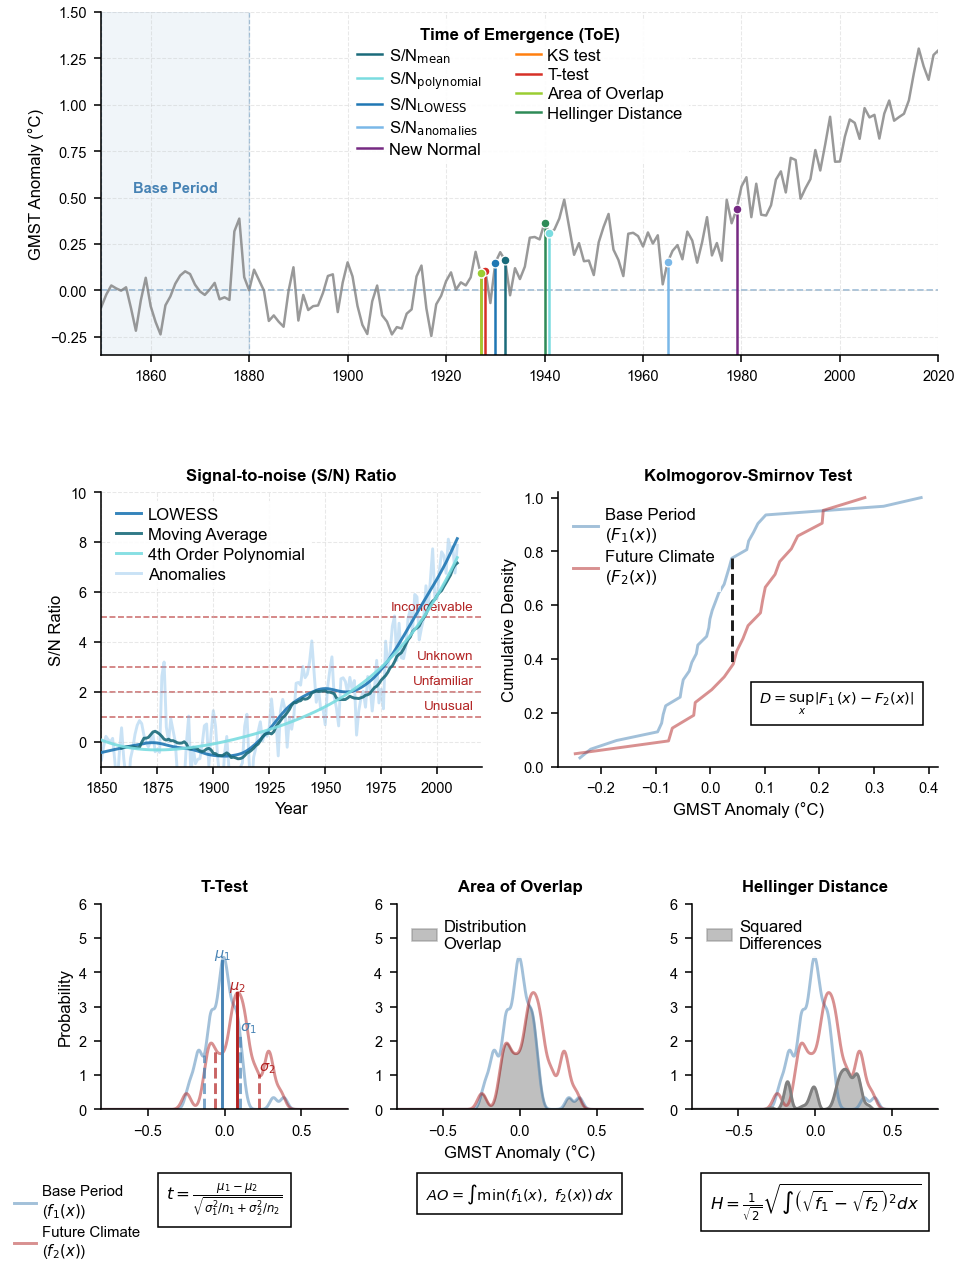

In [97]:
# ═══════════════════════════════════════════════════════════════════════════
# fig_02 — ToE method schematic (restyled to match ensemble emergence fig)
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Build figure / axes ────────────────────────────────────────────────
fig = plt.figure(figsize=(7.2, 9.5))
gs  = gridspec.GridSpec(3, 2, height_ratios=[1, 0.8, 0.6], hspace=0.50, wspace=0.2)
ax_gmst = fig.add_subplot(gs[0, :])
ax_sn   = fig.add_subplot(gs[1, 0])
ax_ks   = fig.add_subplot(gs[1, 1])
subgrid = gs[2, :].subgridspec(1, 3, wspace=0.2)
ax_tt, ax_ov, ax_hd = [fig.add_subplot(subgrid[i]) for i in range(3)]

# ── 3. Draw panels ───────────────────────────────────────────────────────
plot_gmst_and_toe(
    ax_gmst, smean_anom_ds,#.median(dim='member'), 
    toe_df.loc[main_metrics], #toe_labels,
    base_period_tuple,
    # smean_anom_ens=smean_anom_ds, ensemble_dim='member',
)
plot_sn_ratio(
    ax_sn, toe_metrics_ds[main_metrics].isel(member_kwargs),
    line_styles=toe_plots.TEST_STYLES,
    # name_map=toe_plots.METRIC_NAME_MAP_SHORT,
    overlap_var='fga',
)
plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=int(toe_ds['ks'].isel(member_kwargs).values.item()),
)
plot_lower_panels(
    ax_tt, ax_ov, ax_hd,
    smean_anom_ds,
    emergence_year=int(toe_ds['frac'].isel(member_kwargs).values.item()),
    fga_fn=toe.fractional_geometric_area,
)
add_lower_panels_legend(fig, ax_tt)

# ── 4. Bold panel labels ─────────────────────────────────────────────────
all_axes = [ax_gmst, ax_sn, ax_ks, ax_tt, ax_ov, ax_hd]
# annotate_panel_letters(all_axes, xy_overrides={3: (-0.12, 1.03)})

for ax in [ax_gmst, ax_sn]:
    ax.set_xlim(1850, 2020)
ax_sn.set_ylim(-1, 10)

# Major Update #3

In [122]:

from __future__ import annotations
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from scipy.stats import ks_2samp
from statsmodels.distributions.empirical_distribution import ECDF

In [123]:
# ---------------------------------------------------------------------------
# Nature Reviews Earth & Environment – publication style
# ---------------------------------------------------------------------------

def apply_nature_rcparams() -> None:
    """Set matplotlib rcParams for Nature Reviews Earth & Environment style."""
    plt.rcParams.update({
        "font.family":           "sans-serif",
        "font.sans-serif":       ["Arial", "Helvetica Neue", "Helvetica",
                                   "Liberation Sans", "DejaVu Sans"],
        "font.size":             7,
        "mathtext.fontset":      "dejavusans",

        "axes.spines.top":       False,
        "axes.spines.right":     False,
        "axes.linewidth":        0.75,
        "axes.labelsize":        8,
        "axes.titlesize":        8,
        "axes.titleweight":      "bold",
        "axes.labelpad":         3,

        "xtick.labelsize":       7,
        "ytick.labelsize":       7,
        "xtick.major.width":     0.75,
        "ytick.major.width":     0.75,
        "xtick.minor.width":     0.5,
        "ytick.minor.width":     0.5,
        "xtick.major.size":      3.5,
        "ytick.major.size":      3.5,
        "xtick.minor.size":      2.0,
        "ytick.minor.size":      2.0,
        "xtick.direction":       "out",
        "ytick.direction":       "out",

        "legend.fontsize":       7,
        "legend.frameon":        True,
        "legend.framealpha":     0.9,
        "legend.edgecolor":      "none",
        "legend.borderpad":      0.4,
        "legend.labelspacing":   0.3,
        "legend.handlelength":   1.5,
        "legend.handletextpad":  0.4,
        "legend.fancybox":       False,

        "lines.linewidth":       1.2,
        "lines.markersize":      3.5,

        "grid.linewidth":        0.5,
        "grid.alpha":            0.35,
        "grid.linestyle":        "--",
        "grid.color":            "0.75",

        "figure.dpi":            150,
        "savefig.dpi":           300,
        "savefig.bbox":          "tight",
        "savefig.pad_inches":    0.05,

        "patch.linewidth":       0.75,
    })
apply_nature_rcparams()

import matplotlib.ticker as mticker

In [124]:
"""
Plotting functions for the ToE method schematic figure (fig_02).

Layout (v5):
  Row 1  – full-width GMST anomaly + signal overlays + ToE markers
  Row 2  – full-width S/N ratio (matched x-axis to Row 1)
  Row 3  – KS test | T-test                           (test-statistic pair)
  Row 4  – AO + HD combined | PR tail illustration    (distributional pair)
  Row 5  – full-width PR + New Normal threshold time-series

Style via S dict.  No rcParams side effects.
Organisation: style → helpers → compute → plot → annotate → assembly.
"""

# ══════════════════════════════════════════════════════════════════════════
# Helpers
# ══════════════════════════════════════════════════════════════════════════

def _shade_base(ax, base_period):
    c = S["base_color"]
    ax.axvspan(base_period[0], base_period[1], color=c, alpha=0.08, zorder=0)
    ax.axvline(base_period[0], color=c, lw=0.6, ls="--", alpha=0.4)
    ax.axvline(base_period[1], color=c, lw=0.6, ls="--", alpha=0.4)


def _shade_comparison(ax, center_year, half_window=15):
    c = S["comp_color"]
    ax.axvspan(center_year - half_window, center_year + half_window,
               color=c, alpha=0.06, zorder=0)
    ax.axvline(center_year - half_window, color=c, lw=0.5, ls=":", alpha=0.5)
    ax.axvline(center_year + half_window, color=c, lw=0.5, ls=":", alpha=0.5)


def _grid(ax):
    ax.grid(True, ls="--", alpha=0.5)


def _ticks(ax):
    ax.tick_params(axis="both", labelsize=S["tick"], direction="out")
    # Major ticks every 20 years
    ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
    
    # Minor ticks every 5 years
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))


def _draw_kde(ax, x, kb, kf, *, labels=True):
    ax.plot(x, kb, color=S["base_color"], lw=S["lw"], alpha=0.5,
            label=r"$f_1(x): $Base Period" if labels else None)
    ax.plot(x, kf, color=S["future_color"], lw=S["lw"], alpha=0.5,
            label=r"$f_2(x)$: Future Climate" if labels else None)

In [125]:
# ══════════════════════════════════════════════════════════════════════════
# Compute
# ══════════════════════════════════════════════════════════════════════════

def compute_probability_ratio(data_ens, base_period, *,
                              event_quantile=0.95, rolling_window=30):
    """Rolling event probability and probability ratio."""
    ens_dim = "member"
    has_ens = ens_dim in data_ens.dims and data_ens.sizes[ens_dim] > 1
    q_dims = ["time"] + ([ens_dim] if has_ens else [])

    base = data_ens.sel(time=slice(str(base_period[0]), str(base_period[1])))
    thresh = float(base.quantile(event_quantile, dim=q_dims).values.item())

    event = xr.where(data_ens > thresh, 1.0, 0.0)
    p0 = max(float(event.sel(time=slice(str(base_period[0]), str(base_period[1])))
                   .mean(dim=q_dims).values.item()), 1e-6)

    p1 = event.rolling(time=rolling_window, center=True).mean()
    if has_ens:
        p1 = p1.mean(dim=ens_dim)

    pr = p1 / p0
    return pr.time.dt.year.values, p1.values, pr.values, p0


In [126]:
# ══════════════════════════════════════════════════════════════════════════
# Row 1 — GMST + signals + ToE
# ══════════════════════════════════════════════════════════════════════════

def plot_gmst_and_toe(ax, smean_anom, toe_df, base_period, *,
                      smean_anom_ens=None, signal_ds=None,
                      signal_styles=None, comparison_year=None,
                      half_window=15):
    """GMST anomaly time-series with signal overlays and ToE markers."""
    time = smean_anom.time.dt.year.values
    arr = smean_anom.values

    if smean_anom_ens is not None:
        n = smean_anom_ens.sizes.get("member", 1)
        if "member" in smean_anom_ens.dims and n > 1:
            for i in range(n):
                ax.plot(time, smean_anom_ens.isel(member=i).values,
                        color=S["ensemble_color"], alpha=S["ensemble_alpha"],
                        lw=S["member_lw"])

    ax.plot(time, arr, lw=1.2, color="grey", alpha=0.8)

    # Signal overlays
    if signal_ds is not None:
        signal_styles = signal_styles or SIGNAL_OVERLAY_STYLES
        sig_time = signal_ds.time.dt.year.values
        for var, sty in signal_styles.items():
            if var in signal_ds.data_vars:
                ax.plot(sig_time, signal_ds[var].values,
                        color=sty.get("color", "black"),
                        lw=sty.get("lw", S["lw"]),
                        alpha=sty.get("alpha", 0.7),
                        zorder=sty.get("zorder", 3),
                        label=sty.get("label", var))

    _shade_base(ax, base_period)
    ax.annotate("Base Period", xy=(np.mean(base_period), 0.6),
                fontsize=S["text"], ha="center", va='top',
                color=S["base_color"], fontweight="bold")

    if comparison_year is not None:
        _shade_comparison(ax, comparison_year, half_window)
        ax.annotate("Comparison\nWindow",
                    xy=(comparison_year, 0.65),
                    fontsize=S["text"], ha="center", va='top',
                    color=S["comp_color"], fontweight="bold")

    ax.axhline(0, color=S["base_color"], ls="--", lw=S["lw"] * 0.6,
               alpha=0.5, zorder=1)
    METRIC_STYLES = {
        **dict.fromkeys(['ks', 'ttest'], ('x', (0, (1, 1)))),
        **dict.fromkeys(['frac', 'hd', 'pr', 'nn'],    ('>', 'dashed')),}

    for metric, year in toe_df.items():
        color = toe_plots.TEST_STYLES.get(metric, {"color": "black"})["color"]
        label = (toe_plots.METRIC_NAME_MAP_SHORT.get(metric, metric)
            .replace("base", "").replace(",", ""))
        yval = arr[time == year][0]
        marker, linestyle = ('o', 'solid') if 'sn' in metric else METRIC_STYLES.get(metric, ('o', '-'))

        ax.plot([year, year], [-0.5, yval], label=label, alpha=1, linewidth=STYLE['lw'],
                color=color, marker=marker, linestyle=linestyle)
        ax.scatter([year], [yval], color=color, s=S["marker_s"], marker=marker,
                   zorder=100, edgecolors="white", linewidths=0.6)

    leg = ax.legend(loc="upper left", ncol=5, **{**LEGEND_KWARGS, "fontsize": LEGEND_KWARGS["fontsize"] * 1.2})
    leg.set_title("Time of Emergence (ToE)", prop=LEGEND_PROP)
    ax.set_title("Time of Emergence (ToE) of Global Mean Surface Temperature (GMST)", fontsize=S["title"])

    ax.set_ylabel("GMST Anomaly (°C)", fontsize=S["label"])
    ax.set_ylim(-0.35, 1.5)
    _grid(ax)
    _ticks(ax)


# ══════════════════════════════════════════════════════════════════════════
# Row 2 — S/N ratio
# ══════════════════════════════════════════════════════════════════════════

def plot_sn_ratio(ax, toe_metrics_ds, *, overlap_vars=None):
    """S/N ratio curves with threshold lines and optional overlap twin."""
    sn_vars = [k for k in list(toe_metrics_ds.data_vars)
               if k.startswith("sn_") and k in toe_metrics_ds.data_vars]

    for i, name in enumerate(sn_vars):
        color = toe_plots.TEST_STYLES.get(name, {"color": "black"})["color"]
        alpha = 0.6 if "anom" in name else 0.9
        zorder = 1 if "anom" in name else 5 + i
        ax.plot(toe_metrics_ds.time.dt.year.values,
                toe_metrics_ds[name].values,
                color=color, ls="solid", alpha=alpha, zorder=zorder,
                label=SIGNAL_NAME_MAP.get(name, name), lw=S["lw"])

    tkw = dict(ls="--", color=S["future_color"], lw=S["lw"] * 0.55,
               alpha=0.65, zorder=0)
    for yval, label in [(1, "Unusual"), (2, "Unfamiliar"),
                        (3, "Unknown"), (5, "Inconceivable")]:
        ax.axhline(yval, **tkw)
        ax.annotate(label, xy=(1.0, yval), xycoords=("axes fraction", "data"),
                    xytext=(-4, 2), textcoords="offset points",
                    ha="right", va="bottom", size=S["text"] - 0.5,
                    color=S["future_color"], annotation_clip=False)

    ax.set_ylabel("S/N Ratio", fontsize=S["label"])
    ax.set_xlabel("Year", fontsize=S["label"])
    ax.set_title("Signal-to-noise (S/N) Ratio", fontsize=S["title"])
    ax.set_ylim(-2, 10)
    leg = ax.legend( loc="upper left", ncol=2, **{**LEGEND_KWARGS, "fontsize": LEGEND_KWARGS["fontsize"] * 1.2})
    leg.set_title("Signal Estimation Method", prop=LEGEND_PROP)

    _grid(ax)
    _ticks(ax)

    ax_right = None
    if overlap_vars:
        if isinstance(overlap_vars, str): overlap_vars = [overlap_vars]
        for overlap_var in overlap_vars:
            ov = toe_metrics_ds[overlap_var]
            ax_right = ax.twinx()
            yrs, vals = ov.time.dt.year.values, ov.values

            color = toe_plots.TEST_STYLES.get(overlap_var, {"color": "black"})["color"]
            label = label = toe_plots.METRIC_NAME_MAP_SHORT.get(overlap_var, overlap_var)
            # ax_right.fill_between(yrs, vals, 100, color=S["overlap_color"],
            #                       alpha=S["overlap_alpha"], zorder=0)
            ax_right.plot(yrs, vals, lw=S["lw"], color=color, label=label, zorder=1)
        ax_right.set_ylim(100, 0)
        ax_right.set_ylabel("Overlap  %", fontsize=S["label"],
                            color=S["overlap_color"])
        ax_right.tick_params(axis="y", labelcolor=S["overlap_color"],
                             labelsize=S["tick"])
        ax_right.spines["right"].set_visible(True)
        ax_right.spines["right"].set_color(S["overlap_color"])
        ax_right.spines["right"].set_linewidth(0.75)
        ax_right.spines["top"].set_visible(False)

        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax_right.get_legend_handles_labels()
        leg = ax.legend(h1 + h2, l1 + l2, **LEGEND_KWARGS, loc="upper left", ncol=5)
        
        leg.set_title("Signal Estimation Method", prop=LEGEND_PROP)
  
        # ax.legend(h1 + h2, l1 + l2, fontsize=S["legend"], loc="upper left")

    return ax, ax_right


# ══════════════════════════════════════════════════════════════════════════
# Row 3 — Test-statistic pair: KS | T-test
# ══════════════════════════════════════════════════════════════════════════

def plot_ks_test(ax, smean_anom, base_period, emergence_year, window):
    """KS-test CDFs and max-statistic marker."""
    base = smean_anom.sel(
        time=slice(str(base_period[0]), str(base_period[1]))).values
    emrg = smean_anom.sel(
        time=slice(str(emergence_year - window//2),
                   str(emergence_year + window//2))).values
    ecdf_b, ecdf_e = ECDF(base), ECDF(emrg)
    ks = ks_2samp(base, emrg)

    ax.plot(ecdf_b.x, ecdf_b.y, color=S["base_color"], lw=S["lw"],
            alpha=0.5, label=r"$F_1(x)$: Base Period")
    ax.plot(ecdf_e.x, ecdf_e.y, color=S["future_color"], lw=S["lw"],
            alpha=0.5, label=r"$F_2(x)$: Future Period")

    mx = ks.statistic_location
    ax.plot([mx, mx], [ecdf_b(mx), ecdf_e(mx) + 0.05],
            color=S["median_color"], ls="--", lw=S["lw"], label='KS Statistic (D)')

    ax.annotate(
        r"$D = \sup_x |F_1 - F_2|$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white", boxstyle="round,pad=0.3"),
        fontsize=S["text"],
    )

    ax.set_ylabel("Cumulative Density", fontsize=S["label"])
    ax.set_ylim(0, 1.02)
    ax.set_xlim(-.25, 0.35)
    ax.set_title("Kolmogorov-Smirnov (KS) Test", fontsize=S["title"])
    
    ax.legend(loc="upper left", **LEGEND_KWARGS)
    # _ticks(ax)
    _grid(ax)


def plot_ttest_panel(ax, x, kb, kf, base_arr, future_arr,
                     *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """T-test: KDE curves with mean/std markers."""
    _draw_kde(ax, x, kb, kf, labels=True)

    mb, mf = float(np.mean(base_arr)), float(np.mean(future_arr))
    sb, sf = float(np.std(base_arr)), float(np.std(future_arr))

    yb = kb[np.argmin(np.abs(x - mb))]
    yf = kf[np.argmin(np.abs(x - mf))]

    ax.plot([mb, mb], [0, yb], color=S["base_color"],   lw=S["lw"]*0.7)
    ax.plot([mf, mf], [0, yf], color=S["future_color"], lw=S["lw"]*0.7)

    ax.annotate(r"$\mu_1$", xy=(mb, yb + 0.35), ha="center",
                color=S["base_color"], fontsize=S["text"], fontweight='bold')
    ax.annotate(r"$\mu_2$", xy=(mf, yf + 0.35), ha="center",
                color=S["future_color"], fontsize=S["text"], fontweight='bold')

    for x_pos, kde, color in [
        (mb - sb, kb, S["base_color"]),
        (mb + sb, kb, S["base_color"]),
        (mf - sf, kf, S["future_color"]),
        (mf + sf, kf, S["future_color"])
    ]:
        y_top = kde[np.argmin(np.abs(x - x_pos))]
        ax.plot([x_pos, x_pos], [0, y_top], color=color,
                lw=S["lw"]*0.7, ls="--", alpha=1)

    yb_sig = kb[np.argmin(np.abs(x - (mb + sb)))]
    yf_sig = kf[np.argmin(np.abs(x - (mf + sf)))]
    ax.annotate(r"$\sigma_1$", xy=(mb - sb, yb_sig),
                ha="center", color=S["base_color"], fontsize=S["text"], fontweight='bold')
    ax.annotate(r"$\sigma_2$", xy=(mf + sf, yf_sig + 0.1),
                ha="center", color=S["future_color"], fontsize=S["text"], fontweight='bold')

    ax.annotate(
        r"$t = \frac{\mu_1-\mu_2}{\sqrt{\sigma_1^2/n_1+\sigma_2^2/n_2}}$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white", boxstyle="round,pad=0.3"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim, ylabel="Probability", title="T-Test")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend( loc="upper left", **LEGEND_KWARGS)
    _grid(ax)
    # _ticks(ax)


# ══════════════════════════════════════════════════════════════════════════
# Row 4 — Combined AO + HD  |  PR tail
# ══════════════════════════════════════════════════════════════════════════
def plot_overlap_hellinger_panel(ax, x, kb, kf, fga_overlap,
                                 *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """Combined Area of Overlap + Hellinger Distance on one set of KDEs.
    Draws both distributions once, then overlays:
      - AO:  green filled region = min(f₁, f₂)
      - HD:  orange hatched region = (√f₁ − √f₂)²
    Two equation boxes sit side-by-side below the panel.
    """
    # ── KDE curves ──
    _draw_kde(ax, x, kb, kf, labels=True)

    # ── AO shading (green, solid fill) ──
    overlap = np.minimum(kb, kf)
    ax.fill_between(x, 0, overlap,
                    color=toe_plots.TEST_STYLES['frac']['color'], alpha=0.25,
                    label="Overlap (AO)", zorder=2)

    # ── HD squared differences (orange, hatched) ──
    sq = (np.sqrt(kb) - np.sqrt(kf)) ** 2
    ax.fill_between(x, 0, sq,
                    color=toe_plots.TEST_STYLES['hd']['color'], alpha=S["hd_alpha"],
                    hatch="////", edgecolor=toe_plots.TEST_STYLES['hd']['color'],
                    label="Square Differences\n(HD)", zorder=1)
    ax.plot(x, sq, color=toe_plots.TEST_STYLES['hd']['color'], lw=S["lw"] * 0.8, alpha=0.7, zorder=1)

    # ── Legend ──
    ax.legend(loc="upper left", fontsize=S["legend"], ncol=1, facecolor='none')

    # ── Equation boxes ──
    ax.annotate(
        r"$AO = \int \min(f_1, f_2)\,dx$",
        xy= (1, .6), xycoords="axes fraction",
        ha="right", va="top",
        bbox=dict(edgecolor="black", facecolor="white", boxstyle="round,pad=0.3"),
        fontsize=S["text"],
    )
    ax.annotate(
        r"$HD = \frac{1}{\sqrt{2}}\sqrt{\int(\sqrt{f_1}-\sqrt{f_2})^2\,dx}$",
        xy= (1, .9), xycoords="axes fraction",
        ha="right", va="top",
        bbox=dict(edgecolor="black", facecolor="white", boxstyle="round,pad=0.3"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim,
           ylabel="Probability\n" + r"$(\sqrt{f_1}-\sqrt{f_2})^2$",
           title="Area of Overlap (AO)\n&  Hellinger Distance (HD)")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    _grid(ax)
    return ax

def plot_pr_panel(ax, x, kb, kf, base_arr, future_arr,
                  *, xlim=(-0.8, 0.8), ylim=(0, 6),
                  event_quantile=0.95):
    """Probability Ratio — tail-area illustration."""
    _draw_kde(ax, x, kb, kf, labels=False)

    thresh = float(np.quantile(base_arr, event_quantile))
    ax.axvline(thresh, color=S["median_color"], ls="--", lw=S["lw"],
               alpha=0.7, label=f"Threshold\n({event_quantile:.0%} percentile)")

    mask = x >= thresh

    label_base=r"$p_{\text{Base Period}}$"
    label_future=r"$p_{\text{Future Climate}}$"
    ax.fill_between(x[mask], 0, kf[mask], color=S["future_color"],
                    alpha=0.25, label=label_future)
    ax.fill_between(x[mask], 0, kb[mask], color=S["base_color"],
                    alpha=0.7, label=label_base, hatch='////')
    annotate = rf'$PR = \dfrac{{p_{{\text{{Future Climate}}}}}}{{p_{{\text{{Base Period}}}}}}$'
    ax.annotate(
        annotate,
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white", boxstyle="round,pad=0.3"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim, ylabel="Probability", title="Probability Ratio (PR)")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(loc="upper left", **LEGEND_KWARGS)
    _grid(ax)


# ══════════════════════════════════════════════════════════════════════════
# Row 5 — PR + New Normal threshold time-series (full width)
# ══════════════════════════════════════════════════════════════════════════

def plot_threshold_panel(ax, smean_anom, base_period, *,
                         rolling_da, event_quantile=0.95):
    """Threshold time-series: GMST + rolling mean + two threshold lines.

    Shows raw anomaly, rolling mean, and:
      - 95th percentile of base period  → PR threshold
      - Maximum of base period          → New Normal threshold
    Purple shading marks where the rolling mean exceeds the base max.
    """
    time = smean_anom.time.dt.year.values
    arr  = smean_anom.values

    # Raw anomaly
    ax.plot(time, arr, lw=1.2, color="grey", alpha=0.8)

    # Rolling mean
    rolling_line, = ax.plot(rolling_da.time.dt.year.values, rolling_da.values, lw=S["lw"], color=toe_plots.TEST_STYLES['nn']['color'],
            alpha=0.85, zorder=5, label="Rolling mean")

    # Base-period statistics
    base = smean_anom.sel(
        time=slice(str(base_period[0]), str(base_period[1]))).values
    base_max = float(np.nanmax(base))
    base_q95 = float(np.nanquantile(base, event_quantile))

    _shade_base(ax, base_period)
    ax.annotate("Base Period", xy=(np.mean(base_period), 0.65),
                fontsize=S["text"], ha="center", va='top',
                color=S["base_color"], fontweight="bold")


    # 95th percentile → PR threshold
    pr_line = ax.axhline(base_q95, color=toe_plots.TEST_STYLES['pr']['color'], ls="--", lw=S["lw"]*0.7,
               alpha=0.8, zorder=3,
               label=f"Threshold\n({event_quantile:.0%} percentile)")

    # Max of base → New Normal threshold
    nn_line = ax.axhline(base_max, color=toe_plots.TEST_STYLES['nn']['color'], ls="-.", lw=S["lw"]*0.7,
               alpha=0.8, zorder=3,
               label="Base Period Maximum (NN)")

    # Shade where rolling mean > base max (NN emergence)
    mask_nn = rolling_da.values > base_max
    nn_fill = ax.fill_between(time, base_max, rolling_da.values,
                    where=mask_nn,
                    color=toe_plots.TEST_STYLES['nn']['color'], alpha=0.12, zorder=2,
                    label="Mean Greater than Base Perido Maximum")

    ax.set_ylabel("GMST Anomaly (°C)", fontsize=S["label"])
    ax.set_xlabel("Year", fontsize=S["label"])
    ax.set_title("Probability Ratio (PR)  &  New Normal (NN) Thresholds",
                 fontsize=S["title"])
    # --- Split legends ---
    legend_pr = ax.legend(
        handles=[pr_line],
        labels=[f"Threshold ({event_quantile:.0%} percentile)"],
        **{**LEGEND_KWARGS, "fontsize": LEGEND_KWARGS["fontsize"] * 1.2},
        loc="upper left",
        bbox_to_anchor=(0.2, 1.0),
        bbox_transform=ax.transAxes,
    )
    ax.add_artist(legend_pr)
    legend_pr.set_title('Probability Ratio', LEGEND_PROP)
    
    legend_nn = ax.legend(
        handles=[nn_line, nn_fill, rolling_line],
        labels=["Base Period Maximum", "Mean > Base Period Maximum", 'Rolling Average'],
        **{**LEGEND_KWARGS, "fontsize": LEGEND_KWARGS["fontsize"] * 1.2},
        loc="upper center",
        bbox_to_anchor=(0.7, 1.0),
        bbox_transform=ax.transAxes,
    )
    legend_nn.set_title('New Normal', LEGEND_PROP)
    # ax.legend(fontsize=S["legend"], loc="upper center", ncol=2)
    _grid(ax)
    _ticks(ax)


# ══════════════════════════════════════════════════════════════════════════
# Orchestration
# ══════════════════════════════════════════════════════════════════════════

def plot_distributional_panels(ax_tt, ax_ao_hd, ax_pr,
                               smean_anom, emergence_year, fga_fn,
                               *, base_window=50, half_window=15):
    """Compute KDE data once and populate T-test, AO+HD, PR panels."""
    start_year = int(smean_anom.time.dt.year.values[0])
    base_arr = smean_anom.isel(time=slice(0, base_window)).values
    idx = emergence_year - start_year - half_window
    future_arr = smean_anom.isel(time=slice(idx, idx + 30)).values

    x, kf, kb, ov = fga_fn(base_arr, future_arr, return_all=True,
                            method_kwargs=dict(bw_method=0.2),
                            bmin=-0.6, bmax=0.6)

    plot_ttest_panel(ax_tt, x, kb, kf, base_arr, future_arr)
    plot_overlap_hellinger_panel(ax_ao_hd, x, kb, kf, ov)
    plot_pr_panel(ax_pr, x, kb, kf, base_arr, future_arr)


# ══════════════════════════════════════════════════════════════════════════
# Standalone helpers (not used in main fig)
# ══════════════════════════════════════════════════════════════════════════

def plot_event_probability(ax, years, p1, p0):
    ax.plot(years, p1, color=S["base_color"], lw=S["lw"],
            label=r"Rolling event probability $p_1(t)$")
    ax.axhline(p0, color=S["future_color"], ls="--", lw=S["lw"],
               label=f"Base probability $p_0$ = {p0:.3f}")
    ax.set(ylabel="Probability", title="Event Probability: Base vs Rolling")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(fontsize=S["legend"])
    _grid(ax); _ticks(ax)


def plot_probability_ratio_ts(ax, years, pr):
    c = S["future_color"]
    ax.plot(years, pr, color=S["last_color"], lw=S["lw"],
            label=r"PR = $p_1(t)/p_0$")
    ax.axhline(1, color=c, ls="--", lw=S["lw"] * 0.8)
    ax.axhline(2, color=c, ls=":", lw=S["lw"] * 0.7)
    ax.annotate("No change (PR=1)", xy=(years[5], 1.02), color=c,
                fontsize=S["text"])
    ax.annotate("PR=2", xy=(years[5], 2.05), color=c, fontsize=S["text"])
    ax.set(ylabel="Probability Ratio", xlabel="Year",
           title="Probability Ratio Demonstration")
    ax.yaxis.label.set_size(S["label"])
    ax.xaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(fontsize=S["legend"])
    _grid(ax); _ticks(ax)


# ══════════════════════════════════════════════════════════════════════════
# Annotation
# ══════════════════════════════════════════════════════════════════════════

def annotate_panels(axes, *, xy=(0.01, 1.03), xy_overrides=None):
    """Bold a), b), … panel labels."""
    xy_overrides = xy_overrides or {}
    for i, ax in enumerate(axes):
        pos = xy_overrides.get(i, xy)
        ax.annotate(f"{chr(97 + i)})", xy=pos, xycoords="axes fraction",
                    fontsize=S["panel"], fontweight="bold")

In [127]:
# ══════════════════════════════════════════════════════════════════════════
# Style
# ══════════════════════════════════════════════════════════════════════════

STYLE = {
    "base_color":      "steelblue",
    "future_color":    "firebrick",
    "median_color":    "#1a1a1a",
    "hd_alpha":        0.35,
    "comp_color":      "firebrick",     # comparison-window shading
    # Typography (pt)
    "title": 8, "label": 8, "text": 7, "legend":6.5 ,"tick": 7, "panel": 9,
    # Lines
    "lw": 1.7, "member_lw": 0.5, "marker_s": 18,
    # Annotation box position (axes fraction) for distributional panels
    "ann_xy": (.85, .55),
}

S = STYLE

SIGNAL_NAME_MAP = {
    "sn_mean_base":   "Rolling Mean",
    "sn_poly_base":   "4th Order Polynomial",
    "sn_lowess_base": "LOWESS",
    "sn_anom_base":   "Anomalies",
}


LEGEND_KWARGS = dict(fontsize=S["legend"], labelspacing=0.25, handletextpad=0.4, framealpha=0.8)
LEGEND_PROP = {"size": S["legend"]*1.1, "weight": "bold"} 
# Signal curves overlaid on GMST panel (Row 1).
SIGNAL_OVERLAY_STYLES = {
    "signal_mean": {
        "color": "#444444", "lw": 1.3, "alpha": 0.75, "zorder": 4,
        "label": "Moving Avg.",
    },
    "signal_poly": {
        "color": "#cc7722", "lw": 1.3, "alpha": 0.75, "zorder": 4,
        "label": "4th-order Poly.",
    },
    "signal_lowess": {
        "color": "steelblue", "lw": 1.3, "alpha": 0.75, "zorder": 4,
        "label": "LOWESS",
    },
}

main_metrics = [
    'sn_mean_base', 'sn_poly_base', 'sn_lowess_base', 'sn_anom_base',
    'nn', 'pr', 'frac', 'hd', 'ks', 'ttest'
]

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# fig_02 — ToE method schematic  (v5)
# ═══════════════════════════════════════════════════════════════════════════
#
#   Row 1  GMST anomaly + signal overlays + ToE markers    [full width]
#   Row 2  S/N ratio time-series                           [full width]
#   Row 3  KS test  |  T-test                              [test-stat pair]
#   Row 4  AO + HD combined  |  PR tail                    [distributional]
#   Row 5  PR + NN threshold time-series                   [full width]
#
# ═══════════════════════════════════════════════════════════════════════════
reload(toe_plots)
# ── 1. Build figure / GridSpec ────────────────────────────────────────────
fig = plt.figure(figsize=(7.2, 11)) # 12.5

gs = gridspec.GridSpec(
    5, 1,
    height_ratios=[1.0, 0.65, 0.65, 0.65, 0.65],
    hspace=0.4, wspace=0.2
)

ax_gmst = fig.add_subplot(gs[0])          # Row 1 – full width
ax_sn   = fig.add_subplot(gs[1])          # Row 2 – full width

# Row 3 – test-statistic pair
row3 = gs[3].subgridspec(1, 2, wspace=0.22)
ax_ks = fig.add_subplot(row3[0])
ax_tt = fig.add_subplot(row3[1])

# Row 4 – AO+HD combined | PR tail
row4 = gs[4].subgridspec(1, 2, wspace=0.22)
ax_ao_hd = fig.add_subplot(row4[0])
ax_pr    = fig.add_subplot(row4[1])

# Row 5 – full-width threshold time-series
ax_thre = fig.add_subplot(gs[2])

# ── 2. Determine the comparison-window year ──────────────────────────────
# comparison_year = int(toe_ds['frac'].isel(member_kwargs).values.item())
emergence_year = int(toe_ds['sn_lowess_base'].isel(member_kwargs).values.item())
# ── 3. Draw panels ───────────────────────────────────────────────────────

# Row 1: GMST + signal overlays + ToE markers
plot_gmst_and_toe(
    ax_gmst, smean_anom_ds,
    toe_df.loc[main_metrics],
    base_period_tuple,
    # signal_ds=toe_metrics_ds[['signal_mean','signal_poly','signal_lowess']].isel(member_kwargs),
    comparison_year=emergence_year,
    half_window=15,
)

# Row 2: S/N ratio
plot_sn_ratio(
    ax_sn,
    sn_multi_ds.to_dataset(dim='signal_type')[['sn_mean_base', 'sn_poly_base', 'sn_lowess_base', 'sn_anom_base']].isel(member_kwargs),
    # overlap_vars=['frac', 'hd'],
)

# Row 3 left: KS test  (plotted separately — needs xarray input)
plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=emergence_year,
    window=window
)

# Row 3 right + Row 4: T-test, AO+HD, PR  (share KDE computation)
plot_distributional_panels(
    ax_tt, ax_ao_hd, ax_pr,
    smean_anom_ds,
    emergence_year=emergence_year,
    fga_fn=toe.fractional_geometric_area,
)

# Row 5: PR + New Normal threshold time-series
plot_threshold_panel(
    ax_thre, smean_anom_ds, base_period_tuple,
    rolling_da=signal_ds.sel(signal_type='mean'), event_quantile=0.95,
)


# ── 4. Axis limits & labels ──────────────────────────────────────────────
for ax in [ax_gmst, ax_sn, ax_thre]:
    ax.set_xlim(1850, 2020)
# ax_sn.set_ylim(-1?, 10)

# Right panels drop y-labels
# ax_tt.set_ylabel("")
# ax_pr.set_ylabel("")

# x-labels: only bottom panel in each column
ax_ks.set_xlabel("")
ax_tt.set_xlabel("")
ax_ao_hd.set_xlabel("GMST Anomaly (°C)", fontsize=S["label"])
ax_pr.set_xlabel("GMST Anomaly (°C)", fontsize=S["label"])

# ── 5. Panel letters ─────────────────────────────────────────────────────
all_axes = [ax_gmst, ax_sn, ax_thre, ax_ks, ax_tt, ax_ao_hd, ax_pr]
annotate_panels(all_axes)

fig.savefig('fig_02.png')

# Major Update # 2

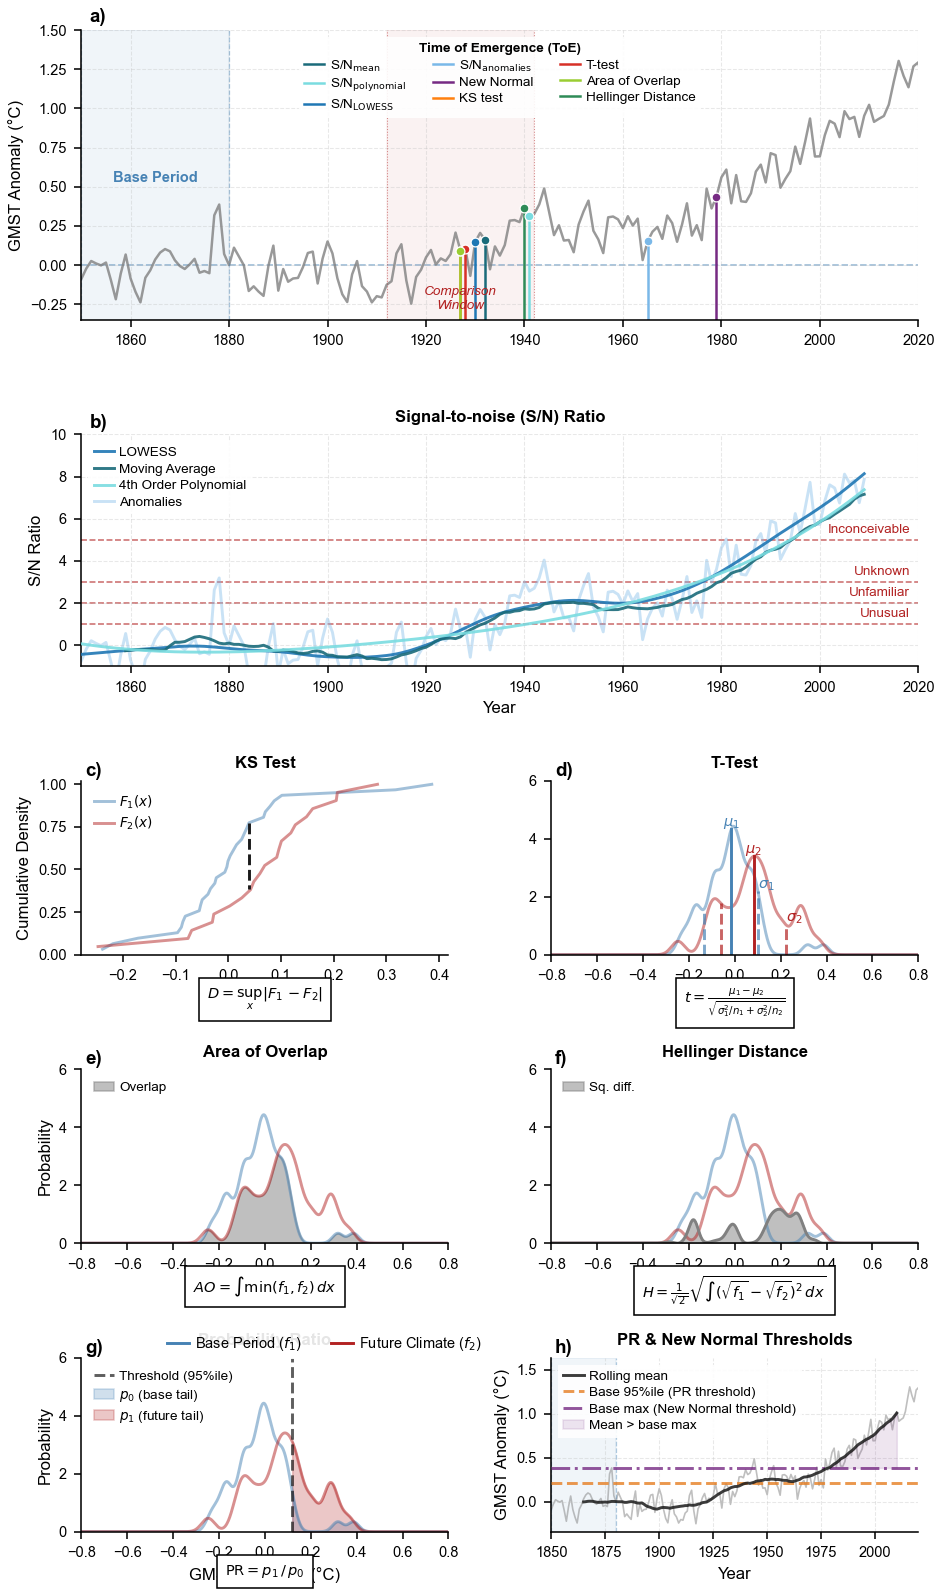

In [105]:
# ---------------------------------------------------------------------------
# Nature Reviews Earth & Environment – publication style
# ---------------------------------------------------------------------------

def apply_nature_rcparams() -> None:
    """Set matplotlib rcParams for Nature Reviews Earth & Environment style."""
    plt.rcParams.update({
        "font.family":           "sans-serif",
        "font.sans-serif":       ["Arial", "Helvetica Neue", "Helvetica",
                                   "Liberation Sans", "DejaVu Sans"],
        "font.size":             7,
        "mathtext.fontset":      "dejavusans",

        "axes.spines.top":       False,
        "axes.spines.right":     False,
        "axes.linewidth":        0.75,
        "axes.labelsize":        8,
        "axes.titlesize":        8,
        "axes.titleweight":      "bold",
        "axes.labelpad":         3,

        "xtick.labelsize":       7,
        "ytick.labelsize":       7,
        "xtick.major.width":     0.75,
        "ytick.major.width":     0.75,
        "xtick.minor.width":     0.5,
        "ytick.minor.width":     0.5,
        "xtick.major.size":      3.5,
        "ytick.major.size":      3.5,
        "xtick.minor.size":      2.0,
        "ytick.minor.size":      2.0,
        "xtick.direction":       "out",
        "ytick.direction":       "out",

        "legend.fontsize":       7,
        "legend.frameon":        True,
        "legend.framealpha":     0.9,
        "legend.edgecolor":      "none",
        "legend.borderpad":      0.4,
        "legend.labelspacing":   0.3,
        "legend.handlelength":   1.5,
        "legend.handletextpad":  0.4,
        "legend.fancybox":       False,

        "lines.linewidth":       1.2,
        "lines.markersize":      3.5,

        "grid.linewidth":        0.5,
        "grid.alpha":            0.35,
        "grid.linestyle":        "--",
        "grid.color":            "0.75",

        "figure.dpi":            150,
        "savefig.dpi":           300,
        "savefig.bbox":          "tight",
        "savefig.pad_inches":    0.05,

        "patch.linewidth":       0.75,
    })
apply_nature_rcparams()

import matplotlib.ticker as mticker

def convert_multi_to_name(arr):
    if len(arr) == 1:
        return toe_const.NAME_CONVERSION_DICT_SHORT.get(arr[0], arr[0])
    return '(' + ', '.join(toe_const.NAME_CONVERSION_DICT_SHORT.get(k, k) for k in arr) + ')'


"""
Plotting functions for the ToE method schematic figure (fig_02).

Restructured layout (v4):
  Row 1  – full-width GMST anomaly + signal overlays + ToE markers
  Row 2  – full-width S/N ratio (matched x-axis to Row 1)
  Row 3  – KS test | T-test                    (test-statistic pair)
  Row 4  – Area of Overlap | Hellinger Distance (distributional distance pair)
  Row 5  – PR tail illustration | Threshold time-series (PR + New Normal)

Style via S dict.  No rcParams side effects.
Organisation: style → helpers → compute → plot → annotate.
"""

from __future__ import annotations
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from scipy.stats import ks_2samp
from statsmodels.distributions.empirical_distribution import ECDF


# ── Style ────────────────────────────────────────────────────────────────

STYLE = {
    "base_color":      "steelblue",
    "future_color":    "firebrick",
    "ensemble_color":  "#a8c8e8",
    "ensemble_alpha":  0.7,
    "median_color":    "#1a1a1a",
    "plume_outer":     "#c6dbef",
    "plume_inner":     "#6baed6",
    "member_line":     "#5b9bd5",
    "emerged_color":   "#999999",
    "overlap_color":   "#8bc34a",
    "overlap_alpha":   0.20,
    "last_color":      "#e67e22",       # PR line colour
    "comp_color":      "firebrick",     # comparison-window shading
    "nn_color":        "#9b59b6",       # New Normal threshold colour
    "pr_thresh_color": "#e67e22",       # PR threshold colour
    # Typography (pt)
    "title": 8, "label": 8, "text": 7, "legend": 6.5, "tick": 7, "panel": 9,
    # Lines
    "lw": 1.4, "member_lw": 0.5, "marker_s": 18,
    # Annotation box position (axes fraction) for distributional panels
    "ann_xy": (0.5, -0.18),
}

S = STYLE

SIGNAL_NAME_MAP = {
    "sn_mean_base":   "Moving Average",
    "sn_poly_base":   "4th Order Polynomial",
    "sn_lowess_base": "LOWESS",
    "sn_anom_base":   "Anomalies",
}

# Styles for signal curves overlaid on the GMST panel (Row 1).
SIGNAL_OVERLAY_STYLES = {
    "signal_mean": {
        "color": "#444444", "lw": 1.3, "alpha": 0.75, "zorder": 4,
        "label": "Moving Avg.",
    },
    "signal_poly": {
        "color": "#cc7722", "lw": 1.3, "alpha": 0.75, "zorder": 4,
        "label": "4th-order Poly.",
    },
    "signal_lowess": {
        "color": "steelblue", "lw": 1.3, "alpha": 0.75, "zorder": 4,
        "label": "LOWESS",
    },
}

main_metrics = [
    'sn_mean_base', 'sn_poly_base', 'sn_lowess_base', 'sn_anom_base',
    'nn', 'ks', 'ttest', 'frac', 'hd',
]


# ── Helpers ──────────────────────────────────────────────────────────────

def _shade_base(ax, base_period):
    c = S["base_color"]
    ax.axvspan(base_period[0], base_period[1], color=c, alpha=0.08, zorder=0)
    ax.axvline(base_period[0], color=c, lw=0.6, ls="--", alpha=0.4)
    ax.axvline(base_period[1], color=c, lw=0.6, ls="--", alpha=0.4)


def _shade_comparison(ax, center_year, half_window=15):
    """Shade the comparison window on a time-series panel."""
    c = S["comp_color"]
    ax.axvspan(center_year - half_window, center_year + half_window,
               color=c, alpha=0.06, zorder=0)
    ax.axvline(center_year - half_window, color=c, lw=0.5, ls=":", alpha=0.5)
    ax.axvline(center_year + half_window, color=c, lw=0.5, ls=":", alpha=0.5)


def _grid(ax):
    ax.grid(True, ls="--", alpha=0.35)


def _ticks(ax):
    ax.tick_params(axis="both", labelsize=S["tick"], direction="out")


def _draw_kde(ax, x, kb, kf, *, labels=True):
    ax.plot(x, kb, color=S["base_color"], lw=S["lw"], alpha=0.5,
            label="Base Period" if labels else None)
    ax.plot(x, kf, color=S["future_color"], lw=S["lw"], alpha=0.5,
            label="Future Climate" if labels else None)


# ── Compute ──────────────────────────────────────────────────────────────

def compute_probability_ratio(data_ens, base_period, *,
                              event_quantile=0.95, rolling_window=30):
    """Rolling event probability and probability ratio."""
    ens_dim = "member"
    has_ens = ens_dim in data_ens.dims and data_ens.sizes[ens_dim] > 1
    q_dims = ["time"] + ([ens_dim] if has_ens else [])

    base = data_ens.sel(time=slice(str(base_period[0]), str(base_period[1])))
    thresh = float(base.quantile(event_quantile, dim=q_dims).values.item())

    event = xr.where(data_ens > thresh, 1.0, 0.0)
    p0 = max(float(event.sel(time=slice(str(base_period[0]), str(base_period[1])))
                   .mean(dim=q_dims).values.item()), 1e-6)

    p1 = event.rolling(time=rolling_window, center=True).mean()
    if has_ens:
        p1 = p1.mean(dim=ens_dim)

    pr = p1 / p0
    return pr.time.dt.year.values, p1.values, pr.values, p0


# ══════════════════════════════════════════════════════════════════════════
# Plot functions
# ══════════════════════════════════════════════════════════════════════════

def plot_gmst_and_toe(ax, smean_anom, toe_df, base_period, *,
                      smean_anom_ens=None, signal_ds=None,
                      signal_styles=None, comparison_year=None,
                      half_window=15):
    """Row 1: GMST anomaly time-series with signal overlays and ToE markers."""
    time = smean_anom.time.dt.year.values
    arr = smean_anom.values

    # Ensemble members
    if smean_anom_ens is not None:
        n = smean_anom_ens.sizes.get("member", 1)
        if "member" in smean_anom_ens.dims and n > 1:
            for i in range(n):
                ax.plot(time, smean_anom_ens.isel(member=i).values,
                        color=S["ensemble_color"], alpha=S["ensemble_alpha"],
                        lw=S["member_lw"])

    ax.plot(time, arr, lw=1.2, color="grey", alpha=0.8)

    # ── Signal overlays (LOWESS, moving average, polynomial) ──
    if signal_ds is not None:
        signal_styles = signal_styles or SIGNAL_OVERLAY_STYLES
        sig_time = signal_ds.time.dt.year.values
        for var, sty in signal_styles.items():
            if var in signal_ds.data_vars:
                ax.plot(sig_time, signal_ds[var].values,
                        color=sty.get("color", "black"),
                        lw=sty.get("lw", S["lw"]),
                        alpha=sty.get("alpha", 0.7),
                        zorder=sty.get("zorder", 3),
                        label=sty.get("label", var))

    # Base-period shading
    _shade_base(ax, base_period)
    ax.annotate("Base Period", xy=(np.mean(base_period), 0.53),
                fontsize=S["text"], ha="center",
                color=S["base_color"], fontweight="bold")

    # Comparison-window shading (links to distributional rows)
    if comparison_year is not None:
        _shade_comparison(ax, comparison_year, half_window)
        ax.annotate("Comparison\nWindow",
                    xy=(comparison_year, -0.28),
                    fontsize=S["text"] - 0.5, ha="center",
                    color=S["comp_color"], fontstyle="italic")

    ax.axhline(0, color=S["base_color"], ls="--", lw=S["lw"] * 0.6,
               alpha=0.5, zorder=1)

    # ToE markers
    for metric, year in toe_df.items():
        color = toe_plots.TEST_STYLES.get(metric, {"color": "black"})["color"]
        label = (toe_plots.METRIC_NAME_MAP_SHORT
                 .get(metric, metric).replace("base", "").replace(",", ""))
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.5, yval], label=label, alpha=1, color=color)
        ax.scatter([year], [yval], color=color, s=S["marker_s"],
                   zorder=100, edgecolors="white", linewidths=0.6)

    leg = ax.legend(fontsize=S["legend"], labelspacing=0.25,
                    handletextpad=0.4, loc="upper center", ncol=3)
    leg.set_title("Time of Emergence (ToE)",
                  prop={"size": S["legend"], "weight": "bold"})
    ax.set_ylabel("GMST Anomaly (°C)", fontsize=S["label"])
    ax.set_ylim(-0.35, 1.5)
    _grid(ax)
    _ticks(ax)


def plot_sn_ratio(ax, toe_metrics_ds, *, line_styles=None,
                  overlap_var=None):
    """Row 2: full-width S/N ratio curves with threshold lines."""
    line_styles = line_styles or {}
    sn_vars = [k for k in line_styles
               if k.startswith("sn_") and k in toe_metrics_ds.data_vars]

    for i, name in enumerate(sn_vars):
        color = dict(line_styles.get(name, {})).pop("color", "black")
        alpha = 0.4 if "anom" in name else 0.9
        zorder = 1 if "anom" in name else 5 + i
        ax.plot(toe_metrics_ds.time.dt.year.values,
                toe_metrics_ds[name].values,
                color=color, ls="solid", alpha=alpha, zorder=zorder,
                label=SIGNAL_NAME_MAP.get(name, name), lw=S["lw"])

    # Threshold lines
    tkw = dict(ls="--", color=S["future_color"], lw=S["lw"] * 0.55,
               alpha=0.65, zorder=0)
    for yval, label in [(1, "Unusual"), (2, "Unfamiliar"),
                        (3, "Unknown"), (5, "Inconceivable")]:
        ax.axhline(yval, **tkw)
        ax.annotate(label, xy=(1.0, yval), xycoords=("axes fraction", "data"),
                    xytext=(-4, 2), textcoords="offset points",
                    ha="right", va="bottom", size=S["text"] - 0.5,
                    color=S["future_color"], annotation_clip=False)

    ax.set_ylabel("S/N Ratio", fontsize=S["label"])
    ax.set_xlabel("Year", fontsize=S["label"])
    ax.set_title("Signal-to-noise (S/N) Ratio", fontsize=S["title"])
    ax.legend(fontsize=S["legend"], loc="upper left", ncol=1)
    _grid(ax)
    _ticks(ax)

    # Overlap twin axis
    ax_right = None
    if overlap_var and overlap_var in toe_metrics_ds.data_vars:
        ov = toe_metrics_ds[overlap_var]
        ax_right = ax.twinx()
        yrs, vals = ov.time.dt.year.values, ov.values
        ax_right.fill_between(yrs, vals, 100, color=S["overlap_color"],
                              alpha=S["overlap_alpha"], zorder=0)
        ax_right.plot(yrs, vals, color=S["overlap_color"], lw=S["lw"],
                      label="Area of\nOverlap", zorder=1)
        ax_right.set_ylim(100, 0)
        ax_right.set_ylabel("Overlap  %", fontsize=S["label"],
                            color=S["overlap_color"])
        ax_right.tick_params(axis="y", labelcolor=S["overlap_color"],
                             labelsize=S["tick"])
        ax_right.spines["right"].set_visible(True)
        ax_right.spines["right"].set_color(S["overlap_color"])
        ax_right.spines["right"].set_linewidth(0.75)
        ax_right.spines["top"].set_visible(False)

        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax_right.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=S["legend"], loc="upper left")

    return ax, ax_right


# ── Row 3: Test-statistic pair ───────────────────────────────────────────

def plot_ks_test(ax, smean_anom, base_period, emergence_year, *, window=10):
    """KS-test CDFs and max-statistic marker."""
    base = smean_anom.sel(
        time=slice(str(base_period[0]), str(base_period[1]))).values
    emrg = smean_anom.sel(
        time=slice(str(emergence_year - window),
                   str(emergence_year + window))).values
    ecdf_b, ecdf_e = ECDF(base), ECDF(emrg)
    ks = ks_2samp(base, emrg)

    ax.plot(ecdf_b.x, ecdf_b.y, color=S["base_color"], lw=S["lw"],
            alpha=0.5, label=r"$F_1(x)$")
    ax.plot(ecdf_e.x, ecdf_e.y, color=S["future_color"], lw=S["lw"],
            alpha=0.5, label=r"$F_2(x)$")

    mx = ks.statistic_location
    ax.plot([mx, mx], [ecdf_b(mx), ecdf_e(mx) + 0.05],
            color=S["median_color"], ls="--", lw=S["lw"])

    ax.annotate(
        r"$D = \sup_x |F_1 - F_2|$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )

    ax.set_ylabel("Cumulative Density", fontsize=S["label"])
    ax.set_ylim(0, 1.02)
    ax.set_title("KS Test", fontsize=S["title"])
    ax.legend(fontsize=S["legend"], loc="upper left")
    _ticks(ax)


def plot_ttest_panel(ax, x, kb, kf, base_arr, future_arr,
                     *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """T-test: KDE curves with mean/std markers."""
    from scipy.stats import ttest_ind

    _draw_kde(ax, x, kb, kf, labels=True)

    mb, mf = float(np.mean(base_arr)), float(np.mean(future_arr))
    sb, sf = float(np.std(base_arr)), float(np.std(future_arr))

    yb = kb[np.argmin(np.abs(x - mb))]
    yf = kf[np.argmin(np.abs(x - mf))]

    ax.plot([mb, mb], [0, yb], color=S["base_color"],   lw=S["lw"])
    ax.plot([mf, mf], [0, yf], color=S["future_color"], lw=S["lw"])

    ax.annotate(r"$\mu_1$", xy=(mb, yb + 0.1), ha="center",
                color=S["base_color"], fontsize=S["text"])
    ax.annotate(r"$\mu_2$", xy=(mf, yf + 0.1), ha="center",
                color=S["future_color"], fontsize=S["text"])

    for x_pos, kde, color in [(mb - sb, kb, S["base_color"]),
                               (mb + sb, kb, S["base_color"]),
                               (mf - sf, kf, S["future_color"]),
                               (mf + sf, kf, S["future_color"])]:
        y_top = kde[np.argmin(np.abs(x - x_pos))]
        ax.plot([x_pos, x_pos], [0, y_top], color=color,
                lw=S["lw"], ls="--", alpha=0.7)

    yb_sig = kb[np.argmin(np.abs(x - (mb + sb)))]
    yf_sig = kf[np.argmin(np.abs(x - (mf + sf)))]
    ax.annotate(r"$\sigma_1$", xy=(mb + sb, yb_sig + 0.1),
                ha="left", color=S["base_color"], fontsize=S["text"])
    ax.annotate(r"$\sigma_2$", xy=(mf + sf, yf_sig + 0.1),
                ha="left", color=S["future_color"], fontsize=S["text"])

    ax.annotate(
        r"$t = \frac{\mu_1-\mu_2}{\sqrt{\sigma_1^2/n_1+\sigma_2^2/n_2}}$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim, ylabel="Probability", title="T-Test")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    _ticks(ax)


# ── Row 4: Distributional distance pair ──────────────────────────────────

def plot_overlap_panel(ax, x, kb, kf, fga_overlap,
                       *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """Area of Overlap panel."""
    _draw_kde(ax, x, kb, kf, labels=False)
    ax.fill_between(x, 0, np.minimum(kb, kf), color="gray", alpha=0.5,
                    label="Overlap")
    ax.annotate(
        r"$AO = \int \min(f_1, f_2)\,dx$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )
    ax.set(xlim=xlim, ylim=ylim, ylabel="Probability",
           title="Area of Overlap")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(loc="upper left", fontsize=S["legend"])
    _ticks(ax)


def plot_hellinger_panel(ax, x, kb, kf,
                         *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """Hellinger Distance panel."""
    _draw_kde(ax, x, kb, kf, labels=False)
    sq = (np.sqrt(kb) - np.sqrt(kf)) ** 2
    ax.fill_between(x, 0, sq, color="gray", alpha=0.5, label="Sq. diff.")
    ax.plot(x, sq, color="gray", lw=S["lw"])
    ax.annotate(
        r"$H = \frac{1}{\sqrt{2}}\sqrt{\int(\sqrt{f_1}-\sqrt{f_2})^2\,dx}$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )
    ax.set(xlim=xlim, ylim=ylim, title="Hellinger Distance")
    ax.title.set_size(S["title"])
    ax.legend(loc="upper left", fontsize=S["legend"])
    _ticks(ax)


# ── Row 5: Threshold-based pair ──────────────────────────────────────────

def plot_pr_panel(ax, x, kb, kf, base_arr, future_arr,
                  *, xlim=(-0.8, 0.8), ylim=(0, 6),
                  event_quantile=0.95):
    """Probability Ratio — tail-area illustration."""
    _draw_kde(ax, x, kb, kf, labels=False)

    thresh = float(np.quantile(base_arr, event_quantile))
    ax.axvline(thresh, color=S["median_color"], ls="--", lw=S["lw"],
               alpha=0.7, label=f"Threshold ({event_quantile:.0%}ile)")

    mask = x >= thresh
    ax.fill_between(x[mask], 0, kb[mask], color=S["base_color"],
                    alpha=0.25, label=r"$p_0$ (base tail)")
    ax.fill_between(x[mask], 0, kf[mask], color=S["future_color"],
                    alpha=0.25, label=r"$p_1$ (future tail)")

    ax.annotate(
        r"$\mathrm{PR} = p_1\, /\, p_0$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim, ylabel="Probability",
           title="Probability Ratio")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(loc="upper left", fontsize=S["legend"])
    _ticks(ax)


def plot_threshold_panel(ax, smean_anom, base_period, *,
                         rolling_window=30, event_quantile=0.95):
    """Threshold time-series panel: GMST + rolling mean + two thresholds.

    Shows the raw anomaly, a rolling mean, and two horizontal lines:
      - 95th percentile of the base period  (PR threshold)
      - Maximum of the base period          (New Normal threshold)

    This visually grounds both the Probability Ratio and New Normal
    emergence concepts in the actual time series.
    """
    time = smean_anom.time.dt.year.values
    arr  = smean_anom.values

    # ── Raw anomaly ──
    ax.plot(time, arr, lw=0.8, color="grey", alpha=0.5, zorder=1)

    # ── Rolling mean ──
    roll = smean_anom.rolling(time=rolling_window, center=True).mean()
    ax.plot(time, roll.values, lw=S["lw"], color=S["median_color"],
            alpha=0.85, zorder=5, label="Rolling mean")

    # ── Base-period statistics ──
    base = smean_anom.sel(
        time=slice(str(base_period[0]), str(base_period[1]))).values
    base_max = float(np.nanmax(base))
    base_q95 = float(np.nanquantile(base, event_quantile))

    # ── Base-period shading ──
    _shade_base(ax, base_period)

    # ── Threshold lines ──
    # 95th percentile  →  PR threshold
    ax.axhline(base_q95, color=S["pr_thresh_color"], ls="--", lw=S["lw"],
               alpha=0.8, zorder=3,
               label=f"Base {event_quantile:.0%}ile (PR threshold)")

    # Max of base  →  New Normal threshold
    ax.axhline(base_max, color=toe_plots.TEST_STYLES['nn']['color'], ls="-.", lw=S["lw"],
               alpha=0.8, zorder=3,
               label="Base max (New Normal threshold)")

    # ── Shade above max to highlight NN emergence ──
    roll_vals = roll.values
    mask_nn = roll_vals > base_max
    ax.fill_between(time, base_max, roll_vals,
                    where=mask_nn,
                    color=toe_plots.TEST_STYLES['nn']['color'], alpha=0.12, zorder=2,
                    label="Mean > base max")

    ax.set_ylabel("GMST Anomaly (°C)", fontsize=S["label"])
    ax.set_xlabel("Year", fontsize=S["label"])
    ax.set_title("PR & New Normal Thresholds", fontsize=S["title"])
    ax.legend(fontsize=S["legend"], loc="upper left")
    _grid(ax)
    _ticks(ax)


# ── Orchestration helpers ────────────────────────────────────────────────

def plot_distributional_panels(ax_tt, ax_ov, ax_hd, ax_pr,
                               smean_anom, emergence_year, fga_fn,
                               *, base_window=50, half_window=15):
    """Compute KDE data once and populate T-test, AO, Hellinger, PR panels."""
    start_year = int(smean_anom.time.dt.year.values[0])
    base_arr = smean_anom.isel(time=slice(0, base_window)).values
    idx = emergence_year - start_year - half_window
    future_arr = smean_anom.isel(time=slice(idx, idx + 30)).values

    x, kf, kb, ov = fga_fn(base_arr, future_arr, return_all=True,
                            method_kwargs=dict(bw_method=0.2),
                            bmin=-0.6, bmax=0.6)

    plot_ttest_panel(ax_tt, x, kb, kf, base_arr, future_arr)
    plot_overlap_panel(ax_ov, x, kb, kf, ov)
    plot_hellinger_panel(ax_hd, x, kb, kf)
    plot_pr_panel(ax_pr, x, kb, kf, base_arr, future_arr)


# ── Standalone helpers (not in main fig) ─────────────────────────────────

def plot_event_probability(ax, years, p1, p0):
    """Rolling event-probability curve (standalone)."""
    ax.plot(years, p1, color=S["base_color"], lw=S["lw"],
            label=r"Rolling event probability $p_1(t)$")
    ax.axhline(p0, color=S["future_color"], ls="--", lw=S["lw"],
               label=f"Base probability $p_0$ = {p0:.3f}")
    ax.set(ylabel="Probability", title="Event Probability: Base vs Rolling")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(fontsize=S["legend"])
    _grid(ax)
    _ticks(ax)


def plot_probability_ratio_ts(ax, years, pr):
    """Probability Ratio time-series (standalone)."""
    c = S["future_color"]
    ax.plot(years, pr, color=S["last_color"], lw=S["lw"],
            label=r"PR = $p_1(t)/p_0$")
    ax.axhline(1, color=c, ls="--", lw=S["lw"] * 0.8)
    ax.axhline(2, color=c, ls=":", lw=S["lw"] * 0.7)
    ax.annotate("No change (PR=1)", xy=(years[5], 1.02), color=c,
                fontsize=S["text"])
    ax.annotate("PR=2", xy=(years[5], 2.05), color=c, fontsize=S["text"])
    ax.set(ylabel="Probability Ratio", xlabel="Year",
           title="Probability Ratio Demonstration")
    ax.yaxis.label.set_size(S["label"])
    ax.xaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(fontsize=S["legend"])
    _grid(ax)
    _ticks(ax)


# ── Annotation ───────────────────────────────────────────────────────────

def annotate_panels(axes, *, xy=(0.01, 1.03), xy_overrides=None):
    """Bold a), b), … panel labels."""
    xy_overrides = xy_overrides or {}
    for i, ax in enumerate(axes):
        pos = xy_overrides.get(i, xy)
        ax.annotate(f"{chr(97 + i)})", xy=pos, xycoords="axes fraction",
                    fontsize=S["panel"], fontweight="bold")


# ═══════════════════════════════════════════════════════════════════════════
# fig_02 — ToE method schematic  (v4)
# ═══════════════════════════════════════════════════════════════════════════
#
#   Row 1  GMST anomaly + signal overlays + ToE markers    [full width]
#   Row 2  S/N ratio time-series                           [full width]
#   Row 3  KS test | T-test                                [test-stat pair]
#   Row 4  Area of Overlap | Hellinger Distance            [dist-distance pair]
#   Row 5  PR tail (distributional) | PR+NN thresholds     [threshold pair]
#
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Build figure / GridSpec ────────────────────────────────────────────
fig = plt.figure(figsize=(7.2, 13.0))

gs = gridspec.GridSpec(
    5, 1,
    height_ratios=[1.0, 0.8, 0.6, 0.6, 0.6],
    hspace=0.55,
)

ax_gmst = fig.add_subplot(gs[0])          # Row 1 – full width
ax_sn   = fig.add_subplot(gs[1])          # Row 2 – full width

# Row 3 – test-statistic pair
row3 = gs[2].subgridspec(1, 2, wspace=0.28)
ax_ks = fig.add_subplot(row3[0])
ax_tt = fig.add_subplot(row3[1])

# Row 4 – distributional distance pair
row4 = gs[3].subgridspec(1, 2, wspace=0.28)
ax_ov = fig.add_subplot(row4[0])
ax_hd = fig.add_subplot(row4[1])

# Row 5 – threshold-based pair
row5 = gs[4].subgridspec(1, 2, wspace=0.28)
ax_pr   = fig.add_subplot(row5[0])
ax_thre = fig.add_subplot(row5[1])


# ── 2. Determine the comparison-window year ──────────────────────────────
comparison_year = int(toe_ds['frac'].isel(member_kwargs).values.item())


# ── 3. Draw panels ───────────────────────────────────────────────────────

# Row 1: GMST + signal overlays + ToE markers
# Uncomment signal_ds when your signal variables are available:
plot_gmst_and_toe(
    ax_gmst, smean_anom_ds,
    toe_df.loc[main_metrics],
    base_period_tuple,
    # signal_ds=toe_metrics_ds[['signal_mean','signal_poly','signal_lowess']].isel(member_kwargs),
    comparison_year=comparison_year,
    half_window=15,
)

# Row 2: S/N ratio
plot_sn_ratio(
    ax_sn,
    toe_metrics_ds[main_metrics].isel(member_kwargs),
    line_styles=toe_plots.TEST_STYLES,
    overlap_var='fga',
)

# Row 3: KS + T-test  (KS plotted separately — needs xarray input)
plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=int(toe_ds['ks'].isel(member_kwargs).values.item()),
)

# Rows 3-5 distributional panels (T-test, AO, Hellinger, PR)
plot_distributional_panels(
    ax_tt, ax_ov, ax_hd, ax_pr,
    smean_anom_ds,
    emergence_year=comparison_year,
    fga_fn=toe.fractional_geometric_area,
)

# Row 5 right: threshold time-series for PR + New Normal
plot_threshold_panel(
    ax_thre, smean_anom_ds, base_period_tuple,
    rolling_window=30, event_quantile=0.95,
)


# ── 4. Axis limits & shared labels ───────────────────────────────────────
for ax in [ax_gmst, ax_sn, ax_thre]:
    ax.set_xlim(1850, 2020)
ax_sn.set_ylim(-1, 10)

# Row 3: right panel drops y-label
ax_tt.set_ylabel("")

# Row 4: right panel drops y-label
ax_hd.set_ylabel("")

# x-labels: only bottom of each column gets x-label
# Left column:  KS (no xlabel) → AO (no xlabel) → PR (xlabel)
ax_ks.set_xlabel("")
ax_ov.set_xlabel("")
ax_pr.set_xlabel("GMST Anomaly (°C)", fontsize=S["label"])

# Right column: T-test (no xlabel) → HD (no xlabel) → threshold (has own)
ax_tt.set_xlabel("")
ax_hd.set_xlabel("")

# Shared base/future legend between Rows 4 and 5
from matplotlib.lines import Line2D
dist_handles = [
    Line2D([0], [0], color=S["base_color"], lw=S["lw"],
           label=r"Base Period ($f_1$)"),
    Line2D([0], [0], color=S["future_color"], lw=S["lw"],
           label=r"Future Climate ($f_2$)"),
]
fig.legend(handles=dist_handles, loc="lower center",
           ncol=2, fontsize=S["legend"] + 0.5,
           bbox_to_anchor=(0.35, 0.195),   # centred under left column
           frameon=True, edgecolor="none")


# ── 5. Panel letters ─────────────────────────────────────────────────────
all_axes = [ax_gmst, ax_sn, ax_ks, ax_tt, ax_ov, ax_hd, ax_pr, ax_thre]
annotate_panels(all_axes)


fig.savefig('fig_02.png')

# Major Update #1

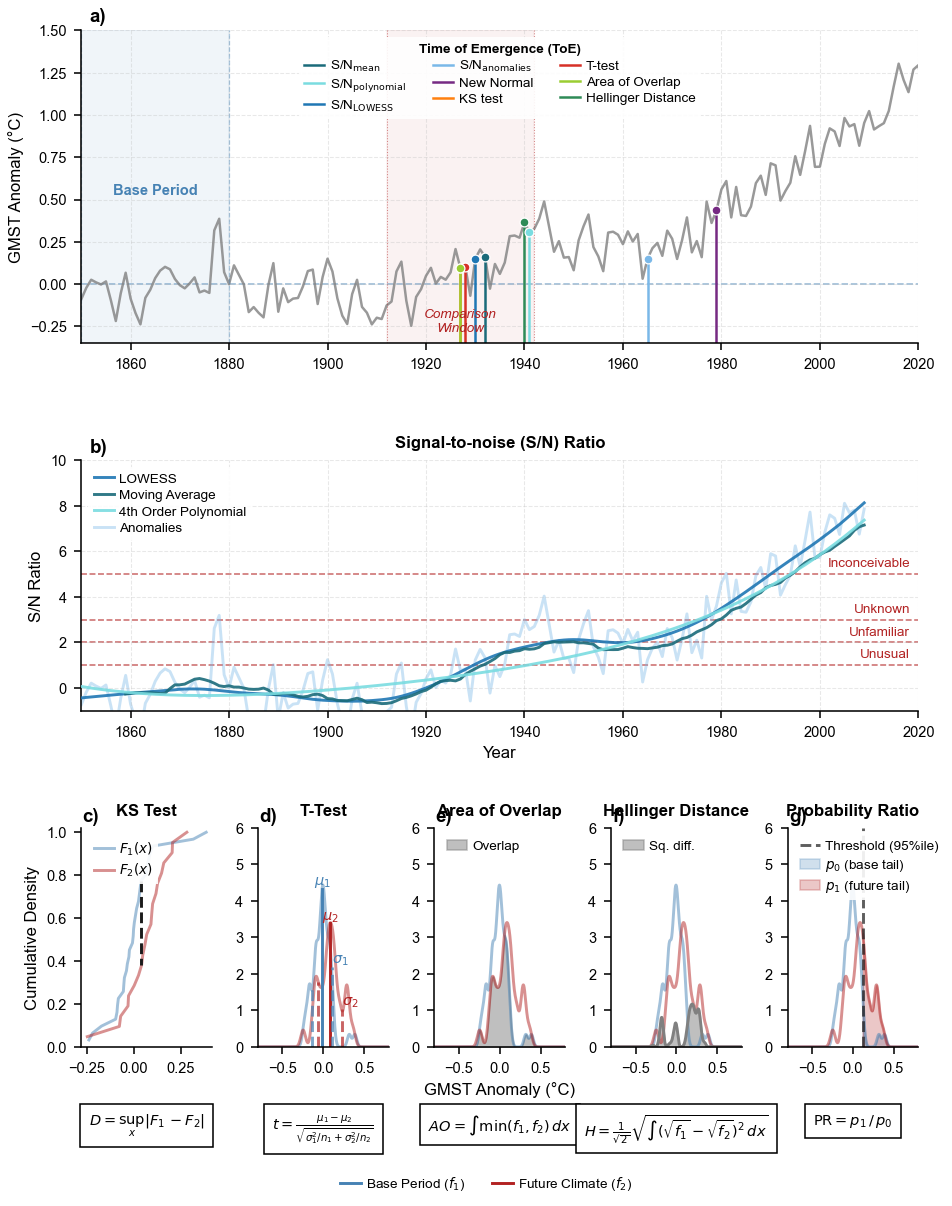

In [106]:
# ---------------------------------------------------------------------------
# Nature Reviews Earth & Environment – publication style
# ---------------------------------------------------------------------------

def apply_nature_rcparams() -> None:
    """Set matplotlib rcParams for Nature Reviews Earth & Environment style."""
    plt.rcParams.update({
        "font.family":           "sans-serif",
        "font.sans-serif":       ["Arial", "Helvetica Neue", "Helvetica",
                                   "Liberation Sans", "DejaVu Sans"],
        "font.size":             7,
        "mathtext.fontset":      "dejavusans",

        "axes.spines.top":       False,
        "axes.spines.right":     False,
        "axes.linewidth":        0.75,
        "axes.labelsize":        8,
        "axes.titlesize":        8,
        "axes.titleweight":      "bold",
        "axes.labelpad":         3,

        "xtick.labelsize":       7,
        "ytick.labelsize":       7,
        "xtick.major.width":     0.75,
        "ytick.major.width":     0.75,
        "xtick.minor.width":     0.5,
        "ytick.minor.width":     0.5,
        "xtick.major.size":      3.5,
        "ytick.major.size":      3.5,
        "xtick.minor.size":      2.0,
        "ytick.minor.size":      2.0,
        "xtick.direction":       "out",
        "ytick.direction":       "out",

        "legend.fontsize":       7,
        "legend.frameon":        True,
        "legend.framealpha":     0.9,
        "legend.edgecolor":      "none",
        "legend.borderpad":      0.4,
        "legend.labelspacing":   0.3,
        "legend.handlelength":   1.5,
        "legend.handletextpad":  0.4,
        "legend.fancybox":       False,

        "lines.linewidth":       1.2,
        "lines.markersize":      3.5,

        "grid.linewidth":        0.5,
        "grid.alpha":            0.35,
        "grid.linestyle":        "--",
        "grid.color":            "0.75",

        "figure.dpi":            150,
        "savefig.dpi":           300,
        "savefig.bbox":          "tight",
        "savefig.pad_inches":    0.05,

        "patch.linewidth":       0.75,
    })
apply_nature_rcparams()

import matplotlib.ticker as mticker

def convert_multi_to_name(arr):
    if len(arr) == 1:
        return toe_const.NAME_CONVERSION_DICT_SHORT.get(arr[0], arr[0])
    return '(' + ', '.join(toe_const.NAME_CONVERSION_DICT_SHORT.get(k, k) for k in arr) + ')'


"""
Plotting functions for the ToE method schematic figure (fig_02).

Restructured layout (v2):
  Row 1  – full-width GMST anomaly + ToE markers
  Row 2  – full-width S/N ratio (matched x-axis to Row 1)
  Row 3  – five equal distributional panels: KS | T-test | AO | Hellinger | PR

Style via S dict.  No rcParams side effects.
Organisation: style → helpers → compute → plot → annotate.
"""

from __future__ import annotations
from typing import Dict, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from scipy.stats import ks_2samp
from statsmodels.distributions.empirical_distribution import ECDF


# ── Style ────────────────────────────────────────────────────────────────

STYLE = {
    "base_color":      "steelblue",
    "future_color":    "firebrick",
    "ensemble_color":  "#a8c8e8",
    "ensemble_alpha":  0.7,
    "median_color":    "#1a1a1a",
    "plume_outer":     "#c6dbef",
    "plume_inner":     "#6baed6",
    "member_line":     "#5b9bd5",
    "emerged_color":   "#999999",
    "overlap_color":   "#8bc34a",
    "overlap_alpha":   0.20,
    "last_color":      "#e67e22",       # PR line colour
    "comp_color":      "firebrick",     # comparison-window shading
    # Typography (pt)
    "title": 8, "label": 8, "text": 7, "legend": 6.5, "tick": 7, "panel": 9,
    # Lines
    "lw": 1.4, "member_lw": 0.5, "marker_s": 18,
    # Annotation box position (axes fraction) for distributional panels
    "ann_xy": (0.5, -0.30),
}

S = STYLE

SIGNAL_NAME_MAP = {
    "sn_mean_base":   "Moving Average",
    "sn_poly_base":   "4th Order Polynomial",
    "sn_lowess_base": "LOWESS",
    "sn_anom_base":   "Anomalies",
}

main_metrics = [
    'sn_mean_base', 'sn_poly_base', 'sn_lowess_base', 'sn_anom_base',
    'nn', 'ks', 'ttest', 'frac', 'hd',
]


# ── Helpers ──────────────────────────────────────────────────────────────

def _shade_base(ax, base_period):
    c = S["base_color"]
    ax.axvspan(base_period[0], base_period[1], color=c, alpha=0.08, zorder=0)
    ax.axvline(base_period[0], color=c, lw=0.6, ls="--", alpha=0.4)
    ax.axvline(base_period[1], color=c, lw=0.6, ls="--", alpha=0.4)


def _shade_comparison(ax, center_year, half_window=15):
    """Shade the comparison window on a time-series panel to link to
    the distributional panels below."""
    c = S["comp_color"]
    ax.axvspan(center_year - half_window, center_year + half_window,
               color=c, alpha=0.06, zorder=0)
    ax.axvline(center_year - half_window, color=c, lw=0.5, ls=":", alpha=0.5)
    ax.axvline(center_year + half_window, color=c, lw=0.5, ls=":", alpha=0.5)


def _grid(ax):
    ax.grid(True, ls="--", alpha=0.35)


def _ticks(ax):
    ax.tick_params(axis="both", labelsize=S["tick"], direction="out")


def _draw_kde(ax, x, kb, kf, *, labels=True):
    ax.plot(x, kb, color=S["base_color"], lw=S["lw"], alpha=0.5,
            label="Base Period" if labels else None)
    ax.plot(x, kf, color=S["future_color"], lw=S["lw"], alpha=0.5,
            label="Future Climate" if labels else None)


# ── Compute ──────────────────────────────────────────────────────────────

def compute_probability_ratio(data_ens, base_period, *,
                              event_quantile=0.95, rolling_window=30):
    """Rolling event probability and probability ratio."""
    ens_dim = "member"
    has_ens = ens_dim in data_ens.dims and data_ens.sizes[ens_dim] > 1
    q_dims = ["time"] + ([ens_dim] if has_ens else [])

    base = data_ens.sel(time=slice(str(base_period[0]), str(base_period[1])))
    thresh = float(base.quantile(event_quantile, dim=q_dims).values.item())

    event = xr.where(data_ens > thresh, 1.0, 0.0)
    p0 = max(float(event.sel(time=slice(str(base_period[0]), str(base_period[1])))
                   .mean(dim=q_dims).values.item()), 1e-6)

    p1 = event.rolling(time=rolling_window, center=True).mean()
    if has_ens:
        p1 = p1.mean(dim=ens_dim)

    pr = p1 / p0
    return pr.time.dt.year.values, p1.values, pr.values, p0


# ── Plot functions ───────────────────────────────────────────────────────

def plot_gmst_and_toe(ax, smean_anom, toe_df, base_period, *,
                      smean_anom_ens=None, comparison_year=None,
                      half_window=15):
    """Row 1: GMST anomaly time-series with ToE vertical markers.

    If *comparison_year* is given, a subtle shading marks the comparison
    window used by the distributional panels in Row 3.
    """
    time = smean_anom.time.dt.year.values
    arr = smean_anom.values

    # Ensemble members
    if smean_anom_ens is not None:
        n = smean_anom_ens.sizes.get("member", 1)
        if "member" in smean_anom_ens.dims and n > 1:
            for i in range(n):
                ax.plot(time, smean_anom_ens.isel(member=i).values,
                        color=S["ensemble_color"], alpha=S["ensemble_alpha"],
                        lw=S["member_lw"])

    ax.plot(time, arr, lw=1.2, color="grey", alpha=0.8)

    # Base-period shading
    _shade_base(ax, base_period)
    ax.annotate("Base Period", xy=(np.mean(base_period), 0.53),
                fontsize=S["text"], ha="center",
                color=S["base_color"], fontweight="bold")

    # Comparison-window shading (links to Row 3)
    if comparison_year is not None:
        _shade_comparison(ax, comparison_year, half_window)
        ax.annotate("Comparison\nWindow",
                    xy=(comparison_year, -0.28),
                    fontsize=S["text"] - 0.5, ha="center",
                    color=S["comp_color"], fontstyle="italic")

    ax.axhline(0, color=S["base_color"], ls="--", lw=S["lw"] * 0.6,
               alpha=0.5, zorder=1)

    # ToE markers
    for metric, year in toe_df.items():
        color = toe_plots.TEST_STYLES.get(metric, {"color": "black"})["color"]
        label = (toe_plots.METRIC_NAME_MAP_SHORT
                 .get(metric, metric).replace("base", "").replace(",", ""))
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.5, yval], label=label, alpha=1, color=color)
        ax.scatter([year], [yval], color=color, s=S["marker_s"],
                   zorder=100, edgecolors="white", linewidths=0.6)

    leg = ax.legend(fontsize=S["legend"], labelspacing=0.25,
                    handletextpad=0.4, loc="upper center", ncol=3)
    leg.set_title("Time of Emergence (ToE)",
                  prop={"size": S["legend"], "weight": "bold"})
    ax.set_ylabel("GMST Anomaly (°C)", fontsize=S["label"])
    ax.set_ylim(-0.35, 1.5)
    _grid(ax)
    _ticks(ax)


def plot_sn_ratio(ax, toe_metrics_ds, *, line_styles=None,
                  overlap_var=None):
    """Row 2: full-width S/N ratio curves with threshold lines.

    Optionally adds an overlap % twin axis.
    """
    line_styles = line_styles or {}
    sn_vars = [k for k in line_styles
               if k.startswith("sn_") and k in toe_metrics_ds.data_vars]

    for i, name in enumerate(sn_vars):
        color = dict(line_styles.get(name, {})).pop("color", "black")
        alpha = 0.4 if "anom" in name else 0.9
        zorder = 1 if "anom" in name else 5 + i
        ax.plot(toe_metrics_ds.time.dt.year.values,
                toe_metrics_ds[name].values,
                color=color, ls="solid", alpha=alpha, zorder=zorder,
                label=SIGNAL_NAME_MAP.get(name, name), lw=S["lw"])

    # Threshold lines
    tkw = dict(ls="--", color=S["future_color"], lw=S["lw"] * 0.55,
               alpha=0.65, zorder=0)
    for yval, label in [(1, "Unusual"), (2, "Unfamiliar"),
                        (3, "Unknown"), (5, "Inconceivable")]:
        ax.axhline(yval, **tkw)
        ax.annotate(label, xy=(1.0, yval), xycoords=("axes fraction", "data"),
                    xytext=(-4, 2), textcoords="offset points",
                    ha="right", va="bottom", size=S["text"] - 0.5,
                    color=S["future_color"], annotation_clip=False)

    ax.set_ylabel("S/N Ratio", fontsize=S["label"])
    ax.set_xlabel("Year", fontsize=S["label"])
    ax.set_title("Signal-to-noise (S/N) Ratio", fontsize=S["title"])
    ax.legend(fontsize=S["legend"], loc="upper left", ncol=1)
    _grid(ax)
    _ticks(ax)

    # Overlap twin axis
    ax_right = None
    if overlap_var and overlap_var in toe_metrics_ds.data_vars:
        ov = toe_metrics_ds[overlap_var]
        ax_right = ax.twinx()
        yrs, vals = ov.time.dt.year.values, ov.values
        ax_right.fill_between(yrs, vals, 100, color=S["overlap_color"],
                              alpha=S["overlap_alpha"], zorder=0)
        ax_right.plot(yrs, vals, color=S["overlap_color"], lw=S["lw"],
                      label="Area of\nOverlap", zorder=1)
        ax_right.set_ylim(100, 0)
        ax_right.set_ylabel("Overlap  %", fontsize=S["label"],
                            color=S["overlap_color"])
        ax_right.tick_params(axis="y", labelcolor=S["overlap_color"],
                             labelsize=S["tick"])
        ax_right.spines["right"].set_visible(True)
        ax_right.spines["right"].set_color(S["overlap_color"])
        ax_right.spines["right"].set_linewidth(0.75)
        ax_right.spines["top"].set_visible(False)

        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax_right.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=S["legend"], loc="upper left")

    return ax, ax_right


def plot_ks_test(ax, smean_anom, base_period, emergence_year, *, window=10):
    """Row 3 panel 1: KS-test CDFs."""
    base = smean_anom.sel(
        time=slice(str(base_period[0]), str(base_period[1]))).values
    emrg = smean_anom.sel(
        time=slice(str(emergence_year - window),
                   str(emergence_year + window))).values
    ecdf_b, ecdf_e = ECDF(base), ECDF(emrg)
    ks = ks_2samp(base, emrg)

    ax.plot(ecdf_b.x, ecdf_b.y, color=S["base_color"], lw=S["lw"],
            alpha=0.5, label=r"$F_1(x)$")
    ax.plot(ecdf_e.x, ecdf_e.y, color=S["future_color"], lw=S["lw"],
            alpha=0.5, label=r"$F_2(x)$")

    mx = ks.statistic_location
    ax.plot([mx, mx], [ecdf_b(mx), ecdf_e(mx) + 0.05],
            color=S["median_color"], ls="--", lw=S["lw"])

    ax.annotate(
        r"$D = \sup_x |F_1 - F_2|$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )

    ax.set_ylabel("Cumulative Density", fontsize=S["label"])
    ax.set_ylim(0, 1.02)
    ax.set_title("KS Test", fontsize=S["title"])
    ax.legend(fontsize=S["legend"], loc="upper left")
    _ticks(ax)


def plot_ttest_panel(ax, x, kb, kf, base_arr, future_arr,
                     *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """Row 3 panel 2: T-test KDE curves with mean/std markers."""
    from scipy.stats import ttest_ind

    _draw_kde(ax, x, kb, kf, labels=True)

    mb, mf = float(np.mean(base_arr)), float(np.mean(future_arr))
    sb, sf = float(np.std(base_arr)), float(np.std(future_arr))

    yb = kb[np.argmin(np.abs(x - mb))]
    yf = kf[np.argmin(np.abs(x - mf))]

    ax.plot([mb, mb], [0, yb], color=S["base_color"],   lw=S["lw"])
    ax.plot([mf, mf], [0, yf], color=S["future_color"], lw=S["lw"])

    ax.annotate(r"$\mu_1$", xy=(mb, yb + 0.1), ha="center",
                color=S["base_color"], fontsize=S["text"])
    ax.annotate(r"$\mu_2$", xy=(mf, yf + 0.1), ha="center",
                color=S["future_color"], fontsize=S["text"])

    for x_pos, kde, color in [(mb - sb, kb, S["base_color"]),
                               (mb + sb, kb, S["base_color"]),
                               (mf - sf, kf, S["future_color"]),
                               (mf + sf, kf, S["future_color"])]:
        y_top = kde[np.argmin(np.abs(x - x_pos))]
        ax.plot([x_pos, x_pos], [0, y_top], color=color,
                lw=S["lw"], ls="--", alpha=0.7)

    yb_sig = kb[np.argmin(np.abs(x - (mb + sb)))]
    yf_sig = kf[np.argmin(np.abs(x - (mf + sf)))]
    ax.annotate(r"$\sigma_1$", xy=(mb + sb, yb_sig + 0.1),
                ha="left", color=S["base_color"], fontsize=S["text"])
    ax.annotate(r"$\sigma_2$", xy=(mf + sf, yf_sig + 0.1),
                ha="left", color=S["future_color"], fontsize=S["text"])

    ax.annotate(
        r"$t = \frac{\mu_1-\mu_2}{\sqrt{\sigma_1^2/n_1+\sigma_2^2/n_2}}$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim, ylabel="Probability", title="T-Test")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    _ticks(ax)


def plot_overlap_panel(ax, x, kb, kf, fga_overlap,
                       *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """Row 3 panel 3: Area of Overlap."""
    _draw_kde(ax, x, kb, kf, labels=False)
    ax.fill_between(x, 0, np.minimum(kb, kf), color="gray", alpha=0.5,
                    label="Overlap")
    ax.annotate(
        r"$AO = \int \min(f_1, f_2)\,dx$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )
    ax.set(xlim=xlim, ylim=ylim, title="Area of Overlap")
    ax.title.set_size(S["title"])
    ax.legend(loc="upper left", fontsize=S["legend"])
    _ticks(ax)


def plot_hellinger_panel(ax, x, kb, kf,
                         *, xlim=(-0.8, 0.8), ylim=(0, 6)):
    """Row 3 panel 4: Hellinger Distance."""
    _draw_kde(ax, x, kb, kf, labels=False)
    sq = (np.sqrt(kb) - np.sqrt(kf)) ** 2
    ax.fill_between(x, 0, sq, color="gray", alpha=0.5, label="Sq. diff.")
    ax.plot(x, sq, color="gray", lw=S["lw"])
    ax.annotate(
        r"$H = \frac{1}{\sqrt{2}}\sqrt{\int(\sqrt{f_1}-\sqrt{f_2})^2\,dx}$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )
    ax.set(xlim=xlim, ylim=ylim, title="Hellinger Distance")
    ax.title.set_size(S["title"])
    ax.legend(loc="upper left", fontsize=S["legend"])
    _ticks(ax)


def plot_pr_panel(ax, x, kb, kf, base_arr, future_arr,
                  *, xlim=(-0.8, 0.8), ylim=(0, 6),
                  event_quantile=0.95):
    """Row 3 panel 5: Probability Ratio — tail-area illustration.

    Shows base and future KDEs with a threshold (vertical line at the
    base-period event_quantile), shading the exceedance tails, and the
    PR = p₂/p₁ equation below.
    """
    _draw_kde(ax, x, kb, kf, labels=False)

    # Threshold from base distribution
    thresh = float(np.quantile(base_arr, event_quantile))
    ax.axvline(thresh, color=S["median_color"], ls="--", lw=S["lw"],
               alpha=0.7, label=f"Threshold ({event_quantile:.0%}ile)")

    # Shade exceedance tails
    mask = x >= thresh
    ax.fill_between(x[mask], 0, kb[mask], color=S["base_color"],
                    alpha=0.25, label=r"$p_0$ (base tail)")
    ax.fill_between(x[mask], 0, kf[mask], color=S["future_color"],
                    alpha=0.25, label=r"$p_1$ (future tail)")

    # Equation
    ax.annotate(
        r"$\mathrm{PR} = p_1\, /\, p_0$",
        xy=S["ann_xy"], xycoords="axes fraction",
        ha="center", va="top",
        bbox=dict(edgecolor="black", facecolor="white"),
        fontsize=S["text"],
    )

    ax.set(xlim=xlim, ylim=ylim, title="Probability Ratio")
    ax.title.set_size(S["title"])
    ax.legend(loc="upper left", fontsize=S["legend"])
    _ticks(ax)


# ── Orchestration helpers ────────────────────────────────────────────────

def plot_lower_panels(ax_ks, ax_tt, ax_ov, ax_hd, ax_pr,
                      smean_anom, base_period, emergence_year, fga_fn,
                      *, base_window=50, half_window=15):
    """Populate all five Row-3 distributional panels."""
    start_year = int(smean_anom.time.dt.year.values[0])
    base_arr = smean_anom.isel(time=slice(0, base_window)).values
    idx = emergence_year - start_year - half_window
    future_arr = smean_anom.isel(time=slice(idx, idx + 30)).values

    x, kf, kb, ov = fga_fn(base_arr, future_arr, return_all=True,
                            method_kwargs=dict(bw_method=0.2),
                            bmin=-0.6, bmax=0.6)

    # KS is plotted separately (needs xarray input), but share KDE data
    plot_ttest_panel(ax_tt, x, kb, kf, base_arr, future_arr)
    plot_overlap_panel(ax_ov, x, kb, kf, ov)
    plot_hellinger_panel(ax_hd, x, kb, kf)
    plot_pr_panel(ax_pr, x, kb, kf, base_arr, future_arr)


def plot_event_probability(ax, years, p1, p0):
    """Rolling event-probability curve (standalone, not used in main fig)."""
    ax.plot(years, p1, color=S["base_color"], lw=S["lw"],
            label=r"Rolling event probability $p_1(t)$")
    ax.axhline(p0, color=S["future_color"], ls="--", lw=S["lw"],
               label=f"Base probability $p_0$ = {p0:.3f}")
    ax.set(ylabel="Probability", title="Event Probability: Base vs Rolling")
    ax.yaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(fontsize=S["legend"])
    _grid(ax)
    _ticks(ax)


def plot_probability_ratio_ts(ax, years, pr):
    """Probability Ratio time-series (standalone, not used in main fig)."""
    c = S["future_color"]
    ax.plot(years, pr, color=S["last_color"], lw=S["lw"],
            label=r"PR = $p_1(t)/p_0$")
    ax.axhline(1, color=c, ls="--", lw=S["lw"] * 0.8)
    ax.axhline(2, color=c, ls=":", lw=S["lw"] * 0.7)
    ax.annotate("No change (PR=1)", xy=(years[5], 1.02), color=c,
                fontsize=S["text"])
    ax.annotate("PR=2", xy=(years[5], 2.05), color=c, fontsize=S["text"])
    ax.set(ylabel="Probability Ratio", xlabel="Year",
           title="Probability Ratio Demonstration")
    ax.yaxis.label.set_size(S["label"])
    ax.xaxis.label.set_size(S["label"])
    ax.title.set_size(S["title"])
    ax.legend(fontsize=S["legend"])
    _grid(ax)
    _ticks(ax)


# ── Annotation ───────────────────────────────────────────────────────────

def annotate_panels(axes, *, xy=(0.01, 1.03), xy_overrides=None):
    """Bold a), b), … panel labels."""
    xy_overrides = xy_overrides or {}
    for i, ax in enumerate(axes):
        pos = xy_overrides.get(i, xy)
        ax.annotate(f"{chr(97 + i)})", xy=pos, xycoords="axes fraction",
                    fontsize=S["panel"], fontweight="bold")


def add_shared_dist_legend(fig, axes_row3):
    """Shared Base Period / Future Climate legend below Row 3,
    centred under the middle panel."""
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0], [0], color=S["base_color"], lw=S["lw"],
               label=r"Base Period ($f_1$)"),
        Line2D([0], [0], color=S["future_color"], lw=S["lw"],
               label=r"Future Climate ($f_2$)"),
    ]
    fig.legend(handles=handles, loc="lower center",
               ncol=2, fontsize=S["legend"],
               bbox_to_anchor=(0.5, -0.01), frameon=True,
               edgecolor="none")


# ═══════════════════════════════════════════════════════════════════════════
# fig_02 — ToE method schematic  (restructured v2)
# ═══════════════════════════════════════════════════════════════════════════
#
#   Row 1  GMST anomaly + ToE markers              [full width]
#   Row 2  S/N ratio time-series                    [full width]
#   Row 3  KS | T-test | AO | Hellinger | PR       [5 equal panels]
#
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Build figure / GridSpec ────────────────────────────────────────────
fig = plt.figure(figsize=(7.2, 8.8))

gs = gridspec.GridSpec(
    3, 1,
    height_ratios=[1.0, 0.8, 0.7],
    hspace=0.45,
)

ax_gmst = fig.add_subplot(gs[0])          # Row 1 – full width
ax_sn   = fig.add_subplot(gs[1])          # Row 2 – full width

# Row 3 – five equal distributional panels
row3 = gs[2].subgridspec(1, 5, wspace=0.35)
ax_ks = fig.add_subplot(row3[0])
ax_tt = fig.add_subplot(row3[1])
ax_ov = fig.add_subplot(row3[2])
ax_hd = fig.add_subplot(row3[3])
ax_pr = fig.add_subplot(row3[4])


# ── 2. Determine the comparison-window year (for GMST shading) ───────────
#    Use the 'frac' (AO) emergence year as the centre of the comparison
#    window, since that's what feeds the distributional panels.
comparison_year = int(toe_ds['frac'].isel(member_kwargs).values.item())


# ── 3. Draw panels ───────────────────────────────────────────────────────
plot_gmst_and_toe(
    ax_gmst, smean_anom_ds,
    toe_df.loc[main_metrics],
    base_period_tuple,
    comparison_year=comparison_year,
    half_window=15,
)

plot_sn_ratio(
    ax_sn,
    toe_metrics_ds[main_metrics].isel(member_kwargs),
    line_styles=toe_plots.TEST_STYLES,
    overlap_var='fga',
)

plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=int(toe_ds['ks'].isel(member_kwargs).values.item()),
)

plot_lower_panels(
    ax_ks, ax_tt, ax_ov, ax_hd, ax_pr,
    smean_anom_ds,
    base_period_tuple,
    emergence_year=comparison_year,
    fga_fn=toe.fractional_geometric_area,
)

# Shared legend for distributional row
add_shared_dist_legend(fig, [ax_ks, ax_tt, ax_ov, ax_hd, ax_pr])

# ── 4. Axis limits & labels ──────────────────────────────────────────────
for ax in [ax_gmst, ax_sn]:
    ax.set_xlim(1850, 2020)
ax_sn.set_ylim(-1, 10)

# Only leftmost and centre panels get y/x labels to reduce clutter
ax_tt.set_ylabel("")
ax_ov.set_ylabel("")
ax_hd.set_ylabel("")
ax_pr.set_ylabel("")
# Shared x-label under centre panel only
for ax in [ax_ks, ax_tt, ax_hd, ax_pr]:
    ax.set_xlabel("")
ax_ov.set_xlabel("GMST Anomaly (°C)", fontsize=S["label"])

# ── 5. Panel letters ─────────────────────────────────────────────────────
all_axes = [ax_gmst, ax_sn, ax_ks, ax_tt, ax_ov, ax_hd, ax_pr]
annotate_panels(all_axes)


# fig.savefig('fig_02.png')

# Old

In [107]:


# def plot_ks_test(ax, smean_anom, base_period, emergence_year, *, window=10):
#     """KS-test CDFs and max-statistic marker."""
#     base = smean_anom.sel(time=slice(str(base_period[0]), str(base_period[1]))).values
#     emrg = smean_anom.sel(time=slice(str(emergence_year - window),
#                                      str(emergence_year + window))).values
#     ecdf_b, ecdf_e = ECDF(base), ECDF(emrg)
#     ks = ks_2samp(base, emrg)

#     ax.plot(ecdf_b.x, ecdf_b.y, color=S["base_color"], lw=S["lw"],
#             alpha=0.5, label="Base Period")
#     ax.plot(ecdf_e.x, ecdf_e.y, color=S["future_color"], lw=S["lw"],
#             alpha=0.5, label="Future Climate")
#     mx = ks.statistic_location
#     ax.plot([mx, mx], [ecdf_b(mx), ecdf_e(mx) + 0.05],
#             color=S["median_color"], ls="--", lw=S["lw"])

#     # This will be in the middle of the line
#     labely = ecdf_e(mx) #+  0.5*(ecdf_e(mx)-ecdf_b(mx))
#     ks_eq = r"$= \sup_x |F_1(x) - F_2(x)|$"
#     ax.annotate(f"KS Statistic (D)\n{ks_eq}" + f"\n = {ks.statistic:.2f}",
#                 xy=(mx+0.1, labely), bbox=dict(edgecolor="black", facecolor='white'), ha='left', va='center') 
    
#     ax.set_ylabel("Cumulative Density", fontsize=S["label"])
#     ax.set_xlabel("GMST Anomaly (°C)", fontsize=S["label"])
#     ax.set_ylim(0, 1.02)
#     ax.set_title("Kolmogorov-Smirnov Test", fontsize=S["title"])
#     ax.legend(fontsize=S["legend"])
#     _ticks(ax)    
# def plot_ttest_panel(ax, x, kb, kf, base_arr, future_arr,
#                      *, xlim=(-0.8, 0.8), ylim=(0, 6)):
#     """T-test: KDE curves with mean markers."""
#     _draw_kde(ax, x, kb, kf, labels=True)
#     mb, mf = float(np.mean(base_arr)), float(np.mean(future_arr))
#     yb = kb[np.argmin(np.abs(x - mb))]
#     yf = kf[np.argmin(np.abs(x - mf))]

#     ax.annotate(r"$\mu_{base}$", xy=(mb, yb + 0.5), ha="center",
#                 color=S["base_color"], size=10)
#     ax.annotate(r"$\mu_{future}$", xy=(mf, yf + 0.5), ha="left",
#                 color=S["future_color"], size=10)
#     ax.plot([mb, mb], [0, yb], color=S["base_color"], lw=S["lw"])
#     ax.plot([mf, mf], [0, yf], color=S["future_color"], lw=S["lw"])

#     ax.set(xlim=xlim, ylim=ylim, ylabel="Probability", title="T-Test")
#     ax.yaxis.label.set_size(S["label"])
#     ax.title.set_size(S["title"])
#     _ticks(ax)


# def plot_overlap_panel(ax, x, kb, kf, fga_overlap,
#                        *, xlim=(-0.8, 0.8), ylim=(0, 6)):
#     """Area of Overlap panel."""
#     _draw_kde(ax, x, kb, kf, labels=False)
#     ax.fill_between(x, 0, np.minimum(kb, kf), color="gray", alpha=0.5,
#                     label="Distribution\nOverlap (%)")
#     ax.set(xlim=xlim, ylim=ylim, xlabel="Temperature Anomaly (°C)",
#            title=f"Area of Overlap ({fga_overlap:.0f}%)")
#     ax.xaxis.label.set_size(S["label"])
#     ax.title.set_size(S["title"])
#     ax.legend(loc="upper left", fontsize=S["legend"], ncol=2)
#     _ticks(ax)


# def plot_hellinger_panel(ax, x, kb, kf,
#                          *, xlim=(-0.8, 0.8), ylim=(0, 6)):
#     """Hellinger Distance panel."""
#     _draw_kde(ax, x, kb, kf, labels=False)
#     sq = (np.sqrt(kb) - np.sqrt(kf)) ** 2
#     hd = np.sqrt(np.sum(sq) * (x[1] - x[0])) / np.sqrt(2)
#     ax.fill_between(x, 0, sq, color="gray", alpha=0.5, label="Squared\nDifferences")
#     ax.plot(x, sq, color="gray", lw=S["lw"])
#     ax.set(xlim=xlim, ylim=ylim, title=f"Hellinger\nDistance ({hd * 100:.0f}%)")
#     ax.title.set_size(S["title"])
#     ax.legend(loc="upper left", fontsize=S["legend"], ncol=2)
#     _ticks(ax)


In [108]:
# ---------------------------------------------------------------------------
# Small shared helpers
# ---------------------------------------------------------------------------

def _style(overrides: Optional[Dict], key: str):
    """Resolve a style key from overrides, falling back to DEFAULT_STYLE."""
    d = {**DEFAULT_STYLE, **(overrides or {})}
    return d[key]


def _change_tick_size(ax: Axes, tick_size: int = 8) -> None:
    ax.tick_params(axis="both", labelsize=tick_size, direction="out")


def _format_timeseries_ax(
    ax: Axes,
    *,
    show_xlabel: bool = True,
    style: Optional[Dict] = None,
) -> None:
    """Light formatting shared by time-series axes."""
    ax.grid(
        True,
        linestyle=_style(style, "grid_linestyle"),
        alpha=_style(style, "grid_alpha"),
    )
    # Major ticks every 20 years
    ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
    
    # Minor ticks every 5 years
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))
    
    # Optional: show grid for minor ticks
    # ax.grid(which='minor', linestyle=':', alpha=0.5)
    ax.grid(which='major', linestyle='-', alpha=0.8)
    if show_xlabel:
        ax.set_xlabel("Year", fontsize=_style(style, "labels"))


In [109]:
"""
Modular plotting functions for Time of Emergence (ToE) schematic figures.

Each function has a single responsibility:
  - plot_*   : draws onto a provided Axes
  - figure_* : convenience wrappers that call setup + plot together

All data and style parameters are passed explicitly; there are no global dependencies.
"""

from __future__ import annotations

from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from scipy.stats import ks_2samp
from statsmodels.distributions.empirical_distribution import ECDF





def _shade_base_period(
    ax: Axes,
    base_period: Tuple[int, int],
    *,
    style: Optional[Dict] = None,
) -> None:
    """Tinted base-period band with dashed boundaries (green)."""
    color = _style(style, "base_color")
    ax.axvspan(base_period[0], base_period[1],
               color=color, alpha=0.08, zorder=0)
    ax.axvline(base_period[0], color=color, lw=0.6, ls="--", alpha=0.4)
    ax.axvline(base_period[1], color=color, lw=0.6, ls="--", alpha=0.4)


# ---------------------------------------------------------------------------
# 2.  Signal-to-Noise panel
# ---------------------------------------------------------------------------

def plot_sn_ratio(
    ax: Axes,
    toe_metrics_ds: xr.Dataset,
    smean_anom: xr.DataArray,
    *,
    sn_var_names: Optional[List[str]] = None,
    line_styles: Optional[Dict] = None,
    name_map: Optional[Dict[str, str]] = None,
    overlap_da: Optional[xr.DataArray] = None,
    overlap_var: Optional[str] = None,
    log_scale: bool = False,
    style: Optional[Dict] = None,
) -> Tuple[Axes, Optional[Axes]]:
    """Draw Signal-to-Noise ratio curves onto *ax*, with optional overlap twin axis."""
    if line_styles is None:
        line_styles = {}
    if name_map is None:
        name_map = {}

    if overlap_da is None and overlap_var is not None:
        if overlap_var in toe_metrics_ds.data_vars:
            overlap_da = toe_metrics_ds[overlap_var]

    if sn_var_names is None:
        if line_styles:
            sn_var_names = [
                k for k in line_styles
                if k.startswith("sn_") and k in toe_metrics_ds.data_vars
            ]
        else:
            sn_var_names = [v for v in toe_metrics_ds.data_vars if v.startswith("sn_")]

    fallback_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    marker_spacing = 20
    lw = _style(style, "linewidth")

    for i, sn_name in enumerate(sn_var_names):
        var_style = dict(line_styles.get(sn_name, {}))
        color     = var_style.pop("color",     fallback_colors[i % len(fallback_colors)])
        linestyle = 'solid'#var_style.pop("linestyle", "solid")
        alpha     = 0.4 if 'anom' in sn_name else 0.9
        zorder = 1 if 'anom' in sn_name else 5+i
        ax.plot(
            toe_metrics_ds.time.dt.year.values,
            toe_metrics_ds[sn_name].values,
            color=color, linestyle=linestyle,# marker=marker,
            # markevery=(i * (marker_spacing // max(len(sn_var_names), 1)),
            #            marker_spacing) if marker else None,
            alpha=alpha,
            label=SINGAL_NAME_MAP.get(sn_name, sn_name),#name_map.get(sn_name, sn_name).replace('base', '').replace(',', ''),
            linewidth=lw,
        )

    if log_scale:
        ax.set_yscale("log")

    _format_timeseries_ax(ax, style=style)

    # --- S/N threshold lines (red, matching ensemble emergence figure) ---
    c_thresh = _style(style, "future_color")
    threshold_kw = dict(
        linestyle="--", color=c_thresh,
        linewidth=lw * 0.55, alpha=0.65, zorder=0,
    )
    thresholds = [(1, "Unusual"), (2, "Unfamiliar"), (3, "Unknown"), (5, "Inconceivable")]
    for yval, label in thresholds:
        ax.axhline(yval, **threshold_kw)
        ax.annotate(
            label,
            xy=(1.0, yval), xycoords=("axes fraction", "data"),
            xytext=(-4, 2), textcoords="offset points",
            ha="right", va="bottom",
            size=_style(style, "other_text") - 0.5,
            color=c_thresh, annotation_clip=False,
        )

    ax.set_ylabel("S/N Ratio", fontsize=_style(style, "labels"))
    ax.set_title("Signal-to-noise (S/N) Ratio",
                  fontsize=_style(style, "title_fontsize"))
    ax.legend(fontsize=_style(style, "legend_elements"), loc="upper left", ncol=1)
    _change_tick_size(ax, _style(style, "tick_size"))

    # --- optional right axis: Overlap % (inverted, green) ---
    ax_right = None
    if overlap_da is not None:
        overlap_color = _style(style, "overlap_color")
        overlap_alpha = _style(style, "overlap_alpha")

        ax_right = ax.twinx()
        years_ov = overlap_da.time.dt.year.values
        ov_vals  = overlap_da.values

        ax_right.fill_between(
            years_ov, ov_vals, 100,
            color=overlap_color, alpha=overlap_alpha, zorder=0,
        )
        ax_right.plot(
            years_ov, ov_vals,
            color=overlap_color, linewidth=lw,
            label="Area of\nOverlap", zorder=1,
        )
        ax_right.set_ylim(100, 0)
        ax_right.set_ylabel("Overlap  %", fontsize=_style(style, "labels"),
                             color=overlap_color)
        ax_right.tick_params(axis="y", labelcolor=overlap_color,
                              labelsize=_style(style, "tick_size"))
        ax_right.spines["right"].set_visible(True)
        ax_right.spines["right"].set_color(overlap_color)
        ax_right.spines["right"].set_linewidth(0.75)
        ax_right.spines["top"].set_visible(False)

        handles_l, labels_l = ax.get_legend_handles_labels()
        handles_r, labels_r = ax_right.get_legend_handles_labels()
        ax.legend(
            handles_l + handles_r, labels_l + labels_r,
            fontsize=_style(style, "legend_elements"),
            loc="upper left",
        )

    return ax, ax_right


# ---------------------------------------------------------------------------
# 3.  KS-test panel
# ---------------------------------------------------------------------------

def plot_ks_test(
    ax: Axes,
    smean_anom: xr.DataArray,
    base_period: Tuple[int, int],
    emergence_year: int,
    *,
    emergence_window: int = 10,
    base_cdf_color: Optional[str] = None,
    emergence_cdf_color: Optional[str] = None,
    style: Optional[Dict] = None,
) -> None:
    """Draw KS-test CDFs and the max-statistic marker onto *ax*."""
    base_color_resolved = base_cdf_color or _style(style, "base_color")
    emrg_color_resolved = emergence_cdf_color or _style(style, "future_color")
    lw = _style(style, "linewidth")

    base_array = smean_anom.sel(
        time=slice(str(base_period[0]), str(base_period[1]))
    ).values
    emergence_array = smean_anom.sel(
        time=slice(
            str(emergence_year - emergence_window),
            str(emergence_year + emergence_window),
        )
    ).values

    ecdf_base = ECDF(base_array)
    ecdf_emrg = ECDF(emergence_array)
    ks_result = ks_2samp(base_array, emergence_array)

    ax.plot(ecdf_base.x, ecdf_base.y,
            color=base_color_resolved, linewidth=lw,
            label="CDF of Base Period", alpha=0.5)
    ax.plot(ecdf_emrg.x, ecdf_emrg.y,
            color=emrg_color_resolved, linewidth=lw,
            label="CDF at Emergence", alpha=0.5)

    max_x = ks_result.statistic_location
    max_y_base = ecdf_base(max_x)
    max_y_emrg = ecdf_emrg(max_x)

    ax.plot([max_x, max_x], [max_y_base, max_y_emrg + 0.05],
            color=_style(style, "median_color"), linestyle="--", linewidth=lw,
            label=f"Max KS Statistic (D = {ks_result.statistic:.2f})")
    # ax.scatter([max_x], [max_y_base],
    #            color=base_color_resolved,
    #            s=_style(style, "marker_size") * 2.5, zorder=1000,
    #            edgecolors="white", linewidths=0.6)
    # ax.scatter([max_x], [max_y_emrg + 0.05],
    #            color=emrg_color_resolved,
    #            s=_style(style, "marker_size") * 2.5, zorder=1000,
    #            edgecolors="white", linewidths=0.6)

    ax.set_ylabel("Cumulative Density", fontsize=_style(style, "labels"))
    ax.set_xlabel("GMST Anomaly (°C)", fontsize=_style(style, "labels"))
    ax.set_ylim(0, 1.02)
    ax.set_title("Kolmogorov-Smirnov Test",
                  fontsize=_style(style, "title_fontsize"))
    ax.legend(fontsize=_style(style, "legend_elements"))
    # _format_timeseries_ax(ax, show_xlabel=True, style=style)
    _change_tick_size(ax, _style(style, "tick_size"))


# ---------------------------------------------------------------------------
# 4.  Lower panels: T-test / Overlap / Hellinger
# ---------------------------------------------------------------------------

def _compute_kde_pair(
    base_arr: np.ndarray,
    future_arr: np.ndarray,
    fractional_geometric_area_fn,
    bmin: float = -0.6,
    bmax: float = 0.6,
    bw_method: float = 0.2,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    """Return (x_kde, kde_base, kde_future, overlap_pct)."""
    x_kde, kde_future, kde_base, fga_overlap = fractional_geometric_area_fn(
        base_arr, future_arr,
        return_all=True,
        method_kwargs=dict(bw_method=bw_method),
        bmin=bmin, bmax=bmax,
    )
    return x_kde, kde_base, kde_future, fga_overlap


def _draw_kde_curves(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    style: Optional[Dict],
    *,
    show_legend_labels: bool = True,
) -> None:
    """Draw base + future KDE curves shared across all three lower panels."""
    ax.plot(x_kde, kde_base,
            color=_style(style, "base_color"),
            linewidth=_style(style, "linewidth"), alpha=0.5,
            label="Base Period" if show_legend_labels else None)
    ax.plot(x_kde, kde_future,
            color=_style(style, "future_color"),
            linewidth=_style(style, "linewidth"), alpha=0.5,
            label="Future Climate" if show_legend_labels else None)


def plot_ttest_panel(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    base_arr: np.ndarray,
    future_arr: np.ndarray,
    *,
    style: Optional[Dict] = None,
    xlim: Tuple[float, float] = (-0.8, 0.8),
    ylim: Tuple[float, float] = (0, 6),
) -> None:
    """Panel 1 – mean markers (T-test visualisation)."""
    _draw_kde_curves(ax, x_kde, kde_base, kde_future, style,
                     show_legend_labels=True)
    lw = _style(style, "linewidth")

    mean_base   = float(np.mean(base_arr))
    mean_future = float(np.mean(future_arr))
    kde_at_base   = kde_base[np.argmin(np.abs(x_kde - mean_base))]
    kde_at_future = kde_future[np.argmin(np.abs(x_kde - mean_future))]

    ax.annotate(r"$\mu_{base}$",
                xy=(mean_base, kde_at_base + 0.5), ha="center",
                color=_style(style, "base_color"), size=10)
    ax.annotate(r"$\mu_{future}$",
                xy=(mean_future, kde_at_future + 0.5), ha="left",
                color=_style(style, "future_color"), size=10)

    ax.plot([mean_base, mean_base], [0, kde_at_base],
            color=_style(style, "base_color"), linewidth=lw)
    ax.plot([mean_future, mean_future], [0, kde_at_future],
            color=_style(style, "future_color"), linewidth=lw)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_ylabel("Probability", fontsize=_style(style, "labels"))
    ax.set_title("T-Test", fontsize=_style(style, "title_fontsize"))
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_overlap_panel(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    fga_overlap: float,
    *,
    style: Optional[Dict] = None,
    xlim: Tuple[float, float] = (-0.8, 0.8),
    ylim: Tuple[float, float] = (0, 6),
) -> None:
    """Panel 2 – Area of Overlap."""
    _draw_kde_curves(ax, x_kde, kde_base, kde_future, style,
                     show_legend_labels=False)

    overlap = np.min(np.vstack([kde_base, kde_future]), axis=0)
    ax.fill_between(x_kde, 0, overlap, color="gray", alpha=0.5,
                    label="Distribution\nOverlap (%)")
    # ax.axvline(0, color="k", alpha=0.4)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Temperature Anomaly (°C)", fontsize=_style(style, "labels"))
    ax.set_title(f"Area of Overlap ({fga_overlap:.0f}%)",
                  fontsize=_style(style, "title_fontsize"))
    ax.legend(loc="upper left", fontsize=_style(style, "legend_elements"), ncol=2)
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_hellinger_panel(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    *,
    style: Optional[Dict] = None,
    xlim: Tuple[float, float] = (-0.8, 0.8),
    ylim: Tuple[float, float] = (0, 6),
) -> None:
    """Panel 3 – Hellinger Distance."""
    _draw_kde_curves(ax, x_kde, kde_base, kde_future, style,
                     show_legend_labels=False)

    squared_diff = (np.sqrt(kde_base) - np.sqrt(kde_future)) ** 2
    dx = x_kde[1] - x_kde[0]
    hellinger = np.sqrt(np.sum(squared_diff) * dx) / np.sqrt(2)

    ax.fill_between(x_kde, 0, squared_diff, color="gray", alpha=0.5,
                    label="Squared\nDifferences")
    ax.plot(x_kde, squared_diff, color="gray",
            linewidth=_style(style, "linewidth"))
    # ax.axvline(0, color="k", alpha=0.4)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(f"Hellinger\nDistance ({hellinger * 100:.0f}%)",
                  fontsize=_style(style, "title_fontsize"))
    ax.legend(loc="upper left", fontsize=_style(style, "legend_elements"), ncol=2)
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_lower_panels(
    ax_ttest: Axes,
    ax_overlap: Axes,
    ax_hellinger: Axes,
    smean_anom: xr.DataArray,
    emergence_year: int,
    fractional_geometric_area_fn,
    *,
    base_window: int = 50,
    emergence_half_window: int = 15,
    bmin: float = -0.6,
    bmax: float = 0.6,
    bw_method: float = 0.2,
    style: Optional[Dict] = None,
) -> None:
    """Orchestrate all three lower panels from raw data."""
    start_year = int(smean_anom.time.dt.year.values[0])
    base_arr   = smean_anom.isel(time=slice(0, base_window))

    start_idx  = emergence_year - start_year - emergence_half_window
    future_arr = smean_anom.isel(time=slice(start_idx, start_idx + 30)).values

    x_kde, kde_base, kde_future, fga_overlap = _compute_kde_pair(
        base_arr.values, future_arr,
        fractional_geometric_area_fn,
        bmin=bmin, bmax=bmax, bw_method=bw_method,
    )

    plot_ttest_panel(ax_ttest, x_kde, kde_base, kde_future,
                     base_arr.values, future_arr, style=style)
    plot_overlap_panel(ax_overlap, x_kde, kde_base, kde_future,
                       fga_overlap, style=style)
    plot_hellinger_panel(ax_hellinger, x_kde, kde_base, kde_future, style=style)


def add_lower_panels_legend(
    fig: Figure,
    ax_ttest: Axes,
    *,
    ncol: int = 2,
    y_offset: float = 0.01,
    style: Optional[Dict] = None,
) -> None:
    """Shared legend for Base Period / Future Climate KDE curves."""
    handles, labels = ax_ttest.get_legend_handles_labels()
    kde_handles = [(h, l) for h, l in zip(handles, labels)
                   if l in ("Base Period", "Future Climate")]
    if not kde_handles:
        return
    h, l = zip(*kde_handles)
    fig.legend(
        h, l, loc="lower center", ncol=ncol,
        fontsize=_style(style, "legend_elements") * 1.2,
        bbox_to_anchor=(0.5, y_offset), frameon=True,
    )


# ---------------------------------------------------------------------------
# 5.  Probability Ratio panels
# ---------------------------------------------------------------------------

def plot_event_probability(
    ax: Axes,
    years: np.ndarray,
    p1: np.ndarray,
    p0: float,
    *,
    style: Optional[Dict] = None,
) -> None:
    """Draw rolling event-probability curve onto *ax*."""
    lw = _style(style, "linewidth")
    ax.plot(years, p1, color=_style(style, "base_color"), linewidth=lw,
            label=r"Rolling event probability $p_1(t)$")
    ax.axhline(p0, color=_style(style, "future_color"), linestyle="--",
               linewidth=lw, label=f"Base probability $p_0$ = {p0:.3f}")
    ax.set_ylabel("Probability", fontsize=_style(style, "labels"))
    ax.set_title("Event Probability: Base vs Rolling",
                  fontsize=_style(style, "title_fontsize"))
    ax.legend(fontsize=_style(style, "legend_elements"))
    _format_timeseries_ax(ax, style=style)
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_probability_ratio(
    ax: Axes,
    years: np.ndarray,
    pr: np.ndarray,
    *,
    style: Optional[Dict] = None,
) -> None:
    """Draw Probability Ratio time-series onto *ax*."""
    lw = _style(style, "linewidth")
    c_thresh = _style(style, "future_color")

    ax.plot(years, pr, color=_style(style, "last_color"), linewidth=lw,
            label=r"PR = $p_1(t)/p_0$")
    ax.axhline(1, color=c_thresh, linestyle="--", linewidth=lw * 0.8)
    ax.axhline(2, color=c_thresh, linestyle=":",  linewidth=lw * 0.7)
    ax.annotate("No change (PR=1)", xy=(years[5], 1.02),
                color=c_thresh, fontsize=_style(style, "other_text"))
    ax.annotate("PR=2", xy=(years[5], 2.05),
                color=c_thresh, fontsize=_style(style, "other_text"))
    ax.set_ylabel("Probability Ratio", fontsize=_style(style, "labels"))
    ax.set_xlabel("Year", fontsize=_style(style, "labels"))
    ax.set_title("Probability Ratio Demonstration",
                  fontsize=_style(style, "title_fontsize"))
    ax.legend(fontsize=_style(style, "legend_elements"))
    _format_timeseries_ax(ax, style=style)
    _change_tick_size(ax, _style(style, "tick_size"))


def compute_probability_ratio(
    data_ens: xr.DataArray,
    base_period: Tuple[int, int],
    *,
    ensemble_dim: str = "ensemble",
    event_quantile: float = 0.95,
    rolling_window: int = 30,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    """Compute rolling event probability and probability ratio."""
    ens_dims = (
        [ensemble_dim]
        if ensemble_dim in data_ens.dims and data_ens.sizes.get(ensemble_dim, 1) > 1
        else []
    )
    q_dims = ["time"] + ens_dims

    base_slice      = data_ens.sel(time=slice(str(base_period[0]), str(base_period[1])))
    event_threshold = float(base_slice.quantile(event_quantile, dim=q_dims).values.item())

    event_da   = xr.where(data_ens > event_threshold, 1.0, 0.0)
    base_event = event_da.sel(time=slice(str(base_period[0]), str(base_period[1])))
    p0         = float(base_event.mean(dim=q_dims).values.item())
    p0_safe    = max(p0, 1e-6)

    p1_da = event_da.rolling(time=rolling_window, center=True).mean()
    if ens_dims:
        p1_da = p1_da.mean(dim=ens_dims)

    pr_da = p1_da / p0_safe
    years = pr_da.time.dt.year.values

    return years, p1_da.values, pr_da.values, p0


# ---------------------------------------------------------------------------
# 6.  Annotation helper (panel letters)
# ---------------------------------------------------------------------------

def annotate_panel_letters(
    axes: Sequence[Axes],
    *,
    fontsize: Optional[int] = None,
    fontweight: str = "bold",
    xy_default: Tuple[float, float] = (0.01, 1.03),
    xy_overrides: Optional[Dict[int, Tuple[float, float]]] = None,
    style: Optional[Dict] = None,
) -> None:
    """Add bold 'a)', 'b)', … panel labels in Nature Reviews style."""
    if xy_overrides is None:
        xy_overrides = {}
    fs = fontsize if fontsize is not None else _style(style, "panel_letter_size")
    for i, ax in enumerate(axes):
        xy = xy_overrides.get(i, xy_default)
        ax.annotate(
            f"{chr(97 + i)})",
            xy=xy, xycoords="axes fraction",
            fontsize=fs, fontweight=fontweight,
        )

In [110]:

# ---------------------------------------------------------------------------
# 1.  GMST + Time-of-Emergence panel
# ---------------------------------------------------------------------------

def plot_gmst_and_toe(
    ax: Axes,
    smean_anom: xr.DataArray,
    toe_df: pd.DataFrame[int, str],
    base_period: Tuple[int, int],
    *,
    smean_anom_ens: Optional[xr.DataArray] = None,
    ensemble_dim: str = "ensemble",
    style: Optional[Dict] = None,
) -> None:
    """Draw GMST anomaly time-series and ToE vertical markers onto *ax*."""

    time = smean_anom.time.dt.year.values
    arr  = smean_anom.values
    lw   = _style(style, "linewidth")

    # --- ensemble members (pale blue, visible) ---
    if smean_anom_ens is not None:
        if ensemble_dim in smean_anom_ens.dims and smean_anom_ens.sizes.get(ensemble_dim, 1) > 1:
            for member_i in range(smean_anom_ens.sizes[ensemble_dim]):
                ax.plot(
                    time,
                    smean_anom_ens.isel({ensemble_dim: member_i}).values,
                    color=_style(style, "ensemble_color"),
                    alpha=_style(style, "ensemble_alpha"),
                    linewidth=_style(style, "member_lw"),
                )

    # --- median ---
    ax.plot(time, arr, linewidth=1.2, color='grey', alpha=0.8)

    # --- base-period shading (green) ---
    _shade_base_period(ax, base_period, style=style)
    ax.annotate(
        "Base Period",
        xy=(np.mean(base_period), 0.53),
        fontsize=_style(style, "other_text"),
        ha="center", color=_style(style, "base_color"), fontweight="bold",
    )

    # --- zero reference line ---
    ax.axhline(0, color=_style(style, "base_color"), linestyle="--",
               linewidth=lw * 0.6, alpha=0.5, zorder=1)

    # --- ToE vertical markers ---
    for i, (metric, year) in enumerate(toe_df.items()):

        metric_style = toe_plots.TEST_STYLES.get(metric, {'color': 'black'}, drop_keys=['linestyle'])
        label = toe_plots.METRIC_NAME_MAP_SHORT.get(metric, metric).replace('base', '').replace(',', '')
        yval = arr[time == year][0]
        print(metric, metric_style)
        ax.plot([year, year], [-0.5, yval], label=label, alpha=1, color=metric_style['color'])
        
        ax.scatter([year], [yval], color=metric_style['color'],
                   s=_style(style, "marker_size"), zorder=100,
                   edgecolors="white", linewidths=0.6)

    # --- legend ---
    leg = ax.legend(
        fontsize=_style(style, "legend_elements"),
        labelspacing=0.25, handletextpad=0.4,
        loc="upper center", ncol=2,
    )
    leg.set_title("Time of Emergence (ToE)", prop={"size": _style(style, "legend_elements"),
                                   "weight": "bold"})

    ax.set_ylabel("GMST Anomaly (°C)", fontsize=_style(style, "labels"))
    ax.set_ylim(-0.35, 1.5)
    _format_timeseries_ax(ax, show_xlabel=False, style=style)
    _change_tick_size(ax, _style(style, "tick_size"))



### Plots

In [111]:
toe_df.loc[main_metrics].sort_values()

ks                1927.0
frac              1927.0
ttest             1928.0
sn_lowess_base    1930.0
sn_mean_base      1932.0
hd                1940.0
sn_poly_base      1941.0
sn_anom_base      1965.0
nn                1979.0
dtype: float64

In [112]:
reload(toe_plots)

<module 'toe_plots' from '/home/563/ab2313/Documents/time_of_emergene_drafts/src/toe_plots.py'>

In [113]:
toe_metrics_ds[main_metrics]

<xarray.Dataset> Size: 13kB
Dimensions:         (time: 160)
Coordinates:
  * time            (time) object 1kB 1850-12-31 00:00:00 ... 2009-12-31 00:0...
    quantile        float64 8B 0.95
Data variables:
    sn_mean_base    (time) float64 1kB nan nan nan nan ... 6.927 7.085 7.16
    sn_poly_base    (time) float64 1kB 0.06331 0.02838 -0.004632 ... 7.192 7.378
    sn_lowess_base  (time) float64 1kB -0.4376 -0.418 -0.3981 ... 7.945 8.137
    sn_anom_base    (time) float64 1kB -0.7351 -0.1877 0.2106 ... 6.76 7.872
    nn              (time) int64 1kB 0 0 0 0 0 0 0 0 0 0 ... 1 1 1 1 1 1 1 1 1 1
    ks              (time) float64 1kB 0.4586 0.5445 ... 1.691e-17 1.691e-17
    ttest           (time) float64 1kB 0.08229 0.1064 ... 3.053e-29 2.507e-29
    frac            (time) float64 1kB 76.72 78.36 82.55 ... 0.04367 0.005561
    hd              (time) float64 1kB 27.82 26.85 23.27 ... 99.47 99.91 99.98

In [114]:


# ---------------------------------------------------------------------------
# Default style dictionary
# ---------------------------------------------------------------------------
# Colours match the ensemble emergence figure exactly.
# Font sizes are for 183 mm (7.2 in) wide Nature figures — scale up
# proportionally when using larger figsize (e.g. 20 in exploratory plots).
# ---------------------------------------------------------------------------

DEFAULT_STYLE: Dict = {
    # ── Colours (from toe_plots.TEST_STYLES / color_list) ──
    # color_list = ['#1f77b4', '#ff7f0e', '#8bc34a']
    "base_color":         "#1f77b4",   # sn_lowess blue — base period, base CDFs/KDEs
    "future_color":       "#d73027",   # ttest red — future CDFs/KDEs, thresholds
    "ks_color":           "#ff7f0e",   # ks orange (color_list[1])
    "last_color":         "#762A83",   # sn_ens_med purple — last to emerge
    "mean_color":         "#4D4D4D",   # sn_mean grey
    "poly_color":         "#8C510A",   # sn_poly4 brown
    "mwu_color":          "#542788",   # mwu violet
    "ensemble_color":     "#a8c8e8",   # pale blue — spaghetti members
    "ensemble_alpha":     0.7,         # visible members
    "median_color":       "#1a1a1a",   # near-black — ensemble median
    "plume_outer":        "#c6dbef",   # very pale blue — 10-90 fill
    "plume_inner":        "#6baed6",   # stronger blue — 25-75 fill
    "member_line":        "#5b9bd5",   # mid blue — individual signal/SN lines
    "emerged_color":      "#999999",   # grey — % emerged curve

    # ── Typography (pt) — for 183 mm wide figure ──
    "title_fontsize":     8,
    "labels":             8,
    "other_text":         7,
    "legend_elements":    7,
    "tick_size":          7,
    "panel_letter_size":  9,

    # ── Lines ──
    "linewidth":          1.4,
    "member_lw":          0.5,         # spaghetti line width
    "base_period_lw":     1.5,
    "marker_size":        18,          # scatter s= value

    # ── Overlap twin-axis ──
    "overlap_color":      "#8bc34a",   # frac bright green (color_list[2])
    "overlap_alpha":      0.20,

    # ── Grid ──
    "grid_alpha":         0.35,
    "grid_linestyle":     "--",
}



sn_mean_base {'color': '#1a6b7a', 'marker': 'v'}
sn_poly_base {'color': '#7adce0', 'marker': 'h'}
sn_lowess_base {'color': '#1f77b4', 'marker': 'o'}
sn_anom_base {'color': '#7ab8e8', 'marker': '<'}
nn {'color': '#762A83', 'marker': 'p'}
ks {'color': '#ff7f0e', 'marker': 'o'}
ttest {'color': '#d73027', 'marker': 'v'}
frac {'color': 'yellowgreen', 'marker': 'o'}
hd {'color': 'seagreen', 'marker': 'D'}


(-1.0, 10.0)

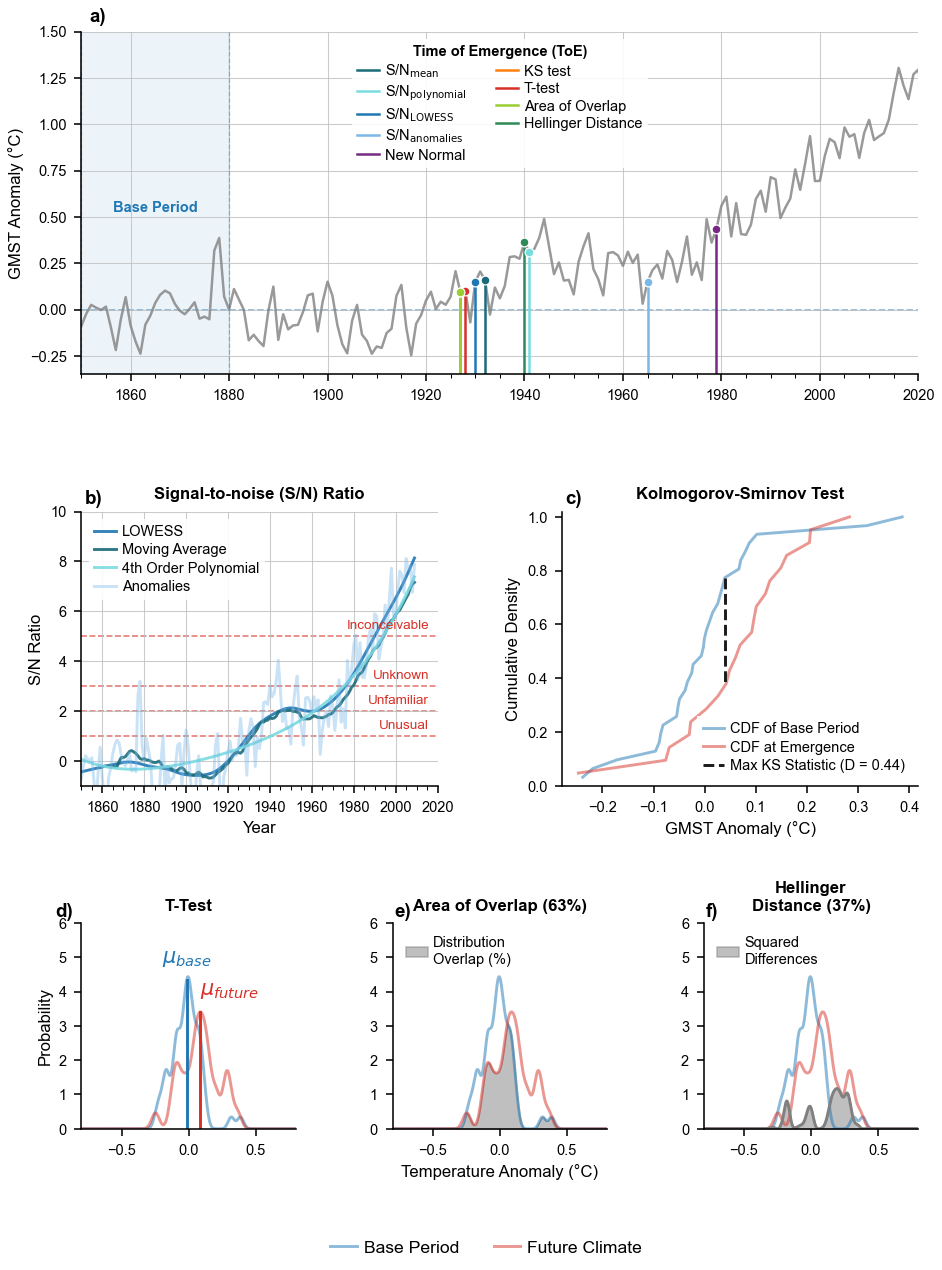

In [115]:
# ═══════════════════════════════════════════════════════════════════════════
# fig_02 — ToE method schematic (restyled to match ensemble emergence fig)
# ═══════════════════════════════════════════════════════════════════════════

# ── 0. Apply journal style ────────────────────────────────────────────────
apply_nature_rcparams()

# ── 1. Build figure / axes ────────────────────────────────────────────────
fig = plt.figure(figsize=(7.2, 9.5))
gs  = gridspec.GridSpec(3, 2, height_ratios=[1, 0.8, 0.6], hspace=0.50,
                        wspace=0.35)
ax_gmst = fig.add_subplot(gs[0, :])
ax_sn   = fig.add_subplot(gs[1, 0])
ax_ks   = fig.add_subplot(gs[1, 1])
subgrid = gs[2, :].subgridspec(1, 3, wspace=0.45)
ax_tt, ax_ov, ax_hd = [fig.add_subplot(subgrid[i]) for i in range(3)]

# ── 3. Draw panels ───────────────────────────────────────────────────────
plot_gmst_and_toe(
    ax_gmst, smean_anom_ds,#.median(dim='member'), 
    toe_df.loc[main_metrics], #toe_labels,
    base_period_tuple,
    # smean_anom_ens=smean_anom_ds, ensemble_dim='member',
    # toe_colors=toe_colors,
)
plot_sn_ratio(
    ax_sn, toe_metrics_ds[main_metrics].isel(member_kwargs), smean_anom_ds.isel(member_kwargs),
    line_styles=toe_plots.TEST_STYLES,
    name_map=toe_plots.METRIC_NAME_MAP_SHORT,
    overlap_var='fga',
)
plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=int(toe_ds['ks'].isel(member_kwargs).values.item()),
)
plot_lower_panels(
    ax_tt, ax_ov, ax_hd,
    smean_anom_ds,
    emergence_year=int(toe_ds['frac'].isel(member_kwargs).values.item()),
    fractional_geometric_area_fn=toe.fractional_geometric_area,
)
add_lower_panels_legend(fig, ax_tt)

# ── 4. Bold panel labels ─────────────────────────────────────────────────
all_axes = [ax_gmst, ax_sn, ax_ks, ax_tt, ax_ov, ax_hd]
annotate_panel_letters(all_axes, xy_overrides={3: (-0.12, 1.03)})

for ax in [ax_gmst, ax_sn]:
    ax.set_xlim(1850, 2020)
ax_sn.set_ylim(-1, 10)

In [116]:
reload(toe_plots)

<module 'toe_plots' from '/home/563/ab2313/Documents/time_of_emergene_drafts/src/toe_plots.py'>

In [117]:
toe_colors

NameError: name 'toe_colors' is not defined

## Ensemble Plot

In [ ]:
"""
Ensemble Emergence Figure
Layout: 2 rows — (a)+(b) side-by-side, (c) full width with dual y-axes

Expects:
    smean_anom_ds    — global/spatial-mean anomalies, dims (member, time)
    signal_ds        — signal estimates with signal_type coord
    toe_metrics_ds   — ToE metrics including sn_lowess_base
    toe_ds           — permanent emergence years, including sn_lowess_base
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

# ── Global font sizes ────────────────────────────────────────────────────────
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14
LEGEND_SIZE = 13
ANNOT_SIZE = 14
PANEL_LABEL_SIZE = 22

# ── Colour palette (from project styles) ────────────────────────────────────
c_member      = '#a8c8e8'       # pale blue — spaghetti
c_member_line = '#5b9bd5'       # mid blue — individual signal/SN lines
c_plume_outer = '#c6dbef'       # very pale blue — 10-90 fill
c_plume_inner = '#6baed6'       # stronger blue — 25-75 fill
c_median      = '#1a1a1a'       # near-black — ensemble median
c_accent      = '#d73027'       # red (ttest palette) — threshold, 50% marker
c_base        = '#2ca02c'       # green — base period
c_first       = '#d73027'       # red — first to emerge
c_last        = '#762A83'       # purple (sn_ens_med palette) — last to emerge
c_emerged     = '#999999'       # grey — % emerged curve (background)

# ── Load your data ───────────────────────────────────────────────────────────

members   = smean_anom_ds.values                        # (member, time)
signals   = signal_ds.sel(signal_type='lowess').values       # (member, time)
sn_ratios = toe_metrics_ds.sn_lowess_base.values             # (member, time)
years     = smean_anom_ds.time.dt.year.values
years_sn     = toe_metrics_ds.time.dt.year.values

n_members = members.shape[0]

base_start, base_end = 1880, 1910
base_mask = (years >= base_start) & (years <= base_end)

ensemble_median_signal = np.median(signals, axis=0)
ensemble_median_sn     = np.median(sn_ratios, axis=0)

# ── Emergence years from pre-computed dataset ────────────────────────────────
threshold = 1.0
toe_members = toe_ds.sn_lowess_base.values                   # (member,)

toe_quantiles = toe_ds.sn_lowess_base.quantile([0.1, 0.25, 0.5, 0.75, 0.9], dim='member')
toe_10 = float(toe_quantiles.sel(quantile=0.1))
toe_25 = float(toe_quantiles.sel(quantile=0.25))
toe_50 = float(toe_quantiles.sel(quantile=0.5))
toe_75 = float(toe_quantiles.sel(quantile=0.75))
toe_90 = float(toe_quantiles.sel(quantile=0.9))

frac_emerged = np.zeros(len(years))
for j, yr in enumerate(years):
    frac_emerged[j] = np.nanmean(toe_members <= yr)

# ── Identify first / last emerging members ───────────────────────────────────
valid_toe = np.where(np.isnan(toe_members), np.inf, toe_members)
idx_first = np.argmin(valid_toe)
valid_toe_last = np.where(np.isnan(toe_members), -np.inf, toe_members)
idx_last  = np.argmax(valid_toe_last)

# ── Axis limits ──────────────────────────────────────────────────────────────
xlim = (1880, 2025)

# ── Helper functions ─────────────────────────────────────────────────────────
def shade_base(ax):
    ax.axvspan(base_start, base_end, color=c_base, alpha=0.08, zorder=0)
    ax.axvline(base_start, color=c_base, lw=0.6, ls='--', alpha=0.4)
    ax.axvline(base_end, color=c_base, lw=0.6, ls='--', alpha=0.4)

def clean_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.1],
                       hspace=0.30, wspace=0.25,
                       left=0.07, right=0.93, top=0.96, bottom=0.06)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])
ax_c2 = ax_c.twinx()

all_axes = [ax_a, ax_b, ax_c]
panel_labels = ['a', 'b', 'c']

# ═══════════════════════════════════════════════════════════════════════════════
# (a) Raw anomalies — spaghetti
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_a
for i in range(n_members):
    ax.plot(years, members[i], color=c_member, lw=0.5, alpha=0.7)
ax.plot(years, np.median(members, axis=0), color=c_median, lw=2.0,
        label='Ensemble median', zorder=3)
# Highlight first and last to emerge
ax.plot(years, members[idx_first], color=c_first, lw=1.5, alpha=0.9, zorder=4,
        label=f'First to emerge (member {idx_first + 1})')
ax.plot(years, members[idx_last], color=c_last, lw=1.5, alpha=0.9, zorder=4,
        label=f'Last to emerge (member {idx_last + 1})')
# Mark their ToE with a dot
toe_yr_first = int(toe_members[idx_first])
toe_yr_last  = int(toe_members[idx_last])
ax.plot(toe_yr_first, members[idx_first][years == toe_yr_first][0],
        'o', color=c_first, markersize=9, zorder=5,
        markeredgecolor='white', markeredgewidth=1.5)
ax.plot(toe_yr_last, members[idx_last][years == toe_yr_last][0],
        'o', color=c_last, markersize=9, zorder=5,
        markeredgecolor='white', markeredgewidth=1.5)
shade_base(ax)
clean_spines(ax)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=LABEL_SIZE)
ax.set_title('Raw Ensemble Members', fontsize=TITLE_SIZE, fontweight='bold',
             loc='left', pad=12)
ax.legend(loc='upper left', fontsize=LEGEND_SIZE - 1, framealpha=0.9,
          edgecolor='none', fancybox=False)
ax.set_xlim(*xlim)
ax.set_ylim(-.5, 2.5)

# ═══════════════════════════════════════════════════════════════════════════════
# (b) Signal estimates — plume + ensemble median
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_b
sig_lo = np.percentile(signals, 10, axis=0)
sig_hi = np.percentile(signals, 90, axis=0)
sig_25 = np.percentile(signals, 25, axis=0)
sig_75 = np.percentile(signals, 75, axis=0)
ax.fill_between(years, sig_lo, sig_hi, color=c_plume_outer, alpha=0.4,
                label='10–90th pctl', edgecolor='none')
ax.fill_between(years, sig_25, sig_75, color=c_plume_inner, alpha=0.35,
                label='25–75th pctl', edgecolor='none')
for i in range(0, n_members, max(1, n_members // 6)):
    ax.plot(years, signals[i], color=c_member_line, lw=0.5, alpha=0.6)
ax.plot(years, ensemble_median_signal, color=c_median, lw=2.2, zorder=3,
        label='Ensemble-median signal')
shade_base(ax)
clean_spines(ax)
ax.set_ylabel('Signal Estimate (°C)', fontsize=LABEL_SIZE)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_title('Signal Estimates (LOWESS)', fontsize=TITLE_SIZE,
             fontweight='bold', loc='left', pad=12)
ax.legend(loc='upper left', fontsize=LEGEND_SIZE - 1, framealpha=0.9,
          edgecolor='none', fancybox=False)
ax.set_xlim(*xlim)
ax.set_ylim(-.5, 2.5)

# ═══════════════════════════════════════════════════════════════════════════════
# (c) S/N ratio plume (left axis) + fraction emerged (right axis)
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_c

# ── Right axis FIRST (so it draws behind) ────────────────────────────────────
ax2 = ax_c2
ax2.plot(years, frac_emerged * 100, color=c_emerged, lw=2.0, alpha=0.5,
         zorder=1, label='Members emerged (%)')
ax2.set_ylabel('Members Emerged (%)', fontsize=LABEL_SIZE, color=c_emerged)
ax2.set_ylim(-2, 100)
ax2.tick_params(axis='y', labelsize=TICK_SIZE, colors=c_emerged)
ax2.spines['right'].set_color(c_emerged)
ax2.spines['top'].set_visible(False)

# ── Left axis: S/N plume ─────────────────────────────────────────────────────
sn_lo = np.percentile(sn_ratios, 10, axis=0)
sn_hi = np.percentile(sn_ratios, 90, axis=0)
sn_25 = np.percentile(sn_ratios, 25, axis=0)
sn_75 = np.percentile(sn_ratios, 75, axis=0)
ax.fill_between(years_sn, sn_lo, sn_hi, color=c_plume_outer, alpha=0.4,
                label='S/N 10–90th pctl', edgecolor='none', zorder=2)
ax.fill_between(years_sn, sn_25, sn_75, color=c_plume_inner, alpha=0.35,
                label='S/N 25–75th pctl', edgecolor='none', zorder=2)
for i in range(0, n_members, max(1, n_members // 6)):
    ax.plot(years_sn, sn_ratios[i], color=c_member_line, lw=0.5, alpha=0.6, zorder=2)
ax.plot(years_sn, ensemble_median_sn, color=c_median, lw=2.2, zorder=3,
        label='Ensemble-median S/N')

ax.axhline(threshold, color=c_accent, ls='--', lw=1.8, alpha=0.7, zorder=3,
           label=f'Threshold (S/N = {threshold})')

# 50% emergence marker
if not np.isnan(toe_50):
    idx_50 = np.searchsorted(years, int(toe_50))
    ax.plot(toe_50, ensemble_median_sn[idx_50], 'o', color=c_accent,
            markersize=13, zorder=6, markeredgecolor='white', markeredgewidth=2)
    ax.annotate(f'50% emerged\n({int(toe_50)})',
                xy=(toe_50, ensemble_median_sn[idx_50]),
                xytext=(toe_50 + 12, ensemble_median_sn[idx_50] + 0.8),
                fontsize=ANNOT_SIZE, color=c_accent, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=c_accent, lw=1.5),
                zorder=7)

    # ToE uncertainty bar on threshold
    ax.plot([toe_10, toe_90], [threshold, threshold], color=c_accent,
            lw=5, alpha=0.35, solid_capstyle='round', zorder=4)
    ax.plot([toe_25, toe_75], [threshold, threshold], color=c_accent,
            lw=7, alpha=0.55, solid_capstyle='round', zorder=4)
    for pct_yr in [toe_10, toe_90]:
        ax.plot(pct_yr, threshold, '|', color=c_accent, markersize=16,
                markeredgewidth=2.5, zorder=5)

# First / last annotations — axis coordinates
toe_first = float(np.nanmin(toe_members))
toe_last  = float(np.nanmax(toe_members[~np.isnan(toe_members)]))
ax.annotate(f'First: {int(toe_first)}',
            xy=(toe_first, threshold), xycoords='data',
            xytext=(0.02, 0.08), textcoords='axes fraction',
            fontsize=ANNOT_SIZE, color=c_first, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=c_first, lw=1.2),
            zorder=7)
ax.annotate(f'Last: {int(toe_last)}',
            xy=(toe_last, threshold), xycoords='data',
            xytext=(0.85, 0.85), textcoords='axes fraction',
            fontsize=ANNOT_SIZE, color=c_last, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=c_last, lw=1.2),
            zorder=7)

shade_base(ax)
ax.spines['top'].set_visible(False)
ax.set_ylabel('S/N Ratio', fontsize=LABEL_SIZE)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_title('Signal-to-Noise Ratio & Ensemble Emergence', fontsize=TITLE_SIZE,
             fontweight='bold', loc='left', pad=12)
ax.set_xlim(*xlim)
ax.set_ylim(-1, 10)
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)  # make left axis background transparent so right shows

# ── Combined legend ──────────────────────────────────────────────────────────
lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax2.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right,
          loc='upper left', fontsize=LEGEND_SIZE - 1, framealpha=0.9,
          edgecolor='none', fancybox=False, ncol=2)

# ── Panel labels & tick sizes ────────────────────────────────────────────────
for i, a in enumerate(all_axes):
    a.text(-0.06, 1.05, f'{panel_labels[i]})', transform=a.transAxes,
           fontsize=PANEL_LABEL_SIZE, fontweight='bold', va='top')
    a.tick_params(labelsize=TICK_SIZE, direction='out', length=5)

plt.show()

# Old 

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Updates to toe_schematic_plots.py
#
# 1. Add _shade_base_period() to the "Small shared helpers" section
# 2. Replace plot_gmst_and_toe() with the version below
#
# Everything else (plot_sn_ratio, plot_ks_test, lower panels, etc.)
# stays unchanged — they already use _style() and _format_timeseries_ax()
# so they're consistent.
# ═══════════════════════════════════════════════════════════════════════════


# ---------------------------------------------------------------------------
# ADD to "Small shared helpers" section (after _format_timeseries_ax)
# ---------------------------------------------------------------------------

def _shade_base_period(
    ax: Axes,
    base_period: Tuple[int, int],
    *,
    style: Optional[Dict] = None,
) -> None:
    """Tinted base-period band with dashed boundaries.

    Matches the ensemble emergence figure style — a subtle coloured span
    rather than a drawn box, so both figures look like they belong together.
    """
    color = _style(style, "base_color")
    ax.axvspan(base_period[0], base_period[1],
               color=color, alpha=0.08, zorder=0)
    ax.axvline(base_period[0], color=color, lw=0.6, ls="--", alpha=0.4)
    ax.axvline(base_period[1], color=color, lw=0.6, ls="--", alpha=0.4)


# ---------------------------------------------------------------------------
# REPLACE plot_gmst_and_toe entirely
# ---------------------------------------------------------------------------

def plot_gmst_and_toe(
    ax: Axes,
    smean_anom: xr.DataArray,
    toe_labels: Dict[int, str],
    base_period: Tuple[int, int],
    *,
    smean_anom_ens: Optional[xr.DataArray] = None,
    ensemble_dim: str = "ensemble",
    colors: Optional[List] = None,
    toe_colors: Optional[Dict[str, str]] = None,
    style: Optional[Dict] = None,
) -> None:
    """Draw GMST anomaly time-series and ToE vertical markers onto *ax*.

    Parameters
    ----------
    ax            : target Axes
    smean_anom    : 1-D DataArray (ensemble median / single run)
    toe_labels    : {year: label_string} for each emergence method
    base_period   : (start_year, end_year)
    smean_anom_ens: optional ensemble DataArray; individual members drawn faintly
    ensemble_dim  : name of the ensemble dimension in *smean_anom_ens*
    colors        : positional colour cycle (falls back to tab10)
    toe_colors    : {label_string: color} per-method colour override
    style         : style-override dict (see DEFAULT_STYLE)
    """
    if colors is None:
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if toe_colors is None:
        toe_colors = {}

    time = smean_anom.time.dt.year.values
    arr  = smean_anom.values

    # --- ensemble members (faint) ---
    if smean_anom_ens is not None:
        if ensemble_dim in smean_anom_ens.dims and smean_anom_ens.sizes.get(ensemble_dim, 1) > 1:
            for member_i in range(smean_anom_ens.sizes[ensemble_dim]):
                ax.plot(
                    time,
                    smean_anom_ens.isel({ensemble_dim: member_i}).values,
                    color=_style(style, "ensemble_color"),
                    alpha=_style(style, "ensemble_alpha"),
                    linewidth=0.4,
                )

    # --- median ---
    ax.plot(time, arr,
            linewidth=_style(style, "linewidth"),
            color="black", label="Ensemble median", zorder=3)

    # --- zero reference line (dashed, extends full range) ---
    ax.axhline(0, color=_style(style, "base_color"), linestyle="--",
               linewidth=_style(style, "base_period_lw") * 0.6, alpha=0.5, zorder=1)

    # --- base-period shading (matching ensemble emergence figure) ---
    _shade_base_period(ax, base_period, style=style)

    # "Base Period" label sits just above the shaded band
    ax.annotate(
        "Base Period",
        xy=(np.mean(base_period), 0.53),
        fontsize=_style(style, "other_text"),
        ha="center", color=_style(style, "base_color"), fontweight="bold",
    )

    # --- ToE vertical markers ---
    main_metrics = {"PSS", "KS", "Mean", "ens"}
    for i, (year, label) in enumerate(toe_labels.items()):
        colour = toe_colors.get(label, colors[i % len(colors)])
        prominent = any(mm in label for mm in main_metrics)
        line_kw = dict(
            linestyle="-",
            alpha=1.0 if prominent else 0.5,
            linewidth=_style(style, "linewidth") + 0.3,
        )
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.35, yval], color=colour, label=label, **line_kw)
        ax.scatter([year], [yval], color=colour,
                   s=_style(style, "marker_size"), zorder=100)

    # --- legend ---
    leg = ax.legend(
        fontsize=_style(style, "legend_elements"),
        labelspacing=0.25, handletextpad=0.4,
        loc="upper left", ncol=2,
    )
    leg.set_title("Method", prop={"size": _style(style, "legend_elements"),
                                   "weight": "bold"})

    ax.set_ylabel("GMST Anomaly (°C)", fontsize=_style(style, "labels"))
    ax.set_ylim(-0.35, 1.5)
    _format_timeseries_ax(ax, show_xlabel=False, style=style)
    _change_tick_size(ax, _style(style, "tick_size"))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# fig_02 — ToE method schematic (restyled to match ensemble emergence fig)
# ═══════════════════════════════════════════════════════════════════════════

# ── 0. Apply journal style ────────────────────────────────────────────────
apply_nature_rcparams()

# ── 1. Build figure / axes ────────────────────────────────────────────────
fig = plt.figure(figsize=(7.2, 9.5))
gs  = gridspec.GridSpec(3, 2, height_ratios=[1, 0.8, 0.6], hspace=0.50,
                        wspace=0.35)
ax_gmst = fig.add_subplot(gs[0, :])
ax_sn   = fig.add_subplot(gs[1, 0])
ax_ks   = fig.add_subplot(gs[1, 1])
subgrid = gs[2, :].subgridspec(1, 3, wspace=0.45)
ax_tt, ax_ov, ax_hd = [fig.add_subplot(subgrid[i]) for i in range(3)]

# ── 2. Build cross-panel colour map from TEST_STYLES ─────────────────────
toe_colors = {
    toe_plots.METRIC_NAME_MAP_SHORT.get(k, k): toe_plots.TEST_STYLES[k]["color"]
    for k in toe_plots.TEST_STYLES
}

# ── 3. Draw panels ───────────────────────────────────────────────────────
plot_gmst_and_toe(
    ax_gmst, smean_anom_ds.median(dim='member'), toe_labels, base_period_tuple,
    smean_anom_ens=smean_anom_ds, ensemble_dim='member',
    toe_colors=toe_colors,
)
plot_sn_ratio(
    ax_sn, toe_metrics_ds.isel(member_kwargs), smean_anom_ds.isel(member_kwargs),
    line_styles=toe_plots.TEST_STYLES,
    name_map=toe_plots.METRIC_NAME_MAP_SHORT,
    overlap_var='fga',
)
plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=int(toe_ds['ks'].isel(member_kwargs).values.item()),
)
plot_lower_panels(
    ax_tt, ax_ov, ax_hd,
    smean_anom_ds,
    emergence_year=int(toe_ds['frac'].isel(member_kwargs).values.item()),
    fractional_geometric_area_fn=toe.fractional_geometric_area,
)
add_lower_panels_legend(fig, ax_tt)

# ── 4. Bold panel labels ─────────────────────────────────────────────────
all_axes = [ax_gmst, ax_sn, ax_ks, ax_tt, ax_ov, ax_hd]
annotate_panel_letters(all_axes, xy_overrides={3: (-0.12, 1.03)})

for ax in [ax_gmst, ax_sn]:
    ax.set_xlim(1850, 2020)
ax_sn.set_ylim(-1, 10)

In [ ]:
# fig, gs, axes = toe_plots.plot_multiseries_with_pvalues(
#     toe_metrics_ds.isel(member_kwargs),
#     toe_ds.isel(member_kwargs),
#     smean_anom_ds.isel(member_kwargs),
#     labels={'ylabel_bottom': 'GMST Anomaly (K)'},
#     return_figure=True,
# )

In [ ]:
# Add ToE vertical markers in matching method colors
for emergence_test in list(toe_ds.data_vars):
    if emergence_test not in toe_plots.TEST_PLOT_DICT:
        continue

    toe_year = toe_ds[emergence_test].isel(member_kwargs).values.item()
    if np.isnan(toe_year):
        continue

    year_mask = toe_metrics_ds.time.dt.year.values == int(toe_year)
    if not np.any(year_mask):
        continue

    xval_emergence = toe_metrics_ds.time.values[year_mask].item()
    axes[0].axvline(
        xval_emergence,
        color=toe_plots.TEST_PLOT_DICT[emergence_test]['color'],
        linewidth=3,
    )


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# Updates to toe_schematic_plots.py
#
# 1. Add _shade_base_period() to the "Small shared helpers" section
# 2. Replace plot_gmst_and_toe() with the version below
#
# Everything else (plot_sn_ratio, plot_ks_test, lower panels, etc.)
# stays unchanged — they already use _style() and _format_timeseries_ax()
# so they're consistent.
# ═══════════════════════════════════════════════════════════════════════════


# ---------------------------------------------------------------------------
# ADD to "Small shared helpers" section (after _format_timeseries_ax)
# ---------------------------------------------------------------------------

def _shade_base_period(
    ax: Axes,
    base_period: Tuple[int, int],
    *,
    style: Optional[Dict] = None,
) -> None:
    """Tinted base-period band with dashed boundaries.

    Matches the ensemble emergence figure style — a subtle coloured span
    rather than a drawn box, so both figures look like they belong together.
    """
    color = _style(style, "base_color")
    ax.axvspan(base_period[0], base_period[1],
               color=color, alpha=0.08, zorder=0)
    ax.axvline(base_period[0], color=color, lw=0.6, ls="--", alpha=0.4)
    ax.axvline(base_period[1], color=color, lw=0.6, ls="--", alpha=0.4)


# ---------------------------------------------------------------------------
# REPLACE plot_gmst_and_toe entirely
# ---------------------------------------------------------------------------

def plot_gmst_and_toe(
    ax: Axes,
    smean_anom: xr.DataArray,
    toe_labels: Dict[int, str],
    base_period: Tuple[int, int],
    *,
    smean_anom_ens: Optional[xr.DataArray] = None,
    ensemble_dim: str = "ensemble",
    colors: Optional[List] = None,
    toe_colors: Optional[Dict[str, str]] = None,
    style: Optional[Dict] = None,
) -> None:
    """Draw GMST anomaly time-series and ToE vertical markers onto *ax*.

    Parameters
    ----------
    ax            : target Axes
    smean_anom    : 1-D DataArray (ensemble median / single run)
    toe_labels    : {year: label_string} for each emergence method
    base_period   : (start_year, end_year)
    smean_anom_ens: optional ensemble DataArray; individual members drawn faintly
    ensemble_dim  : name of the ensemble dimension in *smean_anom_ens*
    colors        : positional colour cycle (falls back to tab10)
    toe_colors    : {label_string: color} per-method colour override
    style         : style-override dict (see DEFAULT_STYLE)
    """
    if colors is None:
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if toe_colors is None:
        toe_colors = {}

    time = smean_anom.time.dt.year.values
    arr  = smean_anom.values

    # --- ensemble members (faint) ---
    if smean_anom_ens is not None:
        if ensemble_dim in smean_anom_ens.dims and smean_anom_ens.sizes.get(ensemble_dim, 1) > 1:
            for member_i in range(smean_anom_ens.sizes[ensemble_dim]):
                ax.plot(
                    time,
                    smean_anom_ens.isel({ensemble_dim: member_i}).values,
                    color=_style(style, "ensemble_color"),
                    alpha=_style(style, "ensemble_alpha"),
                    linewidth=0.4,
                )

    # --- median ---
    ax.plot(time, arr,
            linewidth=_style(style, "linewidth"),
            color="black", label="Ensemble median", zorder=3)

    # --- zero reference line (dashed, extends full range) ---
    ax.axhline(0, color=_style(style, "base_color"), linestyle="--",
               linewidth=_style(style, "base_period_lw") * 0.6, alpha=0.5, zorder=1)

    # --- base-period shading (matching ensemble emergence figure) ---
    _shade_base_period(ax, base_period, style=style)

    # "Base Period" label sits just above the shaded band
    ax.annotate(
        "Base Period",
        xy=(np.mean(base_period), 0.53),
        fontsize=_style(style, "other_text"),
        ha="center", color=_style(style, "base_color"), fontweight="bold",
    )

    # --- ToE vertical markers ---
    main_metrics = {"PSS", "KS", "Mean", "ens"}
    for i, (year, label) in enumerate(toe_labels.items()):
        colour = toe_colors.get(label, colors[i % len(colors)])
        prominent = any(mm in label for mm in main_metrics)
        line_kw = dict(
            linestyle="-",
            alpha=1.0 if prominent else 0.5,
            linewidth=_style(style, "linewidth") + 0.3,
        )
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.35, yval], color=colour, label=label, **line_kw)
        ax.scatter([year], [yval], color=colour,
                   s=_style(style, "marker_size"), zorder=100)

    # --- legend ---
    leg = ax.legend(
        fontsize=_style(style, "legend_elements"),
        labelspacing=0.25, handletextpad=0.4,
        loc="upper left", ncol=2,
    )
    leg.set_title("Method", prop={"size": _style(style, "legend_elements"),
                                   "weight": "bold"})

    ax.set_ylabel("GMST Anomaly (°C)", fontsize=_style(style, "labels"))
    ax.set_ylim(-0.35, 1.5)
    _format_timeseries_ax(ax, show_xlabel=False, style=style)
    _change_tick_size(ax, _style(style, "tick_size"))

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# fig_02 — ToE method schematic (restyled to match ensemble emergence fig)
# ═══════════════════════════════════════════════════════════════════════════

# ── 0. Apply journal style ────────────────────────────────────────────────
apply_nature_rcparams()

# ── 1. Build figure / axes ────────────────────────────────────────────────
fig = plt.figure(figsize=(7.2, 9.5))
gs  = gridspec.GridSpec(3, 2, height_ratios=[1, 0.8, 0.6], hspace=0.50,
                        wspace=0.35)
ax_gmst = fig.add_subplot(gs[0, :])
ax_sn   = fig.add_subplot(gs[1, 0])
ax_ks   = fig.add_subplot(gs[1, 1])
subgrid = gs[2, :].subgridspec(1, 3, wspace=0.45)
ax_tt, ax_ov, ax_hd = [fig.add_subplot(subgrid[i]) for i in range(3)]

# ── 2. Build cross-panel colour map from TEST_STYLES ─────────────────────
toe_colors = {
    toe_plots.METRIC_NAME_MAP_SHORT.get(k, k): toe_plots.TEST_STYLES[k]["color"]
    for k in toe_plots.TEST_STYLES
}

# ── 3. Draw panels ───────────────────────────────────────────────────────
plot_gmst_and_toe(
    ax_gmst, smean_anom_ds.median(dim='member'), toe_labels, base_period_tuple,
    smean_anom_ens=smean_anom_ds, ensemble_dim='member',
    toe_colors=toe_colors,
)
plot_sn_ratio(
    ax_sn, toe_metrics_ds.isel(member_kwargs), smean_anom_ds.isel(member_kwargs),
    line_styles=toe_plots.TEST_STYLES,
    name_map=toe_plots.METRIC_NAME_MAP_SHORT,
    overlap_var='fga',
)
plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=int(toe_ds['ks'].isel(member_kwargs).values.item()),
)
plot_lower_panels(
    ax_tt, ax_ov, ax_hd,
    smean_anom_ds,
    emergence_year=int(toe_ds['frac'].isel(member_kwargs).values.item()),
    fractional_geometric_area_fn=toe.fractional_geometric_area,
)
add_lower_panels_legend(fig, ax_tt)

# ── 4. Bold panel labels ─────────────────────────────────────────────────
all_axes = [ax_gmst, ax_sn, ax_ks, ax_tt, ax_ov, ax_hd]
annotate_panel_letters(all_axes, xy_overrides={3: (-0.12, 1.03)})

for ax in [ax_gmst, ax_sn]:
    ax.set_xlim(1850, 2020)
ax_sn.set_ylim(-1, 10)

fig.savefig('fig_02.png')

In [ ]:
"""
Modular plotting functions for Time of Emergence (ToE) schematic figures.

Each function has a single responsibility:
  - setup_*  : creates figure/axes
  - plot_*   : draws onto a provided Axes
  - figure_* : convenience wrappers that call setup + plot together

All data and style parameters are passed explicitly; there are no global dependencies.
"""



# ---------------------------------------------------------------------------
# Nature Reviews Earth & Environment – publication style
# ---------------------------------------------------------------------------
# Journal spec:  max figure width 183 mm (double col) / 89 mm (single col)
#                font: Arial / Helvetica, min 5 pt, body 7–8 pt
#                panel labels: bold, 9 pt
#                line weight: 0.75–1.5 pt
# ---------------------------------------------------------------------------

def apply_nature_rcparams() -> None:
    """Set matplotlib rcParams for Nature Reviews Earth & Environment style.

    Call this once before creating any figure::

        apply_nature_rcparams()
        fig = plt.figure(figsize=(7.2, 9))
        ...

    The function is non-destructive – you can restore defaults afterwards with
    ``plt.rcdefaults()``.
    """
    plt.rcParams.update({
        # --- Font ---
        "font.family":           "sans-serif",
        "font.sans-serif":       ["Arial", "Helvetica Neue", "Helvetica",
                                   "Liberation Sans", "DejaVu Sans"],
        "font.size":             7,
        # Use 'dejavusans' mathtext so Greek letters (μ, etc.) render in
        # a sans-serif face without falling back to Computer Modern.
        # Avoid using \circ in labels – use the Unicode ° character instead.
        "mathtext.fontset":      "dejavusans",

        # --- Axes ---
        "axes.spines.top":       False,
        "axes.spines.right":     False,
        "axes.linewidth":        0.75,
        "axes.labelsize":        8,
        "axes.titlesize":        8,
        "axes.titleweight":      "normal",
        "axes.labelpad":         3,

        # --- Ticks ---
        "xtick.labelsize":       7,
        "ytick.labelsize":       7,
        "xtick.major.width":     0.75,
        "ytick.major.width":     0.75,
        "xtick.minor.width":     0.5,
        "ytick.minor.width":     0.5,
        "xtick.major.size":      3.5,
        "ytick.major.size":      3.5,
        "xtick.minor.size":      2.0,
        "ytick.minor.size":      2.0,
        "xtick.direction":       "out",
        "ytick.direction":       "out",

        # --- Legend ---
        "legend.fontsize":       7,
        "legend.frameon":        True,
        "legend.framealpha":     0.85,
        "legend.edgecolor":      "0.8",
        "legend.borderpad":      0.4,
        "legend.labelspacing":   0.3,
        "legend.handlelength":   1.5,
        "legend.handletextpad":  0.4,

        # --- Lines ---
        "lines.linewidth":       1.2,
        "lines.markersize":      3.5,

        # --- Grid ---
        "grid.linewidth":        0.5,
        "grid.alpha":            0.35,
        "grid.linestyle":        "--",
        "grid.color":            "0.75",

        # --- Figure ---
        "figure.dpi":            150,
        "savefig.dpi":           300,
        "savefig.bbox":          "tight",
        "savefig.pad_inches":    0.05,

        # --- Patches ---
        "patch.linewidth":       0.75,
    })


# ---------------------------------------------------------------------------
# Default style dictionary – values here are used as fallbacks inside each
# plotting function.  Most sizing is handled by apply_nature_rcparams();
# this dict carries the semantic / colour choices specific to this figure.
# ---------------------------------------------------------------------------

DEFAULT_STYLE: Dict = {
    # Colours
    "base_color":         "#2196A6",   # professional teal – colorblind-safe
    "future_color":       "#C0392B",   # deep red – colorblind-safe
    "ensemble_color":     "#888888",   # member lines
    "ensemble_alpha":     0.07,

    # Typography  (pt)  – sized for a 183 mm wide main figure
    "title_fontsize":     8,
    "labels":             8,
    "other_text":         7,
    "legend_elements":    7,
    "tick_size":          7,
    "panel_letter_size":  9,           # bold panel letters a) b) …

    # Lines
    "linewidth":          1.4,
    "base_period_lw":     1.5,         # base-period box / zero line
    "marker_size":        18,          # ToE scatter markers (s=)

    # S/N overlap twin-axis
    "overlap_color":      "#27AE60",   # green, distinct from teal/red
    "overlap_alpha":      0.20,

    # Grid (used when overriding rcParams is not desirable)
    "grid_alpha":         0.35,
    "grid_linestyle":     "--",
}


# ---------------------------------------------------------------------------
# Small shared helpers
# ---------------------------------------------------------------------------

def _style(overrides: Optional[Dict], key: str):
    """Resolve a style key from overrides, falling back to DEFAULT_STYLE."""
    d = {**DEFAULT_STYLE, **(overrides or {})}
    return d[key]


def _change_tick_size(ax: Axes, tick_size: int = 8) -> None:
    ax.tick_params(axis="both", labelsize=tick_size)


def _format_timeseries_ax(
    ax: Axes,
    *,
    show_xlabel: bool = True,
    style: Optional[Dict] = None,
) -> None:
    """Light formatting shared by time-series axes."""
    ax.grid(
        True,
        linestyle=_style(style, "grid_linestyle"),
        alpha=_style(style, "grid_alpha"),
    )
    if show_xlabel:
        ax.set_xlabel("Year", fontsize=_style(style, "labels"))


# ---------------------------------------------------------------------------
# 1.  GMST + Time-of-Emergence panel
# ---------------------------------------------------------------------------

def plot_gmst_and_toe(
    ax: Axes,
    smean_anom: xr.DataArray,
    toe_labels: Dict[int, str],
    base_period: Tuple[int, int],
    *,
    smean_anom_ens: Optional[xr.DataArray] = None,
    ensemble_dim: str = "ensemble",
    colors: Optional[List] = None,
    toe_colors: Optional[Dict[str, str]] = None,
    style: Optional[Dict] = None,
) -> None:
    """Draw GMST anomaly time-series and ToE vertical markers onto *ax*.

    Parameters
    ----------
    ax            : target Axes
    smean_anom    : 1-D DataArray with a 'time' coordinate (ensemble median / single run)
    toe_labels    : {year: label_string} mapping of emergence years to method names.
                   Each entry produces one vertical marker.  Split combined entries
                   such as ``"(KS, T-Test)"`` into separate year→label pairs to give
                   each method a distinct colour and line.
    base_period   : (start_year, end_year) of the reference period
    smean_anom_ens: optional ensemble DataArray; individual members drawn in grey
    ensemble_dim  : name of the ensemble dimension in *smean_anom_ens*
    colors        : positional colour cycle used when a label has no entry in
                   ``toe_colors`` (falls back to tab10)
    toe_colors    : {label_string: color} explicit per-method colour override, e.g.
                   built from ``toe_plots.TEST_STYLES`` so that S/N method markers
                   in this panel share colours with the S/N panel (b).
                   Example::

                       toe_colors = {
                           name_map[k]: toe_plots.TEST_STYLES[k]['color']
                           for k in toe_plots.TEST_STYLES
                       }
    style         : style-override dict (see DEFAULT_STYLE)
    """
    if colors is None:
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if toe_colors is None:
        toe_colors = {}

    time = smean_anom.time.dt.year.values
    arr = smean_anom.values

    # --- ensemble members (faint) ---
    if smean_anom_ens is not None:
        if ensemble_dim in smean_anom_ens.dims and smean_anom_ens.sizes.get(ensemble_dim, 1) > 1:
            for member_i in range(smean_anom_ens.sizes[ensemble_dim]):
                ax.plot(
                    time,
                    smean_anom_ens.isel({ensemble_dim: member_i}).values,
                    color=_style(style, "ensemble_color"),
                    alpha=_style(style, "ensemble_alpha"),
                    linewidth=0.5,
                )

    # --- median ---
    ax.plot(time, arr,
            linewidth=_style(style, "linewidth"),
            color="black", label="Ensemble median")

    # --- ToE vertical markers ---
    main_metrics = {"PSS", "KS", "Mean", "ens"}
    for i, (year, label) in enumerate(toe_labels.items()):
        colour = toe_colors.get(label, colors[i % len(colors)])
        prominent = any(mm in label for mm in main_metrics)
        line_kw = dict(
            linestyle="-",
            alpha=1.0 if prominent else 0.5,
            linewidth=_style(style, "linewidth") + 0.3,
        )
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.35, yval], color=colour, label=label, **line_kw)
        ax.scatter([year], [yval], color=colour,
                   s=_style(style, "marker_size"), zorder=100)

    # --- legend ---
    leg = ax.legend(
        fontsize=_style(style, "legend_elements"),
        labelspacing=0.25, handletextpad=0.4,
        loc="upper left", ncol=2,
    )
    leg.set_title("Method", prop={"size": _style(style, "legend_elements"),
                                   "weight": "bold"})

    # --- base-period box ---
    ylower = ax.get_ylim()[0]
    base_kw = dict(linewidth=_style(style, "base_period_lw"),
                   color=_style(style, "base_color"))
    end_year = int(smean_anom.time.dt.year.max())
    ax.plot([base_period[0], base_period[0]], [ylower, 0.5], **base_kw)
    ax.plot([base_period[1], base_period[1]], [ylower, 0.5], **base_kw)
    ax.plot([base_period[0], end_year],       [0, 0],        linestyle="--", **base_kw)
    ax.plot([base_period[0], base_period[1]], [ylower, ylower], **base_kw)
    ax.plot([base_period[0], base_period[1]], [0.5, 0.5],       **base_kw)
    ax.annotate(
        "Base Period",
        xy=(np.mean(base_period), 0.53),
        fontsize=_style(style, "other_text"),
        ha="center", color=_style(style, "base_color"), fontweight="bold",
    )

    ax.set_ylabel("GMST Anomaly (°C)", fontsize=_style(style, "labels"))
    ax.set_ylim(-0.35, 1.5)
    _format_timeseries_ax(ax, show_xlabel=False, style=style)
    _change_tick_size(ax, _style(style, "tick_size"))


# ---------------------------------------------------------------------------
# 2.  Signal-to-Noise panel
# ---------------------------------------------------------------------------

def plot_sn_ratio(
    ax: Axes,
    toe_metrics_ds: xr.Dataset,
    smean_anom: xr.DataArray,
    *,
    sn_var_names: Optional[List[str]] = None,
    line_styles: Optional[Dict] = None,
    name_map: Optional[Dict[str, str]] = None,
    overlap_da: Optional[xr.DataArray] = None,
    overlap_var: Optional[str] = None,
    log_scale: bool = False,
    style: Optional[Dict] = None,
) -> Tuple[Axes, Optional[Axes]]:
    """Draw Signal-to-Noise ratio curves onto *ax*, with optional overlap twin axis.

    Parameters
    ----------
    ax             : target Axes (left / S/N axis)
    toe_metrics_ds : Dataset containing S/N variables
    smean_anom     : used only to determine the earliest year for threshold annotations
    sn_var_names   : variable names to plot.  Resolution order:
                     1. explicit list passed here
                     2. ``sn_*`` keys of ``line_styles`` that exist in the dataset
                     3. all ``sn_*`` variables found in the dataset
    line_styles    : per-variable style dict, e.g. ``toe_plots.TEST_STYLES``
    name_map       : {raw_var_name: display_label}, e.g. ``toe_plots.METRIC_NAME_MAP_SHORT``
    overlap_da     : optional 1-D DataArray (time) of overlap percentages (0–100).
                     When provided, a twin right y-axis is created showing overlap %
                     inverted (0 % at top, 100 % at bottom) with a green fill, matching
                     the style of the reference figure.
    overlap_var    : if *overlap_da* is None, try to read this variable name from
                     ``toe_metrics_ds`` instead (e.g. ``'fga'``).
    log_scale      : use a log y-axis (default False)
    style          : figure-level style-override dict (see DEFAULT_STYLE)

    Returns
    -------
    ax       : the left S/N axes (same object passed in)
    ax_right : the right overlap axes, or None if no overlap data was provided
    """
    if line_styles is None:
        line_styles = {}
    if name_map is None:
        name_map = {}

    # --- resolve overlap DataArray ---
    if overlap_da is None and overlap_var is not None:
        if overlap_var in toe_metrics_ds.data_vars:
            overlap_da = toe_metrics_ds[overlap_var]

    # --- variable list resolution ---
    if sn_var_names is None:
        if line_styles:
            sn_var_names = [
                k for k in line_styles
                if k.startswith("sn_") and k in toe_metrics_ds.data_vars
            ]
        else:
            sn_var_names = [v for v in toe_metrics_ds.data_vars if v.startswith("sn_")]

    fallback_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # Space markers ~every N data points so lines don't look cluttered.
    # Offset each variable by one step so markers don't all land on the same year.
    marker_spacing = 20

    for i, sn_name in enumerate(sn_var_names):
        var_style = dict(line_styles.get(sn_name, {}))
        color     = var_style.pop("color",     fallback_colors[i % len(fallback_colors)])
        linestyle = var_style.pop("linestyle", "solid")
        marker    = var_style.pop("marker",    None)
        alpha     = var_style.pop("alpha",     0.35 if sn_name == "sn_anom" else 1.0)

        ax.plot(
            toe_metrics_ds.time.dt.year.values,
            toe_metrics_ds[sn_name].values,
            color=color,
            linestyle=linestyle,
            marker=marker,
            markevery=(i * (marker_spacing // max(len(sn_var_names), 1)),
                       marker_spacing) if marker else None,
            alpha=alpha,
            label=name_map.get(sn_name, sn_name),
            linewidth=_style(style, "linewidth"),
        )

    if log_scale:
        ax.set_yscale("log")

    _format_timeseries_ax(ax, style=style)

    # --- S/N threshold lines, annotated on the RIGHT spine to avoid crowding ---
    threshold_kw = dict(
        linestyle="--", color="#C0392B",
        linewidth=_style(style, "linewidth") * 0.55,
        alpha=0.65, zorder=0,
    )
    thresholds = [(1, "Unusual"), (2, "Unfamiliar"), (3, "Unknown"), (5, "Inconceivable")]
    xmax = ax.get_xlim()[1] if ax.get_xlim()[1] != 0.0 else 1.0
    for yval, label in thresholds:
        ax.axhline(yval, **threshold_kw)
        # Place label just inside the right edge, above the line
        ax.annotate(
            label,
            xy=(1.0, yval), xycoords=("axes fraction", "data"),
            xytext=(-4, 2), textcoords="offset points",
            ha="right", va="bottom",
            size=_style(style, "other_text") - 0.5,
            color="#C0392B",
            annotation_clip=False,
        )

    ax.set_ylabel("S/N Ratio", fontsize=_style(style, "labels"))
    ax.set_title("Signal-to-noise (S/N) Ratio", fontsize=_style(style, "title_fontsize"))
    ax.legend(fontsize=_style(style, "legend_elements"), loc="upper left", ncol=2)
    _change_tick_size(ax, _style(style, "tick_size"))

    # --- optional right axis: Overlap % (inverted, green) ---
    ax_right = None
    if overlap_da is not None:
        overlap_color = _style(style, "overlap_color")
        overlap_alpha = _style(style, "overlap_alpha")

        ax_right = ax.twinx()
        years_ov  = overlap_da.time.dt.year.values
        ov_vals   = overlap_da.values

        # Fill between overlap curve and 100 % (the fully-overlapping baseline)
        ax_right.fill_between(
            years_ov, ov_vals, 100,
            color=overlap_color, alpha=overlap_alpha, zorder=0,
        )
        ax_right.plot(
            years_ov, ov_vals,
            color=overlap_color,
            linewidth=_style(style, "linewidth"),
            label="Area of\nOverlap",
            zorder=1,
        )

        # Invert so 0 % is at top, 100 % at bottom (matches reference figure)
        ax_right.set_ylim(100, 0)
        ax_right.set_ylabel("Overlap  %", fontsize=_style(style, "labels"),
                             color=overlap_color)
        ax_right.tick_params(axis="y", labelcolor=overlap_color,
                              labelsize=_style(style, "tick_size"))

        # Add overlap handle to the main legend
        handles_l, labels_l = ax.get_legend_handles_labels()
        handles_r, labels_r = ax_right.get_legend_handles_labels()
        ax.legend(
            handles_l + handles_r,
            labels_l  + labels_r,
            fontsize=_style(style, "legend_elements"),
            loc="upper left",
        )

    return ax, ax_right


# ---------------------------------------------------------------------------
# 3.  KS-test panel
# ---------------------------------------------------------------------------

def plot_ks_test(
    ax: Axes,
    smean_anom: xr.DataArray,
    base_period: Tuple[int, int],
    emergence_year: int,
    *,
    emergence_window: int = 10,
    base_cdf_color: Optional[str] = None,
    emergence_cdf_color: Optional[str] = None,
    style: Optional[Dict] = None,
) -> None:
    """Draw KS-test CDFs and the max-statistic marker onto *ax*.

    Parameters
    ----------
    ax                   : target Axes
    smean_anom           : DataArray with 'time' coordinate
    base_period          : (start_year, end_year)
    emergence_year       : central year of the emergence window
    emergence_window     : half-width of the window in years (default 10)
    base_cdf_color       : colour for the base-period CDF line.  Defaults to
                           ``style['base_color']`` but can be set independently
                           from the KDE distribution panels so the two panels
                           don't look identical (e.g. pass a darker shade).
    emergence_cdf_color  : colour for the emergence CDF.  Defaults to
                           ``style['future_color']``.
    style                : style-override dict
    """
    base_color_resolved = base_cdf_color or _style(style, "base_color")
    emrg_color_resolved = emergence_cdf_color or _style(style, "future_color")

    base_array = smean_anom.sel(
        time=slice(str(base_period[0]), str(base_period[1]))
    ).values

    emergence_array = smean_anom.sel(
        time=slice(
            str(emergence_year - emergence_window),
            str(emergence_year + emergence_window),
        )
    ).values

    ecdf_base = ECDF(base_array)
    ecdf_emrg = ECDF(emergence_array)
    ks_result = ks_2samp(base_array, emergence_array)

    ax.plot(ecdf_base.x, ecdf_base.y,
            color=base_color_resolved,
            linewidth=_style(style, "linewidth"),
            label="CDF of Base Period")

    ax.plot(ecdf_emrg.x, ecdf_emrg.y,
            color=emrg_color_resolved,
            linewidth=_style(style, "linewidth"),
            label="CDF at Emergence")

    # --- max KS statistic marker ---
    max_x = ks_result.statistic_location
    max_y_base = ecdf_base(max_x)
    max_y_emrg = ecdf_emrg(max_x)

    ax.plot([max_x, max_x], [max_y_base, max_y_emrg + 0.05],
            color="k", linestyle="--", linewidth=1.5,
            label=f"Max KS Statistic (D = {ks_result.statistic:.2f})")
    ax.scatter([max_x], [max_y_base],
               color=base_color_resolved, s=50, zorder=1000)
    ax.scatter([max_x], [max_y_emrg + 0.05],
               color=emrg_color_resolved, s=50, zorder=1000)

    ax.set_ylabel("Cumulative Density", fontsize=_style(style, "labels"))
    ax.set_xlabel("GMST Anomaly (°C)", fontsize=_style(style, "labels"))
    ax.grid(True, linestyle=_style(style, "grid_linestyle"),
            color="grey", alpha=_style(style, "grid_alpha"))
    ax.set_ylim(0, 1.02)
    ax.set_title("Kolmogorov-Smirnov Test", fontsize=_style(style, "title_fontsize"))
    ax.legend(fontsize=_style(style, "legend_elements"))
    _change_tick_size(ax, _style(style, "tick_size"))


# ---------------------------------------------------------------------------
# 4.  Lower panels: T-test / Overlap / Hellinger – one function per panel
# ---------------------------------------------------------------------------

def _compute_kde_pair(
    base_arr: np.ndarray,
    future_arr: np.ndarray,
    fractional_geometric_area_fn,
    bmin: float = -0.6,
    bmax: float = 0.6,
    bw_method: float = 0.2,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    """Return (x_kde, kde_base, kde_future, overlap_pct)."""
    x_kde, kde_future, kde_base, fga_overlap = fractional_geometric_area_fn(
        base_arr, future_arr,
        return_all=True,
        method_kwargs=dict(bw_method=bw_method),
        bmin=bmin, bmax=bmax,
    )
    return x_kde, kde_base, kde_future, fga_overlap


def _draw_kde_curves(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    style: Optional[Dict],
    *,
    show_legend_labels: bool = True,
) -> None:
    """Draw base + future KDE curves shared across all three lower panels."""
    ax.plot(x_kde, kde_base,
            color=_style(style, "base_color"),
            linewidth=_style(style, "linewidth"), alpha=0.5,
            label="Base Period" if show_legend_labels else None)
    ax.plot(x_kde, kde_future,
            color=_style(style, "future_color"),
            linewidth=_style(style, "linewidth"), alpha=0.5,
            label="Future Climate" if show_legend_labels else None)


def plot_ttest_panel(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    base_arr: np.ndarray,
    future_arr: np.ndarray,
    *,
    style: Optional[Dict] = None,
    xlim: Tuple[float, float] = (-0.8, 0.8),
    ylim: Tuple[float, float] = (0, 6),
) -> None:
    """Panel 1 – mean markers (T-test visualisation).

    KDE curves are drawn with legend labels so that a downstream
    ``add_lower_panels_legend(fig, ...)`` call can collect them automatically.
    """
    _draw_kde_curves(ax, x_kde, kde_base, kde_future, style, show_legend_labels=True)

    mean_base   = float(np.mean(base_arr))
    mean_future = float(np.mean(future_arr))
    kde_at_base   = kde_base[np.argmin(np.abs(x_kde - mean_base))]
    kde_at_future = kde_future[np.argmin(np.abs(x_kde - mean_future))]

    ax.annotate(r"$\mu_{base}$",
                xy=(mean_base, kde_at_base + 0.5), ha="center",
                color=_style(style, "base_color"), size=20)
    ax.annotate(r"$\mu_{future}$",
                xy=(mean_future, kde_at_future + 0.5), ha="left",
                color=_style(style, "future_color"), size=20)

    ax.plot([mean_base,   mean_base],   [0, kde_at_base],
            color=_style(style, "base_color"),   linewidth=_style(style, "linewidth"))
    ax.plot([mean_future, mean_future], [0, kde_at_future],
            color=_style(style, "future_color"), linewidth=_style(style, "linewidth"))

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_ylabel("Probability", fontsize=_style(style, "labels"))
    ax.set_title("T-Test", fontsize=_style(style, "title_fontsize"))
    # No per-panel legend here – use add_lower_panels_legend(fig, ...) instead.
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_overlap_panel(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    fga_overlap: float,
    *,
    style: Optional[Dict] = None,
    xlim: Tuple[float, float] = (-0.8, 0.8),
    ylim: Tuple[float, float] = (0, 6),
) -> None:
    """Panel 2 – Area of Overlap."""
    _draw_kde_curves(ax, x_kde, kde_base, kde_future, style, show_legend_labels=False)

    overlap = np.min(np.vstack([kde_base, kde_future]), axis=0)
    ax.fill_between(x_kde, 0, overlap, color="gray", alpha=0.5, label="Distribution\nOverlap")
    ax.axvline(0, color="k", alpha=0.4)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel("Temperature Anomaly (°C)", fontsize=_style(style, "labels"))
    ax.set_title(f"Area\nof Overlap ({fga_overlap:.0f}%)", fontsize=_style(style, "title_fontsize"))
    ax.legend(loc="upper left", fontsize=_style(style, "legend_elements"), ncol=2)
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_hellinger_panel(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    *,
    style: Optional[Dict] = None,
    xlim: Tuple[float, float] = (-0.8, 0.8),
    ylim: Tuple[float, float] = (0, 6),
) -> None:
    """Panel 3 – Hellinger Distance."""
    _draw_kde_curves(ax, x_kde, kde_base, kde_future, style, show_legend_labels=False)

    squared_diff = (np.sqrt(kde_base) - np.sqrt(kde_future)) ** 2
    dx = x_kde[1] - x_kde[0]
    hellinger = np.sqrt(np.sum(squared_diff) * dx) / np.sqrt(2)

    ax.fill_between(x_kde, 0, squared_diff, color="gray", alpha=0.5, label="Squared\nDifferences")
    ax.plot(x_kde, squared_diff, color="gray", linewidth=1.5)
    ax.axvline(0, color="k", alpha=0.4)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(f"Hellinger\nDistance ({hellinger * 100:.0f}%)", fontsize=_style(style, "title_fontsize"))
    ax.legend(loc="upper left", fontsize=_style(style, "legend_elements"), ncol=2)
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_lower_panels(
    ax_ttest: Axes,
    ax_overlap: Axes,
    ax_hellinger: Axes,
    smean_anom: xr.DataArray,
    emergence_year: int,
    fractional_geometric_area_fn,
    *,
    base_window: int = 50,
    emergence_half_window: int = 15,
    bmin: float = -0.6,
    bmax: float = 0.6,
    bw_method: float = 0.2,
    style: Optional[Dict] = None,
) -> None:
    """Orchestrate all three lower panels from raw data.

    Parameters
    ----------
    ax_ttest / ax_overlap / ax_hellinger
                           : the three target Axes
    smean_anom             : full anomaly DataArray with 'time' coordinate
    emergence_year         : central year for the future window
    fractional_geometric_area_fn
                           : callable – ``toe.fractional_geometric_area``
    base_window            : number of time steps used for the base period
    emergence_half_window  : half-width of the future window (steps, not years)
    bmin / bmax            : KDE evaluation bounds
    bw_method              : KDE bandwidth passed to ``bw_method``
    style                  : style-override dict
    """
    start_year = int(smean_anom.time.dt.year.values[0])
    base_arr   = smean_anom.isel(time=slice(0, base_window))

    start_idx  = emergence_year - start_year - emergence_half_window
    future_arr = smean_anom.isel(time=slice(start_idx, start_idx + 30)).values

    x_kde, kde_base, kde_future, fga_overlap = _compute_kde_pair(
        base_arr.values, future_arr,
        fractional_geometric_area_fn,
        bmin=bmin, bmax=bmax, bw_method=bw_method,
    )

    plot_ttest_panel(ax_ttest, x_kde, kde_base, kde_future,
                     base_arr.values, future_arr, style=style)
    plot_overlap_panel(ax_overlap, x_kde, kde_base, kde_future,
                       fga_overlap, style=style)
    plot_hellinger_panel(ax_hellinger, x_kde, kde_base, kde_future, style=style)


def add_lower_panels_legend(
    fig: Figure,
    ax_ttest: Axes,
    *,
    ncol: int = 2,
    y_offset: float = 0.01,
    style: Optional[Dict] = None,
) -> None:
    """Add a single shared legend for the Base Period / Future Climate KDE curves.

    Collects labelled artists from *ax_ttest* (where labels are set) and places
    them in a centred ``fig.legend`` below the lower panel row.  This replaces
    the fragile ``bbox_to_anchor`` legend that was attached to the T-Test panel.

    Parameters
    ----------
    fig      : the parent Figure
    ax_ttest : the T-Test panel whose artists carry the KDE labels
    ncol     : number of legend columns (default 2)
    y_offset : vertical position in figure coordinates; negative moves legend
               below the lower-panel row (default -0.08; adjust to taste)
    style    : style-override dict
    """
    handles, labels = ax_ttest.get_legend_handles_labels()
    # Keep only the two KDE curve entries (Base Period / Future Climate).
    kde_handles = [(h, l) for h, l in zip(handles, labels)
                   if l in ("Base Period", "Future Climate")]
    if not kde_handles:
        return  # nothing to do if labels were not set
    h, l = zip(*kde_handles)
    fig.legend(
        h, l,
        loc="lower center",
        ncol=ncol,
        fontsize=_style(style, "legend_elements") * 1.2,
        bbox_to_anchor=(0.5, y_offset),
        frameon=True,
    )


# ---------------------------------------------------------------------------
# 5.  Probability Ratio panels
# ---------------------------------------------------------------------------

def plot_event_probability(
    ax: Axes,
    years: np.ndarray,
    p1: np.ndarray,
    p0: float,
    *,
    style: Optional[Dict] = None,
) -> None:
    """Draw rolling event-probability curve onto *ax*."""
    ax.plot(years, p1, color="tab:blue",
            linewidth=_style(style, "linewidth"),
            label=r"Rolling event probability $p_1(t)$")
    ax.axhline(p0, color="tab:orange", linestyle="--", linewidth=2,
               label=f"Base probability $p_0$ = {p0:.3f}")
    ax.set_ylabel("Probability", fontsize=_style(style, "labels"))
    ax.set_title("Event Probability: Base vs Rolling", fontsize=_style(style, "title_fontsize"))
    ax.legend(fontsize=_style(style, "legend_elements"))
    _format_timeseries_ax(ax, style=style)
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_probability_ratio(
    ax: Axes,
    years: np.ndarray,
    pr: np.ndarray,
    *,
    style: Optional[Dict] = None,
) -> None:
    """Draw Probability Ratio time-series onto *ax*."""
    ax.plot(years, pr, color="tab:purple",
            linewidth=_style(style, "linewidth"),
            label=r"PR = $p_1(t)/p_0$")
    ax.axhline(1, color="red", linestyle="--", linewidth=1.8)
    ax.axhline(2, color="red", linestyle=":",  linewidth=1.5)
    ax.annotate("No change (PR=1)", xy=(years[5], 1.02),
                color="red", fontsize=_style(style, "other_text"))
    ax.annotate("PR=2", xy=(years[5], 2.05),
                color="red", fontsize=_style(style, "other_text"))
    ax.set_ylabel("Probability Ratio", fontsize=_style(style, "labels"))
    ax.set_xlabel("Year", fontsize=_style(style, "labels"))
    ax.set_title("Probability Ratio Demonstration", fontsize=_style(style, "title_fontsize"))
    ax.legend(fontsize=_style(style, "legend_elements"))
    _format_timeseries_ax(ax, style=style)
    _change_tick_size(ax, _style(style, "tick_size"))


def compute_probability_ratio(
    data_ens: xr.DataArray,
    base_period: Tuple[int, int],
    *,
    ensemble_dim: str = "ensemble",
    event_quantile: float = 0.95,
    rolling_window: int = 30,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    """Compute rolling event probability and probability ratio.

    Returns
    -------
    years   : 1-D year array
    p1      : rolling event probability (shape = years)
    pr      : probability ratio (shape = years)
    p0      : scalar base probability
    """
    ens_dims = (
        [ensemble_dim]
        if ensemble_dim in data_ens.dims and data_ens.sizes.get(ensemble_dim, 1) > 1
        else []
    )
    q_dims = ["time"] + ens_dims

    base_slice      = data_ens.sel(time=slice(str(base_period[0]), str(base_period[1])))
    event_threshold = float(base_slice.quantile(event_quantile, dim=q_dims).values.item())

    event_da   = xr.where(data_ens > event_threshold, 1.0, 0.0)
    base_event = event_da.sel(time=slice(str(base_period[0]), str(base_period[1])))
    p0         = float(base_event.mean(dim=q_dims).values.item())
    p0_safe    = max(p0, 1e-6)

    p1_da = event_da.rolling(time=rolling_window, center=True).mean()
    if ens_dims:
        p1_da = p1_da.mean(dim=ens_dims)

    pr_da = p1_da / p0_safe
    years = pr_da.time.dt.year.values

    return years, p1_da.values, pr_da.values, p0


# ---------------------------------------------------------------------------
# 6.  Annotation helper (panel letters)
# ---------------------------------------------------------------------------

def annotate_panel_letters(
    axes: Sequence[Axes],
    *,
    fontsize: Optional[int] = None,
    fontweight: str = "bold",
    xy_default: Tuple[float, float] = (0.01, 1.03),
    xy_overrides: Optional[Dict[int, Tuple[float, float]]] = None,
    style: Optional[Dict] = None,
) -> None:
    """Add bold 'a)', 'b)', … panel labels in Nature Reviews style.

    Parameters
    ----------
    axes         : ordered sequence of Axes
    fontsize     : override font size; defaults to ``style['panel_letter_size']``
    fontweight   : font weight (default 'bold' per Nature guidelines)
    xy_default   : (x, y) in axes-fraction coordinates for most panels
    xy_overrides : {panel_index: (x, y)} for panels needing a different position
    style        : style-override dict
    """
    if xy_overrides is None:
        xy_overrides = {}
    fs = fontsize if fontsize is not None else _style(style, "panel_letter_size")
    for i, ax in enumerate(axes):
        xy = xy_overrides.get(i, xy_default)
        ax.annotate(
            f"{chr(97 + i)})",
            xy=xy, xycoords="axes fraction",
            fontsize=fs, fontweight=fontweight,
        )


# ── 0. Apply journal style ONCE before any figure is created ──────────────
apply_nature_rcparams()

# ── 1. Build figure / axes ────────────────────────────────────────────────
# Nature Reviews double-column width = 183 mm ≈ 7.2 in
fig = plt.figure(figsize=(7.2, 9.5))
gs  = gridspec.GridSpec(3, 2, height_ratios=[1, 0.8, 0.6], hspace=0.50,
                        wspace=0.35)
ax_gmst  = fig.add_subplot(gs[0, :])
ax_sn    = fig.add_subplot(gs[1, 0])
ax_ks    = fig.add_subplot(gs[1, 1])
subgrid  = gs[2, :].subgridspec(1, 3, wspace=0.45)
ax_tt, ax_ov, ax_hd = [fig.add_subplot(subgrid[i]) for i in range(3)]

# ── 2. Build cross-panel colour map from TEST_STYLES ─────────────────────
toe_colors = {
    toe_plots.METRIC_NAME_MAP_SHORT.get(k, k): toe_plots.TEST_STYLES[k]["color"]
    for k in toe_plots.TEST_STYLES
}

# ── 3. Draw panels ───────────────────────────────────────────────────────
plot_gmst_and_toe(
    ax_gmst, smean_anom_ds.median(dim='member'), toe_labels, base_period_tuple,
    smean_anom_ens=smean_anom_ds, ensemble_dim='member',
    toe_colors=toe_colors,
)
plot_sn_ratio(
    ax_sn, toe_metrics_ds.isel(member_kwargs), smean_anom_ds.isel(member_kwargs),
    line_styles=toe_plots.TEST_STYLES,
    name_map=toe_plots.METRIC_NAME_MAP_SHORT,
    overlap_var='fga',
)
plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=int(toe_ds['ks'].isel(member_kwargs).values.item()),
)
plot_lower_panels(
    ax_tt, ax_ov, ax_hd,
    smean_anom_ds,
    emergence_year=int(toe_ds['frac'].isel(member_kwargs).values.item()),
    fractional_geometric_area_fn=toe.fractional_geometric_area,
)
add_lower_panels_legend(fig, ax_tt)

# ── 4. Bold panel labels ─────────────────────────────────────────────────
all_axes = [ax_gmst, ax_sn, ax_ks, ax_tt, ax_ov, ax_hd]
annotate_panel_letters(all_axes, xy_overrides={3: (-0.12, 1.03)})

for ax in [ax_gmst, ax_sn]:
    ax.set_xlim(1850, 2020)
ax_sn.set_ylim(-1, 10)
# ── 5. Save ──────────────────────────────────────────────────────────────
# fig.savefig("fig_02.pdf")   # vector PDF for submission
fig.savefig("fig_02.png", dpi=300)

In [ ]:
"""
Ensemble Emergence Figure
Layout: 2 rows — (a)+(b) side-by-side, (c) full width with dual y-axes

Expects:
    smean_anom_ds    — global/spatial-mean anomalies, dims (member, time)
    signal_ds        — signal estimates with signal_type coord
    toe_metrics_ds   — ToE metrics including sn_lowess_base
    toe_ds           — permanent emergence years, including sn_lowess_base
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

# ── Global font sizes ────────────────────────────────────────────────────────
TITLE_SIZE = 18
LABEL_SIZE = 16
TICK_SIZE = 14
LEGEND_SIZE = 13
ANNOT_SIZE = 14
PANEL_LABEL_SIZE = 22

# ── Colour palette (from project styles) ────────────────────────────────────
c_member      = '#a8c8e8'       # pale blue — spaghetti
c_member_line = '#5b9bd5'       # mid blue — individual signal/SN lines
c_plume_outer = '#c6dbef'       # very pale blue — 10-90 fill
c_plume_inner = '#6baed6'       # stronger blue — 25-75 fill
c_median      = '#1a1a1a'       # near-black — ensemble median
c_accent      = '#d73027'       # red (ttest palette) — threshold, 50% marker
c_base        = '#2ca02c'       # green — base period
c_first       = '#d73027'       # red — first to emerge
c_last        = '#762A83'       # purple (sn_ens_med palette) — last to emerge
c_emerged     = '#999999'       # grey — % emerged curve (background)

# ── Load your data ───────────────────────────────────────────────────────────

members   = smean_anom_ds.values                        # (member, time)
signals   = signal_ds.sel(signal_type='lowess').values       # (member, time)
sn_ratios = toe_metrics_ds.sn_lowess_base.values             # (member, time)
years     = smean_anom_ds.time.dt.year.values
n_members = members.shape[0]

base_start, base_end = 1880, 1910
base_mask = (years >= base_start) & (years <= base_end)

ensemble_median_signal = np.median(signals, axis=0)
ensemble_median_sn     = np.median(sn_ratios, axis=0)

# ── Emergence years from pre-computed dataset ────────────────────────────────
threshold = 1.0
toe_members = toe_ds.sn_lowess_base.values                   # (member,)

toe_quantiles = toe_ds.sn_lowess_base.quantile([0.1, 0.25, 0.5, 0.75, 0.9], dim='member')
toe_10 = float(toe_quantiles.sel(quantile=0.1))
toe_25 = float(toe_quantiles.sel(quantile=0.25))
toe_50 = float(toe_quantiles.sel(quantile=0.5))
toe_75 = float(toe_quantiles.sel(quantile=0.75))
toe_90 = float(toe_quantiles.sel(quantile=0.9))

frac_emerged = np.zeros(len(years))
for j, yr in enumerate(years):
    frac_emerged[j] = np.nanmean(toe_members <= yr)

# ── Identify first / last emerging members ───────────────────────────────────
valid_toe = np.where(np.isnan(toe_members), np.inf, toe_members)
idx_first = np.argmin(valid_toe)
valid_toe_last = np.where(np.isnan(toe_members), -np.inf, toe_members)
idx_last  = np.argmax(valid_toe_last)

# ── Axis limits ──────────────────────────────────────────────────────────────
xlim = (1880, 2025)

# ── Helper functions ─────────────────────────────────────────────────────────
def shade_base(ax):
    ax.axvspan(base_start, base_end, color=c_base, alpha=0.08, zorder=0)
    ax.axvline(base_start, color=c_base, lw=0.6, ls='--', alpha=0.4)
    ax.axvline(base_end, color=c_base, lw=0.6, ls='--', alpha=0.4)

def clean_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.1],
                       hspace=0.30, wspace=0.25,
                       left=0.07, right=0.93, top=0.96, bottom=0.06)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])
ax_c2 = ax_c.twinx()

all_axes = [ax_a, ax_b, ax_c]
panel_labels = ['a', 'b', 'c']

# ═══════════════════════════════════════════════════════════════════════════════
# (a) Raw anomalies — spaghetti
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_a
for i in range(n_members):
    ax.plot(years, members[i], color=c_member, lw=0.5, alpha=0.7)
ax.plot(years, np.median(members, axis=0), color=c_median, lw=2.0,
        label='Ensemble median', zorder=3)
# Highlight first and last to emerge
ax.plot(years, members[idx_first], color=c_first, lw=1.5, alpha=0.9, zorder=4,
        label=f'First to emerge (member {idx_first + 1})')
ax.plot(years, members[idx_last], color=c_last, lw=1.5, alpha=0.9, zorder=4,
        label=f'Last to emerge (member {idx_last + 1})')
# Mark their ToE with a dot
toe_yr_first = int(toe_members[idx_first])
toe_yr_last  = int(toe_members[idx_last])
ax.plot(toe_yr_first, members[idx_first][years == toe_yr_first][0],
        'o', color=c_first, markersize=9, zorder=5,
        markeredgecolor='white', markeredgewidth=1.5)
ax.plot(toe_yr_last, members[idx_last][years == toe_yr_last][0],
        'o', color=c_last, markersize=9, zorder=5,
        markeredgecolor='white', markeredgewidth=1.5)
shade_base(ax)
clean_spines(ax)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=LABEL_SIZE)
ax.set_title('Raw Ensemble Members', fontsize=TITLE_SIZE, fontweight='bold',
             loc='left', pad=12)
ax.legend(loc='upper left', fontsize=LEGEND_SIZE - 1, framealpha=0.9,
          edgecolor='none', fancybox=False)
ax.set_xlim(*xlim)
ax.set_ylim(-.5, 2.5)

# ═══════════════════════════════════════════════════════════════════════════════
# (b) Signal estimates — plume + ensemble median
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_b
sig_lo = np.percentile(signals, 10, axis=0)
sig_hi = np.percentile(signals, 90, axis=0)
sig_25 = np.percentile(signals, 25, axis=0)
sig_75 = np.percentile(signals, 75, axis=0)
ax.fill_between(years, sig_lo, sig_hi, color=c_plume_outer, alpha=0.4,
                label='10–90th pctl', edgecolor='none')
ax.fill_between(years, sig_25, sig_75, color=c_plume_inner, alpha=0.35,
                label='25–75th pctl', edgecolor='none')
for i in range(0, n_members, max(1, n_members // 6)):
    ax.plot(years, signals[i], color=c_member_line, lw=0.5, alpha=0.6)
ax.plot(years, ensemble_median_signal, color=c_median, lw=2.2, zorder=3,
        label='Ensemble-median signal')
shade_base(ax)
clean_spines(ax)
ax.set_ylabel('Signal Estimate (°C)', fontsize=LABEL_SIZE)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_title('Signal Estimates (LOWESS)', fontsize=TITLE_SIZE,
             fontweight='bold', loc='left', pad=12)
ax.legend(loc='upper left', fontsize=LEGEND_SIZE - 1, framealpha=0.9,
          edgecolor='none', fancybox=False)
ax.set_xlim(*xlim)
ax.set_ylim(-.5, 2.5)

# ═══════════════════════════════════════════════════════════════════════════════
# (c) S/N ratio plume (left axis) + fraction emerged (right axis)
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_c

# ── Right axis FIRST (so it draws behind) ────────────────────────────────────
ax2 = ax_c2
ax2.plot(years, frac_emerged * 100, color=c_emerged, lw=2.0, alpha=0.5,
         zorder=1, label='Members emerged (%)')
ax2.set_ylabel('Members Emerged (%)', fontsize=LABEL_SIZE, color=c_emerged)
ax2.set_ylim(-2, 100)
ax2.tick_params(axis='y', labelsize=TICK_SIZE, colors=c_emerged)
ax2.spines['right'].set_color(c_emerged)
ax2.spines['top'].set_visible(False)

# ── Left axis: S/N plume ─────────────────────────────────────────────────────
sn_lo = np.percentile(sn_ratios, 10, axis=0)
sn_hi = np.percentile(sn_ratios, 90, axis=0)
sn_25 = np.percentile(sn_ratios, 25, axis=0)
sn_75 = np.percentile(sn_ratios, 75, axis=0)
ax.fill_between(years, sn_lo, sn_hi, color=c_plume_outer, alpha=0.4,
                label='S/N 10–90th pctl', edgecolor='none', zorder=2)
ax.fill_between(years, sn_25, sn_75, color=c_plume_inner, alpha=0.35,
                label='S/N 25–75th pctl', edgecolor='none', zorder=2)
for i in range(0, n_members, max(1, n_members // 6)):
    ax.plot(years, sn_ratios[i], color=c_member_line, lw=0.5, alpha=0.6, zorder=2)
ax.plot(years, ensemble_median_sn, color=c_median, lw=2.2, zorder=3,
        label='Ensemble-median S/N')

ax.axhline(threshold, color=c_accent, ls='--', lw=1.8, alpha=0.7, zorder=3,
           label=f'Threshold (S/N = {threshold})')

# 50% emergence marker
if not np.isnan(toe_50):
    idx_50 = np.searchsorted(years, int(toe_50))
    ax.plot(toe_50, ensemble_median_sn[idx_50], 'o', color=c_accent,
            markersize=13, zorder=6, markeredgecolor='white', markeredgewidth=2)
    ax.annotate(f'50% emerged\n({int(toe_50)})',
                xy=(toe_50, ensemble_median_sn[idx_50]),
                xytext=(toe_50 + 12, ensemble_median_sn[idx_50] + 0.8),
                fontsize=ANNOT_SIZE, color=c_accent, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=c_accent, lw=1.5),
                zorder=7)

    # ToE uncertainty bar on threshold
    ax.plot([toe_10, toe_90], [threshold, threshold], color=c_accent,
            lw=5, alpha=0.35, solid_capstyle='round', zorder=4)
    ax.plot([toe_25, toe_75], [threshold, threshold], color=c_accent,
            lw=7, alpha=0.55, solid_capstyle='round', zorder=4)
    for pct_yr in [toe_10, toe_90]:
        ax.plot(pct_yr, threshold, '|', color=c_accent, markersize=16,
                markeredgewidth=2.5, zorder=5)

# First / last annotations — axis coordinates
toe_first = float(np.nanmin(toe_members))
toe_last  = float(np.nanmax(toe_members[~np.isnan(toe_members)]))
ax.annotate(f'First: {int(toe_first)}',
            xy=(toe_first, threshold), xycoords='data',
            xytext=(0.02, 0.08), textcoords='axes fraction',
            fontsize=ANNOT_SIZE, color=c_first, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=c_first, lw=1.2),
            zorder=7)
ax.annotate(f'Last: {int(toe_last)}',
            xy=(toe_last, threshold), xycoords='data',
            xytext=(0.85, 0.85), textcoords='axes fraction',
            fontsize=ANNOT_SIZE, color=c_last, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=c_last, lw=1.2),
            zorder=7)

shade_base(ax)
ax.spines['top'].set_visible(False)
ax.set_ylabel('S/N Ratio', fontsize=LABEL_SIZE)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_title('Signal-to-Noise Ratio & Ensemble Emergence', fontsize=TITLE_SIZE,
             fontweight='bold', loc='left', pad=12)
ax.set_xlim(*xlim)
ax.set_ylim(-1, 10)
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)  # make left axis background transparent so right shows

# ── Combined legend ──────────────────────────────────────────────────────────
lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax2.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right,
          loc='upper left', fontsize=LEGEND_SIZE - 1, framealpha=0.9,
          edgecolor='none', fancybox=False, ncol=2)

# ── Panel labels & tick sizes ────────────────────────────────────────────────
for i, a in enumerate(all_axes):
    a.text(-0.06, 1.05, f'{panel_labels[i]})', transform=a.transAxes,
           fontsize=PANEL_LABEL_SIZE, fontweight='bold', va='top')
    a.tick_params(labelsize=TICK_SIZE, direction='out', length=5)

plt.show()

In [ ]:
"""
Ensemble Emergence Figure
Layout: 2 rows — (a)+(b) side-by-side, (c) full width with dual y-axes

Expects:
    smean_anom_ds    — global/spatial-mean anomalies, dims (member, time)
    signal_ds        — signal estimates with signal_type coord
    toe_metrics_ds   — ToE metrics including sn_lowess_base
    toe_ds           — permanent emergence years, including sn_lowess_base
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Global font sizes ────────────────────────────────────────────────────────
TITLE_SIZE = 16
LABEL_SIZE = 15
TICK_SIZE = 13
LEGEND_SIZE = 12
ANNOT_SIZE = 13
PANEL_LABEL_SIZE = 18

# ── Load your data ───────────────────────────────────────────────────────────
# Adjust variable name as needed (e.g. 'tas', 'pr', etc.)

members   = smean_anom_ds.values                        # (member, time)
signals   = signal_ds.sel(signal_type='lowess').values       # (member, time)
sn_ratios = toe_metrics_ds.sn_lowess_base.values             # (member, time)
years     = smean_anom_ds.time.dt.year.values
n_members = members.shape[0]

base_start, base_end = 1880, 1910
base_mask = (years >= base_start) & (years <= base_end)

ensemble_median_signal = np.median(signals, axis=0)
ensemble_median_sn     = np.median(sn_ratios, axis=0)

# ── Emergence years from pre-computed dataset ────────────────────────────────
threshold = 1
toe_members = toe_ds.sn_lowess_base.values                   # (member,)

toe_quantiles = toe_ds.sn_lowess_base.quantile([0.1, 0.25, 0.5, 0.75, 0.9], dim='member')
toe_10 = float(toe_quantiles.sel(quantile=0.1))
toe_25 = float(toe_quantiles.sel(quantile=0.25))
toe_50 = float(toe_quantiles.sel(quantile=0.5))
toe_75 = float(toe_quantiles.sel(quantile=0.75))
toe_90 = float(toe_quantiles.sel(quantile=0.9))

frac_emerged = np.zeros(len(years))
for j, yr in enumerate(years):
    frac_emerged[j] = np.nanmean(toe_members <= yr)

# ── Colour palette ───────────────────────────────────────────────────────────
c_member      = '#a8c8e8'
c_member_line = '#5b9bd5'
c_median      = '#1a1a1a'
c_accent      = '#d62728'
c_base        = '#2ca02c'
c_frac        = '#1f77b4'

# ── Figure layout: 2 rows ───────────────────────────────────────────────────
#   Row 0: (a) left, (b) right
#   Row 1: (c) full width — S/N left axis, % emerged right axis
fig = plt.figure(figsize=(18, 13))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1],
                       hspace=0.35, wspace=0.28,
                       left=0.08, right=0.92, top=0.96, bottom=0.07)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])
ax_c2 = ax_c.twinx()  # right y-axis for % emerged

all_axes = [ax_a, ax_b, ax_c]
panel_labels = ['a', 'b', 'c']

def shade_base(ax):
    ax.axvspan(base_start, base_end, color=c_base, alpha=0.10, zorder=0)
    ax.axvline(base_start, color=c_base, lw=0.5, ls='--', alpha=0.5)
    ax.axvline(base_end, color=c_base, lw=0.5, ls='--', alpha=0.5)

# ── Identify first / last emerging members ───────────────────────────────────
idx_first = np.nanargmin(toe_members)
idx_last  = np.nanargmax(toe_members)
c_first = '#e66100'   # orange
c_last  = '#5d3a9b'   # purple

# ═══════════════════════════════════════════════════════════════════════════════
# (a) Raw anomalies — spaghetti
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_a
for i in range(n_members):
    ax.plot(years, members[i], color=c_member, lw=0.3, alpha=0.5)
ax.plot(years, np.median(members, axis=0), color=c_median, lw=1.8,
        label='Ensemble median')
# Highlight first and last to emerge
ax.plot(years, members[idx_first], color=c_first, lw=1.2, alpha=0.9,
        label=f'First to emerge (member {idx_first + 1})')
ax.plot(years, members[idx_last], color=c_last, lw=1.2, alpha=0.9,
        label=f'Last to emerge (member {idx_last + 1})')
# Mark their ToE with a dot
ax.plot(toe_members[idx_first], members[idx_first][years == int(toe_members[idx_first])][0],
        'o', color=c_first, markersize=8, zorder=5,
        markeredgecolor='white', markeredgewidth=1.2)
ax.plot(toe_members[idx_last], members[idx_last][years == int(toe_members[idx_last])][0],
        'o', color=c_last, markersize=8, zorder=5,
        markeredgecolor='white', markeredgewidth=1.2)
shade_base(ax)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=LABEL_SIZE)
ax.set_title('Raw Ensemble Members', fontsize=TITLE_SIZE, fontweight='bold', loc='left')
ax.legend(loc='upper left', fontsize=LEGEND_SIZE, framealpha=0.9)
ax.set_xlim(years[0], years[-1])

# ═══════════════════════════════════════════════════════════════════════════════
# (b) Signal estimates — plume + ensemble median
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_b
sig_lo = np.percentile(signals, 10, axis=0)
sig_hi = np.percentile(signals, 90, axis=0)
sig_25 = np.percentile(signals, 25, axis=0)
sig_75 = np.percentile(signals, 75, axis=0)
ax.fill_between(years, sig_lo, sig_hi, color=c_member, alpha=0.25,
                label='10–90th pctl')
ax.fill_between(years, sig_25, sig_75, color=c_member_line, alpha=0.25,
                label='25–75th pctl')
for i in range(0, n_members, max(1, n_members // 5)):
    ax.plot(years, signals[i], color=c_member_line, lw=0.4, alpha=0.5)
ax.plot(years, ensemble_median_signal, color=c_median, lw=2.2,
        label='Ensemble-median signal')
shade_base(ax)
ax.set_ylabel('Signal Estimate (°C)', fontsize=LABEL_SIZE)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_title('Signal Estimates (LOWESS)', fontsize=TITLE_SIZE,
             fontweight='bold', loc='left')
ax.legend(loc='upper left', fontsize=LEGEND_SIZE - 1, framealpha=0.9)
ax.set_xlim(years[0], years[-1])

# ═══════════════════════════════════════════════════════════════════════════════
# (c) S/N ratio plume (left axis) + fraction emerged (right axis)
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_c
sn_lo = np.percentile(sn_ratios, 10, axis=0)
sn_hi = np.percentile(sn_ratios, 90, axis=0)
sn_25 = np.percentile(sn_ratios, 25, axis=0)
sn_75 = np.percentile(sn_ratios, 75, axis=0)
ax.fill_between(years, sn_lo, sn_hi, color=c_member, alpha=0.25,
                label='S/N 10–90th pctl')
ax.fill_between(years, sn_25, sn_75, color=c_member_line, alpha=0.25,
                label='S/N 25–75th pctl')
for i in range(0, n_members, max(1, n_members // 5)):
    ax.plot(years, sn_ratios[i], color=c_member_line, lw=0.4, alpha=0.5)
ax.plot(years, ensemble_median_sn, color=c_median, lw=2.2,
        label='Ensemble-median S/N')

ax.axhline(threshold, color=c_accent, ls='--', lw=1.8, alpha=0.8,
           label=f'Threshold (S/N = {threshold})')

# 50% emergence marker on left axis
if not np.isnan(toe_50):
    idx_50 = np.searchsorted(years, int(toe_50))
    ax.plot(toe_50, ensemble_median_sn[idx_50], 'o', color=c_accent,
            markersize=12, zorder=5, markeredgecolor='white', markeredgewidth=1.8)
    ax.annotate(f'50% emerged\n({int(toe_50)})',
                xy=(toe_50, ensemble_median_sn[idx_50]),
                xytext=(toe_50 + 18, ensemble_median_sn[idx_50] + 1.8),
                fontsize=ANNOT_SIZE, color=c_accent, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=c_accent, lw=1.4))

    # ToE uncertainty bar on threshold
    ax.plot([toe_10, toe_90], [threshold, threshold], color=c_accent,
            lw=4, alpha=0.45, solid_capstyle='round', zorder=4)
    ax.plot([toe_25, toe_75], [threshold, threshold], color=c_accent,
            lw=6, alpha=0.65, solid_capstyle='round', zorder=4)
    for pct_yr in [toe_10, toe_90]:
        ax.plot(pct_yr, threshold, '|', color=c_accent, markersize=14,
                markeredgewidth=2.5, zorder=5)

shade_base(ax)
ax.set_ylabel('S/N Ratio', fontsize=LABEL_SIZE)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_title('Signal-to-Noise Ratio & Ensemble Emergence', fontsize=TITLE_SIZE,
             fontweight='bold', loc='left')
ax.set_xlim(years[0], years[-1])
ax.set_ylim(-1, 7)

# ── Right axis: fraction of members emerged ──────────────────────────────────
ax2 = ax_c2
# ax2.fill_between(years, 0, frac_emerged * 100, color=c_frac, alpha=0.12, zorder=0)
ax2.plot(years, frac_emerged * 100, color=c_frac, lw=2.2, alpha=0.8,
         label='Members emerged')
ax2.set_ylabel('Members Emerged (%)', fontsize=LABEL_SIZE, color=c_frac)
ax2.set_ylim(-2, 105)
ax2.tick_params(axis='y', labelsize=TICK_SIZE, colors=c_frac)
ax2.spines['right'].set_color(c_frac)

# First / last annotations on the emergence curve
toe_first = np.nanmin(toe_members)
toe_last  = np.nanmax(toe_members)
frac_at_first = frac_emerged[years == int(toe_first)][0] * 100
frac_at_last  = frac_emerged[years == int(toe_last)][0] * 100
ax2.annotate(f'First: {int(toe_first)}', xy=(toe_first, frac_at_first),
             xytext=(toe_first - 35, frac_at_first + 15),
             fontsize=ANNOT_SIZE - 1, color=c_first, fontweight='bold', ha='center',
             arrowprops=dict(arrowstyle='->', color=c_first, lw=1.0))
ax2.annotate(f'Last: {int(toe_last)}', xy=(toe_last, frac_at_last),
             xytext=(toe_last + 25, frac_at_last - 15),
             fontsize=ANNOT_SIZE - 1, color=c_last, fontweight='bold', ha='center',
             arrowprops=dict(arrowstyle='->', color=c_last, lw=1.0))

# ── Combined legend ──────────────────────────────────────────────────────────
lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax2.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right,
          loc='upper left', fontsize=LEGEND_SIZE - 1, framealpha=0.9, ncol=2)

# ── Panel labels & tick sizes ────────────────────────────────────────────────
for i, ax in enumerate(all_axes):
    ax.text(-0.04, 1.08, f'{panel_labels[i]})', transform=ax.transAxes,
            fontsize=PANEL_LABEL_SIZE, fontweight='bold', va='top')
    ax.tick_params(labelsize=TICK_SIZE)
    ax.set_xlim(1880, 2025)

plt.show()

fig.savefig('toe_ens.png')

In [ ]:
"""
Ensemble Emergence Figure — Prototype v2
Layout: 3 rows — (a) full width, (b)+(c) side-by-side, (d) full width
Larger text throughout.

To swap in real data, replace the synthetic blocks with:
    members      = smean_anom_ds[var].values          # (member, time)
    signals      = signal_ds.sel(signal_type='lowess').values  # (member, time)
    sn_ratios    = toe_metrics_ds.sn_lowess_base.values        # (member, time)
    years        = smean_anom_ds.time.dt.year.values
    n_members    = members.shape[0]
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d

np.random.seed(42)

# ── Global font sizes ────────────────────────────────────────────────────────
TITLE_SIZE = 14
LABEL_SIZE = 13
TICK_SIZE = 11
LEGEND_SIZE = 10
ANNOT_SIZE = 11
PANEL_LABEL_SIZE = 16

# ── Time axis & parameters ───────────────────────────────────────────────────
years = np.arange(1850, 2101)
n_members = 40
base_start, base_end = 1880, 1910
base_mask = (years >= base_start) & (years <= base_end)

# ── Synthetic forced signal ──────────────────────────────────────────────────
t = (years - 1850) / 250.0
forced_signal = 0.4 * t + 1.8 * t**3
forced_signal -= forced_signal[base_mask].mean()

# ── Generate ensemble members ────────────────────────────────────────────────
# Replace with: members = smean_anom_ds[var].values
noise_std = 0.18
members = np.zeros((n_members, len(years)))
for i in range(n_members):
    ar1 = 0.6
    white = np.random.normal(0, noise_std, len(years))
    noise = np.zeros(len(years))
    noise[0] = white[0]
    for t_idx in range(1, len(years)):
        noise[t_idx] = ar1 * noise[t_idx - 1] + np.sqrt(1 - ar1**2) * white[t_idx]
    members[i] = forced_signal + noise
    members[i] -= members[i][base_mask].mean()

# ── Signal estimation ────────────────────────────────────────────────────────
# Replace with: signals = signal_ds.sel(signal_type='lowess').values
smooth_window = 31
signals = np.zeros_like(members)
for i in range(n_members):
    signals[i] = uniform_filter1d(members[i], size=smooth_window, mode='nearest')
    signals[i] -= signals[i][base_mask].mean()

ensemble_median_signal = np.median(signals, axis=0)

# ── Noise & S/N ──────────────────────────────────────────────────────────────
# Replace with: sn_ratios = toe_metrics_ds.sn_lowess_base.values
noise_estimates = np.array([members[i][base_mask].std() for i in range(n_members)])
sn_ratios = np.zeros_like(members)
for i in range(n_members):
    sn_ratios[i] = signals[i] / noise_estimates[i]

ensemble_median_sn = np.median(sn_ratios, axis=0)

# ── Emergence detection ──────────────────────────────────────────────────────
threshold = 2.0

def find_permanent_emergence(sn_series, years, threshold, min_sustained=20):
    above = sn_series >= threshold
    for i in range(len(above)):
        if above[i]:
            end_check = min(i + min_sustained, len(above))
            if np.all(above[i:end_check]):
                return years[i]
    return np.nan

toe_members = np.array([find_permanent_emergence(sn_ratios[i], years, threshold)
                         for i in range(n_members)])

frac_emerged = np.zeros(len(years))
for j, yr in enumerate(years):
    frac_emerged[j] = np.nanmean(toe_members <= yr)

toe_10 = np.nanpercentile(toe_members, 10)
toe_25 = np.nanpercentile(toe_members, 25)
toe_50 = np.nanpercentile(toe_members, 50)
toe_75 = np.nanpercentile(toe_members, 75)
toe_90 = np.nanpercentile(toe_members, 90)

# ── Colour palette ───────────────────────────────────────────────────────────
c_member = '#a8c8e8'
c_member_line = '#5b9bd5'
c_median = '#1a1a1a'
c_accent = '#d62728'
c_base = '#2ca02c'
c_frac = '#1f77b4'

# ── Figure layout: 3 rows ───────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 13))
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 0.85],
                       hspace=0.35, wspace=0.28,
                       left=0.08, right=0.96, top=0.96, bottom=0.06)

ax_a = fig.add_subplot(gs[0, :])
ax_b = fig.add_subplot(gs[1, 0])
ax_c = fig.add_subplot(gs[1, 1])
ax_d = fig.add_subplot(gs[2, :])

all_axes = [ax_a, ax_b, ax_c, ax_d]
panel_labels = ['a', 'b', 'c', 'd']

def shade_base(ax):
    ax.axvspan(base_start, base_end, color=c_base, alpha=0.10, zorder=0)
    ax.axvline(base_start, color=c_base, lw=0.5, ls='--', alpha=0.5)
    ax.axvline(base_end, color=c_base, lw=0.5, ls='--', alpha=0.5)

# ═══════════════════════════════════════════════════════════════════════════════
# (a) Raw anomalies — spaghetti
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_a
for i in range(n_members):
    ax.plot(years, members[i], color=c_member, lw=0.3, alpha=0.5)
ax.plot(years, np.median(members, axis=0), color=c_median, lw=1.8,
        label='Ensemble median')
shade_base(ax)
ax.set_ylabel('Temperature Anomaly (°C)', fontsize=LABEL_SIZE)
ax.set_title('Raw Ensemble Members', fontsize=TITLE_SIZE, fontweight='bold', loc='left')
ax.legend(loc='upper left', fontsize=LEGEND_SIZE, framealpha=0.9)
ax.set_xlim(1850, 2100)

# ═══════════════════════════════════════════════════════════════════════════════
# (b) Signal estimates — plume + ensemble median
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_b
sig_lo = np.percentile(signals, 10, axis=0)
sig_hi = np.percentile(signals, 90, axis=0)
sig_25 = np.percentile(signals, 25, axis=0)
sig_75 = np.percentile(signals, 75, axis=0)
ax.fill_between(years, sig_lo, sig_hi, color=c_member, alpha=0.25,
                label='10–90th pctl')
ax.fill_between(years, sig_25, sig_75, color=c_member_line, alpha=0.25,
                label='25–75th pctl')
for i in range(0, n_members, 8):
    ax.plot(years, signals[i], color=c_member_line, lw=0.4, alpha=0.5)
ax.plot(years, ensemble_median_signal, color=c_median, lw=2.2,
        label='Ensemble-median signal')
shade_base(ax)
ax.set_ylabel('Signal Estimate (°C)', fontsize=LABEL_SIZE)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_title('Signal Estimates (LOWESS)', fontsize=TITLE_SIZE,
             fontweight='bold', loc='left')
ax.legend(loc='upper left', fontsize=LEGEND_SIZE - 1, framealpha=0.9)
ax.set_xlim(1850, 2100)

# ═══════════════════════════════════════════════════════════════════════════════
# (c) S/N ratio plume + threshold + 50% emergence dot
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_c
sn_lo = np.percentile(sn_ratios, 10, axis=0)
sn_hi = np.percentile(sn_ratios, 90, axis=0)
sn_25 = np.percentile(sn_ratios, 25, axis=0)
sn_75 = np.percentile(sn_ratios, 75, axis=0)
ax.fill_between(years, sn_lo, sn_hi, color=c_member, alpha=0.25,
                label='10–90th pctl')
ax.fill_between(years, sn_25, sn_75, color=c_member_line, alpha=0.25,
                label='25–75th pctl')
for i in range(0, n_members, 8):
    ax.plot(years, sn_ratios[i], color=c_member_line, lw=0.4, alpha=0.5)
ax.plot(years, ensemble_median_sn, color=c_median, lw=2.2,
        label='Ensemble-median S/N')

ax.axhline(threshold, color=c_accent, ls='--', lw=1.8, alpha=0.8,
           label=f'Threshold (S/N = {threshold})')

if not np.isnan(toe_50):
    idx_50 = np.searchsorted(years, int(toe_50))
    ax.plot(toe_50, ensemble_median_sn[idx_50], 'o', color=c_accent,
            markersize=12, zorder=5, markeredgecolor='white', markeredgewidth=1.8)
    ax.annotate(f'50% emerged\n({int(toe_50)})',
                xy=(toe_50, ensemble_median_sn[idx_50]),
                xytext=(toe_50 + 18, ensemble_median_sn[idx_50] + 1.8),
                fontsize=ANNOT_SIZE, color=c_accent, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=c_accent, lw=1.4))

    ax.plot([toe_10, toe_90], [threshold, threshold], color=c_accent,
            lw=4, alpha=0.45, solid_capstyle='round', zorder=4)
    ax.plot([toe_25, toe_75], [threshold, threshold], color=c_accent,
            lw=6, alpha=0.65, solid_capstyle='round', zorder=4)
    for pct_yr in [toe_10, toe_90]:
        ax.plot(pct_yr, threshold, '|', color=c_accent, markersize=14,
                markeredgewidth=2.5, zorder=5)

shade_base(ax)
ax.set_ylabel('S/N Ratio', fontsize=LABEL_SIZE)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_title('Signal-to-Noise Ratios', fontsize=TITLE_SIZE,
             fontweight='bold', loc='left')
ax.legend(loc='upper left', fontsize=LEGEND_SIZE - 1, framealpha=0.9, ncol=1)
ax.set_xlim(1850, 2100)
ax.set_ylim(-1, 12)

# ═══════════════════════════════════════════════════════════════════════════════
# (d) Fraction of members emerged
# ═══════════════════════════════════════════════════════════════════════════════
ax = ax_d
ax.fill_between(years, 0, frac_emerged * 100, color=c_frac, alpha=0.20)
ax.plot(years, frac_emerged * 100, color=c_frac, lw=2.5)
ax.axhline(50, color='grey', ls=':', lw=1.2, alpha=0.7)
ax.axhline(100, color='grey', ls=':', lw=0.7, alpha=0.4)

if not np.isnan(toe_50):
    ax.plot(toe_50, 50, 'o', color=c_accent, markersize=12, zorder=5,
            markeredgecolor='white', markeredgewidth=1.8)
    ax.annotate(r'ToE$_{50}$' + f' = {int(toe_50)}', xy=(toe_50, 50),
                xytext=(toe_50 + 25, 35), fontsize=ANNOT_SIZE, color=c_accent,
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=c_accent, lw=1.4))

ax.axvspan(toe_10, toe_90, color=c_accent, alpha=0.07, zorder=0)
ax.axvspan(toe_25, toe_75, color=c_accent, alpha=0.12, zorder=0)

toe_first = np.nanmin(toe_members)
toe_last = np.nanmax(toe_members)
ax.annotate(f'First: {int(toe_first)}', xy=(toe_first, 5),
            xytext=(toe_first - 30, 20),
            fontsize=ANNOT_SIZE - 1, color='grey', ha='center',
            arrowprops=dict(arrowstyle='->', color='grey', lw=1.0))
ax.annotate(f'Last: {int(toe_last)}', xy=(toe_last, 95),
            xytext=(toe_last + 25, 82),
            fontsize=ANNOT_SIZE - 1, color='grey', ha='center',
            arrowprops=dict(arrowstyle='->', color='grey', lw=1.0))

shade_base(ax)
ax.set_ylabel('Members Emerged (%)', fontsize=LABEL_SIZE)
ax.set_xlabel('Year', fontsize=LABEL_SIZE)
ax.set_title('Ensemble Emergence', fontsize=TITLE_SIZE, fontweight='bold', loc='left')
ax.set_xlim(1850, 2100)
ax.set_ylim(-2, 105)

# ── Panel labels & tick sizes ────────────────────────────────────────────────
for i, ax in enumerate(all_axes):
    ax.text(-0.04, 1.08, f'{panel_labels[i]})', transform=ax.transAxes,
            fontsize=PANEL_LABEL_SIZE, fontweight='bold', va='top')
    ax.tick_params(labelsize=TICK_SIZE)
    ax.set_xlim(1880, 2020)

# ── Save ─────────────────────────────────────────────────────────────────────
# fig.savefig('/home/claude/ensemble_emergence_figure.png', dpi=200,
#             bbox_inches='tight', facecolor='white')
# fig.savefig('/home/claude/ensemble_emergence_figure.pdf',
#             bbox_inches='tight', facecolor='white')
# print('Saved: ensemble_emergence_figure.png / .pdf')
# print(f'\nToE summary:  10th={int(toe_10)}  25th={int(toe_25)}  '
#       f'50th={int(toe_50)}  75th={int(toe_75)}  90th={int(toe_90)}')

In [ ]:
"""
Ensemble Emergence Figure — Prototype
Synthetic data mimicking ACCESS-ESM1-5 GMST-like behaviour.
Base period: 1880–1910.

Panels:
  (a) Raw anomalies for all ensemble members (spaghetti)
  (b) Signal estimates: LOWESS from each member (plume) + ensemble-median signal
  (c) S/N ratio plume with threshold + 50% emergence marker
  (d) Fraction of members emerged over time, with ToE uncertainty range
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import uniform_filter1d

# ── Reproducibility ──────────────────────────────────────────────────────────
np.random.seed(42)

# ── Time axis & parameters ───────────────────────────────────────────────────
years = np.arange(1850, 2101)
n_members = 40
base_start, base_end = 1880, 1910
base_mask = (years >= base_start) & (years <= base_end)

# ── Synthetic forced signal (shared across members) ──────────────────────────
# Slow ramp that accelerates after ~1970, broadly mimicking GMST under SSP2-4.5
t = (years - 1850) / 250.0
forced_signal = 0.4 * t + 1.8 * t**3  # rough S-curve-ish shape
forced_signal -= forced_signal[base_mask].mean()  # zero in base period

# ── Generate ensemble members ────────────────────────────────────────────────
noise_std = 0.18  # internal variability amplitude (°C), roughly GMST-like
members = np.zeros((n_members, len(years)))
for i in range(n_members):
    # AR(1) red noise for each member
    ar1 = 0.6
    white = np.random.normal(0, noise_std, len(years))
    noise = np.zeros(len(years))
    noise[0] = white[0]
    for t_idx in range(1, len(years)):
        noise[t_idx] = ar1 * noise[t_idx - 1] + np.sqrt(1 - ar1**2) * white[t_idx]
    members[i] = forced_signal + noise
    # Remove base-period mean from each member individually
    members[i] -= members[i][base_mask].mean()

# ── Signal estimation: LOWESS-like smoothing per member ──────────────────────
smooth_window = 31  # ~31-yr running mean as LOWESS proxy
signals = np.zeros_like(members)
for i in range(n_members):
    signals[i] = uniform_filter1d(members[i], size=smooth_window, mode='nearest')
    signals[i] -= signals[i][base_mask].mean()

ensemble_median_signal = np.median(signals, axis=0)

# ── Noise estimation: base-period std from each member ───────────────────────
noise_estimates = np.array([members[i][base_mask].std() for i in range(n_members)])
# Use each member's own noise estimate for its S/N
sn_ratios = np.zeros_like(members)
for i in range(n_members):
    sn_ratios[i] = signals[i] / noise_estimates[i]

ensemble_median_sn = np.median(sn_ratios, axis=0)

# ── Emergence detection: S/N > 2 permanently ────────────────────────────────
threshold = 2.0

def find_permanent_emergence(sn_series, years, threshold, min_sustained=20):
    """Find first year where S/N exceeds threshold and stays above."""
    above = sn_series >= threshold
    for i in range(len(above)):
        if above[i]:
            # Check it stays above for min_sustained years (or until end)
            end_check = min(i + min_sustained, len(above))
            if np.all(above[i:end_check]):
                return years[i]
    return np.nan

toe_members = np.array([find_permanent_emergence(sn_ratios[i], years, threshold)
                         for i in range(n_members)])

# Fraction emerged at each year
frac_emerged = np.zeros(len(years))
for j, yr in enumerate(years):
    frac_emerged[j] = np.nanmean(toe_members <= yr)

# Key quantiles for ToE uncertainty
toe_10 = np.nanpercentile(toe_members, 10)
toe_25 = np.nanpercentile(toe_members, 25)
toe_50 = np.nanpercentile(toe_members, 50)
toe_75 = np.nanpercentile(toe_members, 75)
toe_90 = np.nanpercentile(toe_members, 90)

# ── Colour palette ───────────────────────────────────────────────────────────
c_member = '#a8c8e8'       # pale blue for individual members
c_member_line = '#5b9bd5'  # slightly stronger blue for signal lines
c_median = '#1a1a1a'       # near-black for ensemble median
c_accent = '#d62728'       # red for emergence markers
c_base = '#2ca02c'         # green for base period
c_threshold = '#d62728'
c_frac = '#1f77b4'

# ── Figure ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 14))
gs = gridspec.GridSpec(4, 1, height_ratios=[1, 1, 1, 0.8],
                       hspace=0.32, left=0.10, right=0.95, top=0.96, bottom=0.05)

panel_labels = ['a', 'b', 'c', 'd']
axes = [fig.add_subplot(gs[i]) for i in range(4)]

# ── Helper: base period shading ──────────────────────────────────────────────
def shade_base(ax):
    ax.axvspan(base_start, base_end, color=c_base, alpha=0.10, zorder=0)
    ax.axvline(base_start, color=c_base, lw=0.5, ls='--', alpha=0.5)
    ax.axvline(base_end, color=c_base, lw=0.5, ls='--', alpha=0.5)

# ═══════════════════════════════════════════════════════════════════════════════
# (a) Raw anomalies — spaghetti
# ═══════════════════════════════════════════════════════════════════════════════
ax = axes[0]
for i in range(n_members):
    ax.plot(years, members[i], color=c_member, lw=0.3, alpha=0.5)
ax.plot(years, np.median(members, axis=0), color=c_median, lw=1.5,
        label='Ensemble median')
shade_base(ax)
ax.set_ylabel('Temperature\nAnomaly (°C)', fontsize=10)
ax.set_title('Raw Ensemble Members', fontsize=11, fontweight='bold', loc='left')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.set_xlim(1850, 2100)

# ═══════════════════════════════════════════════════════════════════════════════
# (b) Signal estimates — plume + ensemble median
# ═══════════════════════════════════════════════════════════════════════════════
ax = axes[1]
# Plume: 10–90th percentile of per-member signals
sig_lo = np.percentile(signals, 10, axis=0)
sig_hi = np.percentile(signals, 90, axis=0)
sig_25 = np.percentile(signals, 25, axis=0)
sig_75 = np.percentile(signals, 75, axis=0)
ax.fill_between(years, sig_lo, sig_hi, color=c_member, alpha=0.25,
                label='10–90th percentile')
ax.fill_between(years, sig_25, sig_75, color=c_member_line, alpha=0.25,
                label='25–75th percentile')
# A few individual member signals for texture
for i in range(0, n_members, 8):
    ax.plot(years, signals[i], color=c_member_line, lw=0.4, alpha=0.5)
ax.plot(years, ensemble_median_signal, color=c_median, lw=2,
        label='Ensemble-median signal')
shade_base(ax)
ax.set_ylabel('Signal\nEstimate (°C)', fontsize=10)
ax.set_title('Signal Estimates (LOWESS per Member)', fontsize=11,
             fontweight='bold', loc='left')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax.set_xlim(1850, 2100)

# ═══════════════════════════════════════════════════════════════════════════════
# (c) S/N ratio plume + threshold + 50% emergence dot
# ═══════════════════════════════════════════════════════════════════════════════
ax = axes[2]
sn_lo = np.percentile(sn_ratios, 10, axis=0)
sn_hi = np.percentile(sn_ratios, 90, axis=0)
sn_25 = np.percentile(sn_ratios, 25, axis=0)
sn_75 = np.percentile(sn_ratios, 75, axis=0)
ax.fill_between(years, sn_lo, sn_hi, color=c_member, alpha=0.25,
                label='10–90th percentile')
ax.fill_between(years, sn_25, sn_75, color=c_member_line, alpha=0.25,
                label='25–75th percentile')
for i in range(0, n_members, 8):
    ax.plot(years, sn_ratios[i], color=c_member_line, lw=0.4, alpha=0.5)
ax.plot(years, ensemble_median_sn, color=c_median, lw=2,
        label='Ensemble-median S/N')

# Threshold line
ax.axhline(threshold, color=c_threshold, ls='--', lw=1.5, alpha=0.8,
           label=f'Threshold (S/N = {threshold})')

# 50% emergence marker
if not np.isnan(toe_50):
    # Find median S/N value at the 50% emergence year
    idx_50 = np.searchsorted(years, int(toe_50))
    ax.plot(toe_50, ensemble_median_sn[idx_50], 'o', color=c_accent,
            markersize=10, zorder=5, markeredgecolor='white', markeredgewidth=1.5)
    ax.annotate(f'50% emerged\n({int(toe_50)})',
                xy=(toe_50, ensemble_median_sn[idx_50]),
                xytext=(toe_50 + 15, ensemble_median_sn[idx_50] + 1.5),
                fontsize=8, color=c_accent, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=c_accent, lw=1.2))

    # ToE uncertainty bar (10th–90th)
    ax.plot([toe_10, toe_90], [threshold, threshold], color=c_accent,
            lw=3, alpha=0.5, solid_capstyle='round', zorder=4)
    ax.plot([toe_25, toe_75], [threshold, threshold], color=c_accent,
            lw=5, alpha=0.7, solid_capstyle='round', zorder=4)
    # Small ticks at key percentiles
    for pct_yr, lbl in [(toe_10, '10th'), (toe_90, '90th')]:
        ax.plot(pct_yr, threshold, '|', color=c_accent, markersize=12,
                markeredgewidth=2, zorder=5)

shade_base(ax)
ax.set_ylabel('S/N Ratio', fontsize=10)
ax.set_title('Signal-to-Noise Ratios Across Ensemble', fontsize=11,
             fontweight='bold', loc='left')
ax.legend(loc='upper left', fontsize=8, framealpha=0.9, ncol=2)
ax.set_xlim(1850, 2100)
ax.set_ylim(-1, 12)

# ═══════════════════════════════════════════════════════════════════════════════
# (d) Fraction of members emerged
# ═══════════════════════════════════════════════════════════════════════════════
ax = axes[3]
ax.fill_between(years, 0, frac_emerged * 100, color=c_frac, alpha=0.25)
ax.plot(years, frac_emerged * 100, color=c_frac, lw=2)
ax.axhline(50, color='grey', ls=':', lw=1, alpha=0.7)
ax.axhline(100, color='grey', ls=':', lw=0.5, alpha=0.4)

# Mark key percentiles
if not np.isnan(toe_50):
    ax.plot(toe_50, 50, 'o', color=c_accent, markersize=10, zorder=5,
            markeredgecolor='white', markeredgewidth=1.5)
    ax.annotate(f'ToE₅₀ = {int(toe_50)}', xy=(toe_50, 50),
                xytext=(toe_50 + 20, 38), fontsize=9, color=c_accent,
                fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=c_accent, lw=1.2))

# Shade the 10–90 uncertainty range
ax.axvspan(toe_10, toe_90, color=c_accent, alpha=0.08, zorder=0)
ax.axvspan(toe_25, toe_75, color=c_accent, alpha=0.12, zorder=0)

# Mark first and last emergence
toe_first = np.nanmin(toe_members)
toe_last = np.nanmax(toe_members)
ax.annotate(f'First: {int(toe_first)}', xy=(toe_first, 2.5),
            fontsize=7.5, color='grey', ha='center',
            arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))
ax.annotate(f'Last: {int(toe_last)}', xy=(toe_last, 97.5),
            fontsize=7.5, color='grey', ha='center',
            arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

shade_base(ax)
ax.set_ylabel('Members\nEmerged (%)', fontsize=10)
ax.set_xlabel('Year', fontsize=11)
ax.set_title('Ensemble Emergence', fontsize=11, fontweight='bold', loc='left')
ax.set_xlim(1850, 2100)
ax.set_ylim(-2, 105)

# ── Panel labels ─────────────────────────────────────────────────────────────
for i, ax in enumerate(axes):
    ax.text(-0.07, 1.05, f'{panel_labels[i]})', transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='top')
    ax.tick_params(labelsize=9)

fig.savefig('fig_ens_emergence.png')

In [ ]:

fig = plt.figure(figsize=(17, 22))
gs  = gridspeac.GridSpec(3, 2, height_ratios=[1, 0.8, 0.6], hspace=0.45)

ax_gmst  = fig.add_subplot(gs[0, :])
ax_sn    = fig.add_subplot(gs[1, 0])
ax_ks    = fig.add_subplot(gs[1, 1])
subgrid  = gs[2, :].subgridspec(1, 3)
ax_tt, ax_ov, ax_hd = [fig.add_subplot(subgrid[i]) for i in range(3)]

# Panel a – no "Year" xlabel (suppress via shaw_xlabel=False internally)
plot_gmst_and_toe(
    ax_gmst, smean_anom_ds.median(dim='member'), toe_labels, base_period_tuple,
    smean_anom_ens=smean_anom_ds, ensemble_dim='member', colors=colors,
)

# Panel b – log_scale=True (default) keeps threshold labels readable
plot_sn_ratio(
    ax_sn, toe_metrics_ds.isel(member_kwargs), smean_anom_ds.isel(member_kwargs),
    line_styles=toe_plots.TEST_STYLES,          # colour / linestyle / marker per variable
    name_map=toe_plots.METRIC_NAME_MAP_SHORT,   # display labels
    log_scale=True,  # pass False to revert to linear
)

plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=int(toe_ds['ks'].isel(member_kwargs).values.item()),
)

plot_lower_panels(
    ax_tt, ax_ov, ax_hd,
    smean_anom_ds,
    emergence_year=int(toe_ds['frac'].isel(member_kwargs).values.item()),
    fractional_geometric_area_fn=toe.fractional_geometric_area,
)

# Shared legend below lower panels – robust fig.legend() instead of bbox hack
add_lower_panels_legend(fig, ax_tt)

all_axes = [ax_gmst, ax_sn, ax_ks, ax_tt, ax_ov, ax_hd]
annotate_panel_letters(all_axes, xy_overrides={4: (-0.035, 1.03)})
plt.show()
fig.savefig('fig_02.png')

In [ ]:
"""
Modular plotting functions for Time of Emergence (ToE) schematic figures.

Each function has a single responsibility:
  - setup_*  : creates figure/axes
  - plot_*   : draws onto a provided Axes
  - figure_* : convenience wrappers that call setup + plot together

All data and style parameters are passed explicitly; there are no global dependencies.
"""

from __future__ import annotations

from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import xarray as xr
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from scipy.stats import ks_2samp
from statsmodels.distributions.empirical_distribution import ECDF


# ---------------------------------------------------------------------------
# Default style dictionary – override by passing your own `style` dict
# ---------------------------------------------------------------------------

DEFAULT_STYLE: Dict = {
    "base_color": "lightseagreen",
    "future_color": "red",
    "title_fontsize": 23,
    "other_text": 14,
    "labels": 23,
    "legend_elements": 15,
    "tick_size": 12,
    "linewidth": 3,
}


# ---------------------------------------------------------------------------
# Small shared helpers
# ---------------------------------------------------------------------------

def _style(overrides: Optional[Dict], key: str):
    """Resolve a style key from overrides, falling back to DEFAULT_STYLE."""
    d = {**DEFAULT_STYLE, **(overrides or {})}
    return d[key]


def _change_tick_size(ax: Axes, tick_size: int = 8) -> None:
    ax.tick_params(axis="both", labelsize=tick_size)


def _format_timeseries_ax(ax: Axes) -> None:
    """Light formatting shared by time-series axes."""
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_xlabel("Year")


# ---------------------------------------------------------------------------
# 1.  GMST + Time-of-Emergence panel
# ---------------------------------------------------------------------------

def plot_gmst_and_toe(
    ax: Axes,
    smean_anom: xr.DataArray,
    toe_labels: Dict[int, str],
    base_period: Tuple[int, int],
    *,
    smean_anom_ens: Optional[xr.DataArray] = None,
    ensemble_dim: str = "ensemble",
    colors: Optional[List] = None,
    style: Optional[Dict] = None,
) -> None:
    """Draw GMST anomaly time-series and ToE vertical markers onto *ax*.

    Parameters
    ----------
    ax            : target Axes
    smean_anom    : 1-D DataArray with a 'time' coordinate (ensemble median / single run)
    toe_labels    : {year: label_string} mapping of emergence years to method names
    base_period   : (start_year, end_year) of the reference period
    smean_anom_ens: optional ensemble DataArray; individual members drawn in grey
    ensemble_dim  : name of the ensemble dimension in *smean_anom_ens*
    colors        : colour cycle for ToE markers (falls back to tab10)
    style         : style-override dict (see DEFAULT_STYLE)
    """
    if colors is None:
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    time = smean_anom.time.dt.year.values
    arr = smean_anom.values

    # --- ensemble members (faint) ---
    if smean_anom_ens is not None:
        if ensemble_dim in smean_anom_ens.dims and smean_anom_ens.sizes.get(ensemble_dim, 1) > 1:
            for member_i in range(smean_anom_ens.sizes[ensemble_dim]):
                ax.plot(
                    time,
                    smean_anom_ens.isel({ensemble_dim: member_i}).values,
                    color="gray", alpha=0.2, linewidth=0.8,
                )

    # --- median ---
    ax.plot(time, arr,
            linewidth=_style(style, "linewidth"),
            color="black", label="Ensemble median")

    # --- ToE vertical markers ---
    main_metrics = {"PSS", "KS", "Mean", "ens"}
    for i, (year, label) in enumerate(toe_labels.items()):
        colour = colors[i % len(colors)]
        prominent = any(mm in label for mm in main_metrics)
        line_kw = dict(
            linestyle="-",
            alpha=1.0 if prominent else 0.5,
            linewidth=_style(style, "linewidth") + 0.5,
        )
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.35, yval], color=colour, label=label, **line_kw)
        ax.scatter([year], [yval], color=colour, s=50, zorder=100)

    # --- legend ---
    leg = ax.legend(
        fontsize=_style(style, "labels"),
        labelspacing=0.2, handletextpad=0.2,
        loc="upper left", ncol=2,
    )
    leg.set_title("Method")
    leg.get_title().set_fontsize(_style(style, "labels"))

    # --- base-period box ---
    ylower = ax.get_ylim()[0]
    base_kw = dict(linewidth=3, color=_style(style, "base_color"))
    end_year = int(smean_anom.time.dt.year.max())
    ax.plot([base_period[0], base_period[0]], [ylower, 0.5], **base_kw)
    ax.plot([base_period[1], base_period[1]], [ylower, 0.5], **base_kw)
    ax.plot([base_period[0], end_year],       [0, 0],        linestyle="--", **base_kw)
    ax.plot([base_period[0], base_period[1]], [ylower, ylower], **base_kw)
    ax.plot([base_period[0], base_period[1]], [0.5, 0.5],       **base_kw)
    ax.annotate(
        "Base Period",
        xy=(np.mean(base_period), 0.53),
        fontsize=_style(style, "title_fontsize"),
        ha="center", color=_style(style, "base_color"),
    )

    ax.set_ylabel(r"GMST Anomaly ($^\circ$ C)", fontsize=_style(style, "labels"))
    ax.set_ylim(-0.35, 1.5)
    _format_timeseries_ax(ax)
    _change_tick_size(ax, _style(style, "tick_size"))


# ---------------------------------------------------------------------------
# 2.  Signal-to-Noise panel
# ---------------------------------------------------------------------------

def plot_sn_ratio(
    ax: Axes,
    toe_metrics_ds: xr.Dataset,
    smean_anom: xr.DataArray,
    *,
    sn_var_names: Optional[List[str]] = None,
    name_conversion: Optional[Dict[str, str]] = None,
    colors: Optional[List] = None,
    color_indices: Optional[List[int]] = None,
    style: Optional[Dict] = None,
) -> None:
    """Draw Signal-to-Noise ratio curves onto *ax*.

    Parameters
    ----------
    ax              : target Axes
    toe_metrics_ds  : Dataset containing S/N variables
    smean_anom      : used only to determine the earliest year for annotations
    sn_var_names    : list of variable names to plot (auto-detected if None)
    name_conversion : {raw_name: display_name} mapping for the legend
    colors          : colour cycle
    color_indices   : indices into *colors* for each S/N variable
    style           : style-override dict
    """
    if colors is None:
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    if color_indices is None:
        color_indices = [1, 2, 3, 5, 0]
    if name_conversion is None:
        name_conversion = {}

    default_sn_vars = [
        "sn_lowess_full", "sn_mean_full", "sn_poly_full",
        "sn_anom", "sn_ens_med_full",
    ]
    if sn_var_names is None:
        sn_var_names = [v for v in default_sn_vars if v in toe_metrics_ds.data_vars]

    colors_here = np.take(colors, color_indices, mode="wrap")

    for i, sn_name in enumerate(sn_var_names):
        alpha = 0.35 if sn_name == "sn_anom" else 1.0
        ax.plot(
            toe_metrics_ds.time.dt.year.values,
            toe_metrics_ds[sn_name].values,
            color=colors_here[i],
            label=name_conversion.get(sn_name, sn_name),
            linewidth=_style(style, "linewidth"),
            alpha=alpha,
        )

    ax.legend(fontsize=_style(style, "legend_elements"))
    _format_timeseries_ax(ax)

    xpos = int(smean_anom.time.dt.year.min()) + 1
    line_kw = dict(linestyle="--", color="red")
    thresholds = [(1, "Unusual"), (2, "Unfamiliar"), (3, "Unknown"), (5, "Inconceivable")]
    for yval, label in thresholds:
        ax.axhline(yval, **line_kw)
        ax.annotate(label, xy=(xpos, yval),
                    va="bottom", size=_style(style, "other_text"), color="red")

    ax.set_ylabel("S/N Ratio", fontsize=_style(style, "labels"))
    ax.set_title("Signal-to-noise (S/N) Ratio", fontsize=_style(style, "title_fontsize"))
    _change_tick_size(ax, _style(style, "tick_size"))


# ---------------------------------------------------------------------------
# 3.  KS-test panel
# ---------------------------------------------------------------------------

def plot_ks_test(
    ax: Axes,
    smean_anom: xr.DataArray,
    base_period: Tuple[int, int],
    emergence_year: int,
    *,
    emergence_window: int = 10,
    style: Optional[Dict] = None,
) -> None:
    """Draw KS-test CDFs and the max-statistic marker onto *ax*.

    Parameters
    ----------
    ax               : target Axes
    smean_anom       : DataArray with 'time' coordinate
    base_period      : (start_year, end_year)
    emergence_year   : central year of the emergence window
    emergence_window : half-width of the window in years (default 10)
    style            : style-override dict
    """
    base_array = smean_anom.sel(
        time=slice(str(base_period[0]), str(base_period[1]))
    ).values

    emergence_array = smean_anom.sel(
        time=slice(
            str(emergence_year - emergence_window),
            str(emergence_year + emergence_window),
        )
    ).values

    ecdf_base = ECDF(base_array)
    ecdf_emrg = ECDF(emergence_array)
    ks_result = ks_2samp(base_array, emergence_array)

    ax.plot(ecdf_base.x, ecdf_base.y,
            color=_style(style, "base_color"),
            linewidth=_style(style, "linewidth"),
            label="CDF of Base Period")

    ax.plot(ecdf_emrg.x, ecdf_emrg.y,
            color=_style(style, "future_color"),
            linewidth=_style(style, "linewidth"),
            label="CDF at Emergence")

    # --- max KS statistic marker ---
    max_x = ks_result.statistic_location
    max_y_base = ecdf_base(max_x)
    max_y_emrg = ecdf_emrg(max_x)

    ax.plot([max_x, max_x], [max_y_base, max_y_emrg + 0.05],
            color="k", linestyle="--", linewidth=1.5,
            label=f"Max KS Statistic (D = {ks_result.statistic:.2f})")
    ax.scatter([max_x], [max_y_base],
               color=_style(style, "base_color"), s=50, zorder=1000)
    ax.scatter([max_x], [max_y_emrg + 0.05],
               color=_style(style, "future_color"), s=50, zorder=1000)

    ax.set_ylabel("Cumulative Density", fontsize=_style(style, "labels"))
    ax.set_xlabel(r"GMST Anomaly ($^\circ C$)", fontsize=_style(style, "labels"))
    ax.grid(True, linestyle="--", color="grey", alpha=0.6)
    ax.set_ylim(0, 1.02)
    ax.set_title("Kolmogorov-Smirnov Test", fontsize=_style(style, "title_fontsize"))
    ax.legend(fontsize=_style(style, "legend_elements"))
    _change_tick_size(ax, _style(style, "tick_size"))


# ---------------------------------------------------------------------------
# 4.  Lower panels: T-test / Overlap / Hellinger – one function per panel
# ---------------------------------------------------------------------------

def _compute_kde_pair(
    base_arr: np.ndarray,
    future_arr: np.ndarray,
    fractional_geometric_area_fn,
    bmin: float = -0.6,
    bmax: float = 0.6,
    bw_method: float = 0.2,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    """Return (x_kde, kde_base, kde_future, overlap_pct)."""
    x_kde, kde_future, kde_base, fga_overlap = fractional_geometric_area_fn(
        base_arr, future_arr,
        return_all=True,
        method_kwargs=dict(bw_method=bw_method),
        bmin=bmin, bmax=bmax,
    )
    return x_kde, kde_base, kde_future, fga_overlap


def _draw_kde_curves(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    style: Optional[Dict],
    *,
    show_legend_labels: bool = True,
) -> None:
    """Draw base + future KDE curves shared across all three lower panels."""
    ax.plot(x_kde, kde_base,
            color=_style(style, "base_color"),
            linewidth=_style(style, "linewidth"), alpha=0.5,
            label="Base Period" if show_legend_labels else None)
    ax.plot(x_kde, kde_future,
            color=_style(style, "future_color"),
            linewidth=_style(style, "linewidth"), alpha=0.5,
            label="Future Climate" if show_legend_labels else None)


def plot_ttest_panel(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    base_arr: np.ndarray,
    future_arr: np.ndarray,
    *,
    style: Optional[Dict] = None,
    xlim: Tuple[float, float] = (-0.8, 0.8),
    ylim: Tuple[float, float] = (0, 6),
    legend_bbox: Tuple[float, float] = (1.7, -0.5),
) -> None:
    """Panel 1 – mean markers (T-test visualisation)."""
    _draw_kde_curves(ax, x_kde, kde_base, kde_future, style, show_legend_labels=True)

    mean_base   = float(np.mean(base_arr))
    mean_future = float(np.mean(future_arr))
    kde_at_base   = kde_base[np.argmin(np.abs(x_kde - mean_base))]
    kde_at_future = kde_future[np.argmin(np.abs(x_kde - mean_future))]

    ax.annotate(r"$\mu_{base}$",
                xy=(mean_base, kde_at_base + 0.5), ha="center",
                color=_style(style, "base_color"), size=20)
    ax.annotate(r"$\mu_{future}$",
                xy=(mean_future, kde_at_future + 0.5), ha="left",
                color=_style(style, "future_color"), size=20)

    ax.plot([mean_base,   mean_base],   [0, kde_at_base],
            color=_style(style, "base_color"),   linewidth=_style(style, "linewidth"))
    ax.plot([mean_future, mean_future], [0, kde_at_future],
            color=_style(style, "future_color"), linewidth=_style(style, "linewidth"))

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_ylabel("Probability", fontsize=_style(style, "labels"))
    ax.set_title("T-Test", fontsize=_style(style, "title_fontsize"))
    ax.legend(loc="lower center", fontsize=_style(style, "legend_elements") * 1.2,
              ncol=2, bbox_to_anchor=legend_bbox)
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_overlap_panel(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    fga_overlap: float,
    *,
    style: Optional[Dict] = None,
    xlim: Tuple[float, float] = (-0.8, 0.8),
    ylim: Tuple[float, float] = (0, 6),
) -> None:
    """Panel 2 – Area of Overlap."""
    _draw_kde_curves(ax, x_kde, kde_base, kde_future, style, show_legend_labels=False)

    overlap = np.min(np.vstack([kde_base, kde_future]), axis=0)
    ax.fill_between(x_kde, 0, overlap, color="gray", alpha=0.5, label="Distribution\nOverlap")
    ax.axvline(0, color="k", alpha=0.4)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"Temperature Anomaly ($^\circ$C)", fontsize=_style(style, "labels"))
    ax.set_title(f"Area\nof Overlap ({fga_overlap:.0f}%)", fontsize=_style(style, "title_fontsize"))
    ax.legend(loc="upper left", fontsize=_style(style, "legend_elements"), ncol=2)
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_hellinger_panel(
    ax: Axes,
    x_kde: np.ndarray,
    kde_base: np.ndarray,
    kde_future: np.ndarray,
    *,
    style: Optional[Dict] = None,
    xlim: Tuple[float, float] = (-0.8, 0.8),
    ylim: Tuple[float, float] = (0, 6),
) -> None:
    """Panel 3 – Hellinger Distance."""
    _draw_kde_curves(ax, x_kde, kde_base, kde_future, style, show_legend_labels=False)

    squared_diff = (np.sqrt(kde_base) - np.sqrt(kde_future)) ** 2
    dx = x_kde[1] - x_kde[0]
    hellinger = np.sqrt(np.sum(squared_diff) * dx) / np.sqrt(2)

    ax.fill_between(x_kde, 0, squared_diff, color="gray", alpha=0.5, label="Squared\nDifferences")
    ax.plot(x_kde, squared_diff, color="gray", linewidth=1.5)
    ax.axvline(0, color="k", alpha=0.4)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(f"Hellinger\nDistance ({hellinger * 100:.0f}%)", fontsize=_style(style, "title_fontsize"))
    ax.legend(loc="upper left", fontsize=_style(style, "legend_elements"), ncol=2)
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_lower_panels(
    ax_ttest: Axes,
    ax_overlap: Axes,
    ax_hellinger: Axes,
    smean_anom: xr.DataArray,
    emergence_year: int,
    fractional_geometric_area_fn,
    *,
    base_window: int = 50,
    emergence_half_window: int = 15,
    bmin: float = -0.6,
    bmax: float = 0.6,
    bw_method: float = 0.2,
    style: Optional[Dict] = None,
) -> None:
    """Orchestrate all three lower panels from raw data.

    Parameters
    ----------
    ax_ttest / ax_overlap / ax_hellinger
                           : the three target Axes
    smean_anom             : full anomaly DataArray with 'time' coordinate
    emergence_year         : central year for the future window
    fractional_geometric_area_fn
                           : callable – ``toe.fractional_geometric_area``
    base_window            : number of time steps used for the base period
    emergence_half_window  : half-width of the future window (steps, not years)
    bmin / bmax            : KDE evaluation bounds
    bw_method              : KDE bandwidth passed to ``bw_method``
    style                  : style-override dict
    """
    start_year = int(smean_anom.time.dt.year.values[0])
    base_arr   = smean_anom.isel(time=slice(0, base_window))

    start_idx  = emergence_year - start_year - emergence_half_window
    future_arr = smean_anom.isel(time=slice(start_idx, start_idx + 30)).values

    x_kde, kde_base, kde_future, fga_overlap = _compute_kde_pair(
        base_arr.values, future_arr,
        fractional_geometric_area_fn,
        bmin=bmin, bmax=bmax, bw_method=bw_method,
    )

    plot_ttest_panel(ax_ttest, x_kde, kde_base, kde_future,
                     base_arr.values, future_arr, style=style)
    plot_overlap_panel(ax_overlap, x_kde, kde_base, kde_future,
                       fga_overlap, style=style)
    plot_hellinger_panel(ax_hellinger, x_kde, kde_base, kde_future, style=style)


# ---------------------------------------------------------------------------
# 5.  Probability Ratio panels
# ---------------------------------------------------------------------------

def plot_event_probability(
    ax: Axes,
    years: np.ndarray,
    p1: np.ndarray,
    p0: float,
    *,
    style: Optional[Dict] = None,
) -> None:
    """Draw rolling event-probability curve onto *ax*."""
    ax.plot(years, p1, color="tab:blue",
            linewidth=_style(style, "linewidth"),
            label=r"Rolling event probability $p_1(t)$")
    ax.axhline(p0, color="tab:orange", linestyle="--", linewidth=2,
               label=f"Base probability $p_0$ = {p0:.3f}")
    ax.set_ylabel("Probability", fontsize=_style(style, "labels"))
    ax.set_title("Event Probability: Base vs Rolling", fontsize=_style(style, "title_fontsize"))
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=_style(style, "legend_elements"))
    _format_timeseries_ax(ax)
    _change_tick_size(ax, _style(style, "tick_size"))


def plot_probability_ratio(
    ax: Axes,
    years: np.ndarray,
    pr: np.ndarray,
    *,
    style: Optional[Dict] = None,
) -> None:
    """Draw Probability Ratio time-series onto *ax*."""
    ax.plot(years, pr, color="tab:purple",
            linewidth=_style(style, "linewidth"),
            label=r"PR = $p_1(t)/p_0$")
    ax.axhline(1, color="red", linestyle="--", linewidth=1.8)
    ax.axhline(2, color="red", linestyle=":",  linewidth=1.5)
    ax.annotate("No change (PR=1)", xy=(years[5], 1.02),
                color="red", fontsize=_style(style, "other_text"))
    ax.annotate("PR=2", xy=(years[5], 2.05),
                color="red", fontsize=_style(style, "other_text"))
    ax.set_ylabel("Probability Ratio", fontsize=_style(style, "labels"))
    ax.set_xlabel("Year", fontsize=_style(style, "labels"))
    ax.set_title("Probability Ratio Demonstration", fontsize=_style(style, "title_fontsize"))
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend(fontsize=_style(style, "legend_elements"))
    _format_timeseries_ax(ax)
    _change_tick_size(ax, _style(style, "tick_size"))


def compute_probability_ratio(
    data_ens: xr.DataArray,
    base_period: Tuple[int, int],
    *,
    ensemble_dim: str = "ensemble",
    event_quantile: float = 0.95,
    rolling_window: int = 30,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    """Compute rolling event probability and probability ratio.

    Returns
    -------
    years   : 1-D year array
    p1      : rolling event probability (shape = years)
    pr      : probability ratio (shape = years)
    p0      : scalar base probability
    """
    ens_dims = (
        [ensemble_dim]
        if ensemble_dim in data_ens.dims and data_ens.sizes.get(ensemble_dim, 1) > 1
        else []
    )
    q_dims = ["time"] + ens_dims

    base_slice      = data_ens.sel(time=slice(str(base_period[0]), str(base_period[1])))
    event_threshold = float(base_slice.quantile(event_quantile, dim=q_dims).values.item())

    event_da   = xr.where(data_ens > event_threshold, 1.0, 0.0)
    base_event = event_da.sel(time=slice(str(base_period[0]), str(base_period[1])))
    p0         = float(base_event.mean(dim=q_dims).values.item())
    p0_safe    = max(p0, 1e-6)

    p1_da = event_da.rolling(time=rolling_window, center=True).mean()
    if ens_dims:
        p1_da = p1_da.mean(dim=ens_dims)

    pr_da = p1_da / p0_safe
    years = pr_da.time.dt.year.values

    return years, p1_da.values, pr_da.values, p0


# ---------------------------------------------------------------------------
# 6.  Annotation helper (panel letters)
# ---------------------------------------------------------------------------

def annotate_panel_letters(
    axes: Sequence[Axes],
    *,
    fontsize: int = 23,
    xy_default: Tuple[float, float] = (0.01, 1.03),
    xy_overrides: Optional[Dict[int, Tuple[float, float]]] = None,
) -> None:
    """Add 'a)', 'b)', … labels to a sequence of axes.

    Parameters
    ----------
    axes         : ordered sequence of Axes
    fontsize     : label font size
    xy_default   : (x, y) in axes-fraction coordinates for most panels
    xy_overrides : {panel_index: (x, y)} for panels that need a different position
    """
    if xy_overrides is None:
        xy_overrides = {}
    for i, ax in enumerate(axes):
        xy = xy_overrides.get(i, xy_default)
        ax.annotate(
            f"{chr(97 + i)})",
            xy=xy, xycoords="axes fraction",
            fontsize=fontsize,
        )




In [ ]:
colors = [
    'chocolate', 'hotpink', 'lightseagreen', 'blueviolet', 'goldenrod', 'lightslategray', 'tomato', 'green'] 

In [ ]:

fig = plt.figure(figsize=(17, 22))
gs  = gridspec.GridSpec(3, 2, height_ratios=[1, 0.8, 0.6], hspace=0.45)

ax_gmst  = fig.add_subplot(gs[0, :])
ax_sn    = fig.add_subplot(gs[1, 0])
ax_ks    = fig.add_subplot(gs[1, 1])
subgrid  = gs[2, :].subgridspec(1, 3)
ax_tt, ax_ov, ax_hd = [fig.add_subplot(subgrid[i]) for i in range(3)]

plot_gmst_and_toe(
    ax_gmst, smean_anom_ds.isel(member_kwargs), toe_labels, base_period_tuple,
    smean_anom_ens=smean_anom_ds, ensemble_dim='member',
    colors=colors,
)
plot_sn_ratio(
    ax_sn, toe_metrics_ds.isel(member_kwargs), smean_anom_ds.isel(member_kwargs),
    name_conversion=toe_const.NAME_CONVERSION_DICT_SHORT, colors=colors,
)
plot_ks_test(
    ax_ks, smean_anom_ds.isel(member_kwargs), base_period_tuple,
    emergence_year=int(toe_ds['ks'].isel(member_kwargs).values.item()),
)
plot_lower_panels(
    ax_tt, ax_ov, ax_hd,
    smean_anom_ds,
    emergence_year=int(toe_ds['frac'].isel(member_kwargs).values.item()),
    fractional_geometric_area_fn=toe.fractional_geometric_area,
)

all_axes = [ax_gmst, ax_sn, ax_ks, ax_tt, ax_ov, ax_hd]
annotate_panel_letters(all_axes, xy_overrides={4: (-0.035, 1.03)})
plt.show()

fig.savefig('fig_02.png')

In [ ]:

def lower_pannels(
    fig: Optional[Figure] = None,
    ax1: Optional[Axes] = None,
    ax2: Optional[Axes] = None,
    ax3: Optional[Axes] = None
) -> Tuple[Figure, Axes, Axes, Axes]:
    
    if fig is None or ax1 is None or ax2 is None:
        fig = plt.figure(figsize=(18, 4))
        ax1 = fig.add_subplot(131)
        ax2 = fig.add_subplot(132)
        ax3 = fig.add_subplot(133)

    axes = [ax1, ax2, ax3]



    start_year = int(smean_anom_ds.time.dt.year.values[0])
    base_arr = smean_anom_ds.isel(time=slice(0, 50))
    
    # fgs_emergence_year = 1928
    fgs_emergence_year = toe_df['frac']
    start_arr = fgs_emergence_year - start_year - 15# + 4

    arr = smean_anom_ds.isel(time=slice(start_arr, start_arr+30)).values
    
    bmax = 0.6#np.nanmax(np.concatenate([base_arr, arr]))*1.2
    bmin = -0.6#np.nanmin(np.concatenate([base_arr, arr]))*1.2

    x_kde, kde_vals_future, kde_vals_base, fga_overlap = toe.fractional_geometric_area(
        base_arr, arr, return_all=True, method_kwargs=dict(bw_method=0.2), bmin=bmin, bmax=bmax)#'silverman'))


    # ALl thre plots use the same kde distributions
    for i,ax in enumerate(axes):
        ax.plot(x_kde, kde_vals_base,
                color=SHCEMATIC_FIGURE_DICT['base_color'],
                linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], alpha=0.5,
                label='Base Period' if i==0 else None)
        ax.plot(x_kde, kde_vals_future,
                color=SHCEMATIC_FIGURE_DICT['future_color'],
                linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], alpha=0.5,
                label='Future Climate' if i==0 else None)
    ### t-test

    mean_base = np.mean(base_arr).item()
    mean_future = np.mean(arr)
    kde_at_mean_base = kde_vals_base[np.argmin(np.abs(x_kde - mean_base))]
    kde_at_mean_future = kde_vals_future[np.argmin(np.abs(x_kde - mean_future))]

    ax1.annotate(r'$\mu_{base}$', xy=(mean_base, kde_at_mean_base+0.5), ha='center', 
                color=SHCEMATIC_FIGURE_DICT['base_color'], size=20)
    
    ax1.annotate(r'$\mu_{future}$', xy=(mean_future, kde_at_mean_future+0.5), ha='left', 
                color=SHCEMATIC_FIGURE_DICT['future_color'], size=20)
    
    ax1.plot([mean_base, mean_base], [0, kde_at_mean_base],
             color=SHCEMATIC_FIGURE_DICT['base_color'],
             linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    
    ax1.plot([mean_future, mean_future], [0, kde_at_mean_future],
             color=SHCEMATIC_FIGURE_DICT['future_color'],
             linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    
    ### Area of Overlap
    ax2.fill_between(x_kde, 0, np.min(np.vstack([kde_vals_base, kde_vals_future]), axis=0),
                     color='gray', alpha=0.5, label='Distribution\nOverlap')
    
    
    #### Hellinger Distance
    squared_diff = (np.sqrt(kde_vals_base) - np.sqrt(kde_vals_future))**2
    hellinger_distance = np.sqrt(np.sum(squared_diff) * (x_kde[1] - x_kde[0])) / np.sqrt(2)

    
    ax3.fill_between(x_kde, 0, squared_diff, color='gray', alpha=0.5,
                     label=f'Squared\nDifferences')
    ax3.plot(x_kde, squared_diff, color='gray', linewidth=1.5)
    
    # Add titles and labels
    for ax in axes:
        change_tick_size(ax, tick_size=8)
        ax.set_xlim(-0.8, 0.8)
        ax.set_ylim(0, 6)

    for ax in [ax2, ax3]:
        ax.axvline(0, color='k', alpha=0.4)
        
    ax2.set_xlabel(r'Temperature Anomaly ($^\circ$C)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    
    ax1.set_ylabel('Probability', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    
    ax1.set_title(f'T-Test', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax2.set_title(f'Area\nof Overlap ({fga_overlap:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax3.set_title(f'Hellinger\nDistance ({hellinger_distance*100:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    bbox_to_anchor = (1.7, -0.5)
    ax1.legend(loc='lower center', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'] *1.2, ncol=2,
               bbox_to_anchor=bbox_to_anchor)
    ax2.legend(loc='upper left', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'], ncol=2)#bbox_to_anchor=bbox_to_anchor)
    ax3.legend(loc='upper left', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'], ncol=2) #bbox_to_anchor=bbox_to_anchor)

def plot_gmst_and_toe(fig=None, ax=None):
    main_metrics = ['PSS', 'KS', 'Mean', 'ens']
    if fig is None and ax is None:
        fig = plt.figure(figsize=(12, 6))
        ax = fig.add_subplot(111)
    time = smean_anom_ds.time.dt.year.values
    arr = smean_anom_ds.values
    if ensemble_dim in smean_anom_ds_ens.dims and smean_anom_ds_ens.sizes.get(ensemble_dim, 1) > 1:
        for member_i in range(smean_anom_ds_ens.sizes[ensemble_dim]):
            ax.plot(time, smean_anom_ds_ens.isel({ensemble_dim: member_i}).values, color='gray', alpha=0.08, linewidth=0.8)
    ax.plot(time, arr, linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], color='black', label='Ensemble median')
    for i, (year, toe_metrics) in enumerate(toe_labels.items()):
        colour = colors[i % len(colors)]
        if not any(mm in toe_metrics for mm in main_metrics):
            line_format_dict = dict(linestyle='-', alpha=0.5, linewidth=SHCEMATIC_FIGURE_DICT['linewidth'] + 0.5)
        else:
            line_format_dict = dict(linestyle='-', alpha=1, linewidth=SHCEMATIC_FIGURE_DICT['linewidth'] + 0.5)
        final_label = toe_metrics
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.35, yval], color=colour, label=final_label, **line_format_dict)
        ax.scatter([year], [yval], color=colour, s=50, zorder=100)
    leg = ax.legend(fontsize=SHCEMATIC_FIGURE_DICT['labels'], labelspacing=0.2, handletextpad=0.2, loc='upper left', ncol=2)
    leg.set_title('Method')
    leg.get_title().set_fontsize(SHCEMATIC_FIGURE_DICT['labels'])
    ylower = ax.get_ylim()[0]
    base_box_kwargs = dict(linewidth=3, color=SHCEMATIC_FIGURE_DICT['base_color'])
    ax.plot([base_period_tuple[0], base_period_tuple[0]], [ylower, 0.5], **base_box_kwargs)
    ax.plot([base_period_tuple[-1], base_period_tuple[-1]], [ylower, 0.5], **base_box_kwargs)
    end_year = int(smean_anom_ds.time.dt.year.max())
    ax.plot([base_period_tuple[0], end_year], [0, 0], linestyle='--', **base_box_kwargs)
    ax.plot([base_period_tuple[0], base_period_tuple[-1]], [ylower, ylower], **base_box_kwargs)
    ax.plot([base_period_tuple[0], base_period_tuple[-1]], [0.5, 0.5], **base_box_kwargs)
    ax.annotate('Base Period', xy=(np.mean(base_period_tuple), 0.53), fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'], ha='center', color=SHCEMATIC_FIGURE_DICT['base_color'])
    ax.set_ylabel(r'GMST Anomaly ($^\circ$ C)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    format_timeseries_ax(ax)
    change_tick_size(ax, tick_size=8)
    ax.set_ylim(-0.35, 1.5)

def ks_test_figure_v2(
    base_data: xr.DataArray,
    base_period: Tuple[int, int],
    emergence_year: int,
    emergence_window: int = 10,
    fig: Optional[Figure] = None,
    ax: Optional[Axes] = None,
) -> Tuple[Figure, Axes]:
    """Plot KS test comparing base period to emergence period CDFs.
    
    Parameters
    ----------
    base_data : xr.DataArray
        Time series data with 'time' coordinate
    base_period : Tuple[int, int]
        Start and end years of base period
    emergence_year : int
        Central year of emergence period
    emergence_window : int, optional
        Half-width of emergence period window (default: 10 years)
    fig, ax : optional
        Existing figure and axes to plot on
    """
    
    if fig is None or ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Get data for both periods
    base_array = base_data.sel(
        time=slice(str(base_period[0]), str(base_period[1]))
    ).values
    
    emergence_array = base_data.sel(
        time=slice(f'{emergence_year - emergence_window}', 
                   f'{emergence_year + emergence_window}')
    ).values
    
    # Calculate ECDFs
    ecdf_base = ECDF(base_array)
    ecdf_emergence = ECDF(emergence_array)
    
    # KS test
    ks_result = ks_2samp(base_array, emergence_array)
    
    # Plot CDFs
    ax.plot(ecdf_base.x, ecdf_base.y, 
            color=SHCEMATIC_FIGURE_DICT['base_color'],
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], 
            label='CDF of Base Period')
    
    ax.plot(ecdf_emergence.x, ecdf_emergence.y,
            color=SHCEMATIC_FIGURE_DICT['future_color'],
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'],
            label='CDF at Emergence')
    
    # Plot max KS statistic location
    x_values = np.unique(np.concatenate((ecdf_base.x, ecdf_emergence.x)))
    y_distances = np.abs(ecdf_base(x_values) - ecdf_emergence(x_values))
    max_idx = np.argmax(y_distances)
    # Plot max KS statistic location
    # Use the statistic_location from ks_result directly
    max_x = ks_result.statistic_location
    
    # Get the actual CDF values at this location
    max_y_base = ecdf_base(max_x)
    max_y_emergence = ecdf_emergence(max_x)
    
    print(f"max_x: {max_x}, max_y_base: {max_y_base}, max_y_emergence: {max_y_emergence}")
    
    ax.plot([max_x, max_x], [max_y_base, max_y_emergence+0.05],
            color='k', linestyle='--', linewidth=1.5,
            label=f'Max KS Statistic (D = {ks_result.statistic:.2f})')
    ax.scatter([max_x], [max_y_base], 
               color=SHCEMATIC_FIGURE_DICT['base_color'], s=50, zorder=1000)
    ax.scatter([max_x], [max_y_emergence+0.05], 
               color=SHCEMATIC_FIGURE_DICT['future_color'], s=50, zorder=1000)
    
    # Formatting
    ax.set_ylabel('Cumulative Density', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax.set_xlabel('GMST Anomaly' + r' ($^\circ C$)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax.grid(True, linestyle='--', color='grey', alpha=0.6)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_ylim(0, 1.02)
    ax.set_title('Kolmogorov-Smirnov Test', 
                 fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])
    change_tick_size(ax, tick_size=8)
    
    return fig, ax


def sn_ratio_figure_v2(
    fig: Optional[Figure] = None,
    ax2: Optional[Axes] = None,
    fontscale: float = 1,
) -> Tuple[Figure, Axes, Axes]:

    if fig is None or ax2 is None:
        fig, ax2 = plt.subplots(1, 1, figsize=(8, 6))

    sn_vars = ['sn_lowess_full', 'sn_mean_full', 'sn_poly_full', 'sn_anom', 'sn_ens_med_full']
    sn_vars = [sn_name for sn_name in sn_vars if sn_name in toe_metrics_ds.data_vars]
    colors_here = np.take(colors, [1, 2, 3, 5, 0], mode='wrap')

    for i, sn_name in enumerate(sn_vars):
        alpha = 0.35 if sn_name == 'sn_anom' else 1
        ax2.plot(
            toe_metrics_ds.time.dt.year.values,
            toe_metrics_ds[sn_name].values,
            color=colors_here[i],
            label=toe_const.NAME_CONVERSION_DICT_SHORT.get(sn_name, sn_name),
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'],
            alpha=alpha
        )

    ax2.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])
    format_timeseries_ax(ax2)
    xpost_label = int(smean_anom_ds.time.dt.year.min()) + 1
    frame_lines = dict(linestyle='--', color='red')
    ax2.axhline(1, **frame_lines)
    ax2.annotate('Unusual', xy=(xpost_label, 1), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.axhline(2, **frame_lines)
    ax2.annotate('Unfamiliar', xy=(xpost_label, 2), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.axhline(3, **frame_lines)
    ax2.annotate('Unknown', xy=(xpost_label, 3), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.axhline(5, **frame_lines)
    ax2.annotate('Inconceivable', xy=(xpost_label, 5), va='bottom', size=SHCEMATIC_FIGURE_DICT['other_text'], color='red')
    ax2.set_ylabel('S/N Ratio', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax2.set_title('Signal-to-noise (S/N) Ratio', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    change_tick_size(ax2, tick_size=8)

    return fig, ax2
 


def probability_ratio_figure_v2(
    data_ens: Optional[xr.DataArray] = None,
    base_period: Tuple[int, int] = base_period_tuple,
    event_quantile: float = 0.95,
    rolling_window: int = 30,
    fig: Optional[Figure] = None,
    ax_prob: Optional[Axes] = None,
    ax_pr: Optional[Axes] = None,
) -> Tuple[Figure, Axes, Axes, xr.DataArray]:
    """Demonstration plot for Probability Ratio (PR) using ensemble exceedance rates.

    Event definition: GMST anomaly > base-period q-quantile.
    PR(t) = p1(t) / p0, where p1 is rolling event probability and
    p0 is base-period event probability.
    """

    if data_ens is None:
        data_ens = smean_anom_ds_ens

    ens_dims = []
    if ensemble_dim in data_ens.dims and data_ens.sizes.get(ensemble_dim, 1) > 1:
        ens_dims = [ensemble_dim]

    base_slice = data_ens.sel(time=slice(str(base_period[0]), str(base_period[1])))
    q_dims = ['time'] + ens_dims
    event_threshold = float(base_slice.quantile(event_quantile, dim=q_dims).values.item())

    event_da = xr.where(data_ens > event_threshold, 1.0, 0.0)

    base_event = event_da.sel(time=slice(str(base_period[0]), str(base_period[1])))
    p0 = float(base_event.mean(dim=q_dims).values.item())
    p0_safe = max(p0, 1e-6)

    p1 = event_da.rolling(time=rolling_window, center=True).mean()
    if ens_dims:
        p1 = p1.mean(dim=ens_dims)

    pr_da = p1 / p0_safe

    if fig is None or ax_prob is None or ax_pr is None:
        fig, (ax_prob, ax_pr) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    years = pr_da.time.dt.year.values

    ax_prob.plot(years, p1.values, color='tab:blue', linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], label='Rolling event probability $p_1(t)$')
    ax_prob.axhline(p0, color='tab:orange', linestyle='--', linewidth=2, label=f'Base probability $p_0$ = {p0:.3f}')
    ax_prob.set_ylabel('Probability', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax_prob.set_title('Event Probability: Base vs Rolling', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax_prob.grid(True, linestyle='--', alpha=0.5)
    ax_prob.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])

    ax_pr.plot(years, pr_da.values, color='tab:purple', linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], label='PR = $p_1(t)/p_0$')
    ax_pr.axhline(1, color='red', linestyle='--', linewidth=1.8)
    ax_pr.axhline(2, color='red', linestyle=':', linewidth=1.5)
    ax_pr.annotate('No change (PR=1)', xy=(years[5], 1.02), color='red', fontsize=SHCEMATIC_FIGURE_DICT['other_text'])
    ax_pr.annotate('PR=2', xy=(years[5], 2.05), color='red', fontsize=SHCEMATIC_FIGURE_DICT['other_text'])
    ax_pr.set_ylabel('Probability Ratio', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax_pr.set_xlabel('Year', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax_pr.set_title('Probability Ratio Demonstration', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax_pr.grid(True, linestyle='--', alpha=0.5)
    ax_pr.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])

    for ax in [ax_prob, ax_pr]:
        format_timeseries_ax(ax)
        change_tick_size(ax, tick_size=8)

    return fig, ax_prob, ax_pr, pr_da

SHCEMATIC_FIGURE_DICT = {
    'base_color': 'lightseagreen',
    'future_color': 'red', 
    'title_fontsize': 23, #15
    'other_text': 14, #10
    'labels': 23, #15
    'legend_elements': 15, 
    'tick_size': 12,
    'linewidth': 3 #2
}






In [ ]:
member_kwargs

In [ ]:
ks_emergence_year = int(toe_ds['ks'].isel(member_kwargs).values.item())
fig, ax = ks_test_figure_v2(
    base_data=smean_anom_ds.isel(member_kwargs),
    base_period=base_period_tuple,
    emergence_year=ks_emergence_year
)


In [ ]:
fig = plt.figure(figsize=(17, 22))
n_rows = 3  
gs = gridspec.GridSpec(n_rows, 2, height_ratios = [1, 0.8, 0.6], hspace=0.45)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

subgrid = gs[2, :].subgridspec(1, 3)
lower_axes = [fig.add_subplot(subgrid[i]) for i in range(3)]

axes = [ax1, ax2, ax3, *lower_axes]

plot_gmst_and_toe(fig, ax1)
sn_ratio_figure_v2(fig, ax2)
ks_emergence_year = int(toe_ds['ks'].values.item())
fig, ax = ks_test_figure_v2(
    base_data=smean_anom_ds,
    base_period=base_period_tuple,
    emergence_year=ks_emergence_year,
    fig=fig, ax=ax3
)
# ks_test_figure_v2(fig, ax3)
lower_pannels(fig, *lower_axes)

for i, ax in enumerate(axes): 
    ax.annotate(f'{chr(97+i)})', xy=(0.01 if i != 4 else -0.035, 1.03),
                xycoords='axes fraction', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])


In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from matplotlib import gridspec
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from typing import Optional, Tuple

# ---- Style dictionary ----
SHCEMATIC_FIGURE_DICT = {
    'base_color': 'lightseagreen',
    'future_color': 'red', 
    'title_fontsize': 23,
    'other_text': 14,
    'labels': 23,
    'legend_elements': 15, 
    'tick_size': 12,
    'linewidth': 3
}

# ---- Helper functions ----
def change_tick_size(ax, tick_size=12):
    ax.tick_params(axis='both', labelsize=tick_size)

def format_timeseries_ax(ax):
    ax.grid(True, linestyle='--', alpha=0.4)

# ---- Lower panels (KDE, FGA, Hellinger) ----
def lower_panels(fig: Optional[Figure] = None, ax1: Optional[Axes] = None,
                 ax2: Optional[Axes] = None, ax3: Optional[Axes] = None) -> Tuple[Figure, Axes, Axes, Axes]:
    
    if fig is None or ax1 is None or ax2 is None or ax3 is None:
        fig = plt.figure(figsize=(18, 4))
        ax1 = fig.add_subplot(131)
        ax2 = fig.add_subplot(132)
        ax3 = fig.add_subplot(133)

    axes = [ax1, ax2, ax3]

    start_year = int(smean_anom_ds.time.dt.year.values[0])
    base_arr = smean_anom_ds.isel(time=slice(0, 50))
    fgs_emergence_year = toe_df['frac']
    start_arr = fgs_emergence_year - start_year - 15
    arr = smean_anom_ds.isel(time=slice(start_arr, start_arr+30)).values

    bmax = 0.6
    bmin = -0.6

    x_kde, kde_vals_future, kde_vals_base, fga_overlap = toe.fractional_geometric_area(
        base_arr, arr, return_all=True, method_kwargs=dict(bw_method=0.2), bmin=bmin, bmax=bmax
    )

    # Plot base/future KDEs
    for i, ax in enumerate(axes):
        ax.plot(x_kde, kde_vals_base, color=SHCEMATIC_FIGURE_DICT['base_color'],
                linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], alpha=0.5, label='Base Period' if i==0 else None)
        ax.plot(x_kde, kde_vals_future, color=SHCEMATIC_FIGURE_DICT['future_color'],
                linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], alpha=0.5, label='Future Climate' if i==0 else None)

    # T-test style mean markers
    mean_base = np.mean(base_arr).item()
    mean_future = np.mean(arr)
    kde_at_mean_base = kde_vals_base[np.argmin(np.abs(x_kde - mean_base))]
    kde_at_mean_future = kde_vals_future[np.argmin(np.abs(x_kde - mean_future))]

    ax1.annotate(r'$\mu_{base}$', xy=(mean_base, kde_at_mean_base+0.5), ha='center', color=SHCEMATIC_FIGURE_DICT['base_color'], size=20)
    ax1.annotate(r'$\mu_{future}$', xy=(mean_future, kde_at_mean_future+0.5), ha='left', color=SHCEMATIC_FIGURE_DICT['future_color'], size=20)
    ax1.plot([mean_base, mean_base], [0, kde_at_mean_base], color=SHCEMATIC_FIGURE_DICT['base_color'], linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])
    ax1.plot([mean_future, mean_future], [0, kde_at_mean_future], color=SHCEMATIC_FIGURE_DICT['future_color'], linewidth=SHCEMATIC_FIGURE_DICT['linewidth'])

    # Area of Overlap
    ax2.fill_between(x_kde, 0, np.min(np.vstack([kde_vals_base, kde_vals_future]), axis=0),
                     color='gray', alpha=0.5, label='Distribution\nOverlap')

    # Hellinger distance
    squared_diff = (np.sqrt(kde_vals_base) - np.sqrt(kde_vals_future))**2
    hellinger_distance = np.sqrt(np.sum(squared_diff) * (x_kde[1]-x_kde[0])) / np.sqrt(2)
    ax3.fill_between(x_kde, 0, squared_diff, color='gray', alpha=0.5, label='Squared\nDifferences')
    ax3.plot(x_kde, squared_diff, color='gray', linewidth=1.5)

    # Formatting
    for ax in axes:
        change_tick_size(ax, tick_size=8)
        ax.set_xlim(-0.8, 0.8)
        ax.set_ylim(0, 6)
    for ax in [ax2, ax3]:
        ax.axvline(0, color='k', alpha=0.4)

    ax2.set_xlabel(r'Temperature Anomaly ($^\circ$C)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax1.set_ylabel('Probability', fontsize=SHCEMATIC_FIGURE_DICT['labels'])

    ax1.set_title(f'T-Test', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax2.set_title(f'Area\nof Overlap ({fga_overlap:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax3.set_title(f'Hellinger\nDistance ({hellinger_distance*100:.0f}%)', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])

    bbox_to_anchor = (1.7, -0.5)
    ax1.legend(loc='lower center', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements']*1.2, ncol=2, bbox_to_anchor=bbox_to_anchor)
    ax2.legend(loc='upper left', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'], ncol=2)
    ax3.legend(loc='upper left', fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'], ncol=2)

    return fig, ax1, ax2, ax3

# ---- KS figure ----
def ks_test_figure_v2(base_data: xr.DataArray, base_period: Tuple[int,int], emergence_year: int,
                      emergence_window: int = 10, fig: Optional[Figure] = None, ax: Optional[Axes] = None):
    if fig is None or ax is None:
        fig, ax = plt.subplots(figsize=(8,6))
    base_array = base_data.sel(time=slice(str(base_period[0]), str(base_period[1]))).values
    emergence_array = base_data.sel(time=slice(f'{emergence_year-emergence_window}', f'{emergence_year+emergence_window}')).values

    ecdf_base = ECDF(base_array)
    ecdf_emergence = ECDF(emergence_array)
    ks_result = ks_2samp(base_array, emergence_array)

    ax.plot(ecdf_base.x, ecdf_base.y, color=SHCEMATIC_FIGURE_DICT['base_color'],
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], label='CDF of Base Period')
    ax.plot(ecdf_emergence.x, ecdf_emergence.y, color=SHCEMATIC_FIGURE_DICT['future_color'],
            linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], label='CDF at Emergence')

    x_values = np.unique(np.concatenate((ecdf_base.x, ecdf_emergence.x)))
    y_distances = np.abs(ecdf_base(x_values) - ecdf_emergence(x_values))
    max_idx = np.argmax(y_distances)
    max_x = x_values[max_idx]
    max_y_base = ecdf_base(max_x)
    max_y_emergence = ecdf_emergence(max_x)

    ax.plot([max_x, max_x], [max_y_base, max_y_emergence+0.05], color='k', linestyle='--', linewidth=1.5,
            label=f'Max KS Statistic (D = {ks_result.statistic:.2f})')
    ax.scatter([max_x], [max_y_base], color=SHCEMATIC_FIGURE_DICT['base_color'], s=50, zorder=1000)
    ax.scatter([max_x], [max_y_emergence+0.05], color=SHCEMATIC_FIGURE_DICT['future_color'], s=50, zorder=1000)

    ax.set_ylabel('Cumulative Density', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax.set_xlabel('GMST Anomaly' + r' ($^\circ C$)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
    ax.grid(True, linestyle='--', color='grey', alpha=0.6)
    ax.set_ylim(0, 1.02)
    ax.set_title('Kolmogorov-Smirnov Test', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
    ax.legend(fontsize=SHCEMATIC_FIGURE_DICT['legend_elements'])
    change_tick_size(ax, tick_size=8)

    return fig, ax



In [ ]:
plot_gmst_and_toe()

In [ ]:
# ---- Layout ----
fig = plt.figure(figsize=(17,22))
n_rows = 3
gs = gridspec.GridSpec(n_rows, 2, height_ratios=[1,0.8,0.6], hspace=0.45)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

subgrid = gs[2, :].subgridspec(1,3)
lower_axes = [fig.add_subplot(subgrid[i]) for i in range(3)]

axes = [ax1, ax2, ax3, *lower_axes]

plot_gmst_and_toe(fig, ax1)
sn_ratio_figure_v2(fig, ax2)
ks_emergence_year = int(toe_ds['ks'].values.item())
ks_test_figure_v2(smean_anom_ds, base_period_tuple, ks_emergence_year, fig=fig, ax=ax3)
lower_panels(fig, *lower_axes)

for i, ax in enumerate(axes):
    ax.annotate(f'{chr(97+i)})', xy=(0.01 if i != 4 else -0.035, 1.03),
                xycoords='axes fraction', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])

In [ ]:
def apply_ax_style(ax, title=None, xlabel='Year', ylabel=None):
    ax.set_facecolor('#f1f1f1')
    ax.grid(True, linestyle='-', color='#c6c6c6', alpha=0.55)
    if title:
        ax.set_title(title, fontsize=16, fontweight='bold')
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=13)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=13)
    ax.tick_params(axis='both', which='both', size=4, labelsize=13)

In [ ]:
# -------------------------------
# GMST and ToE plot
# -------------------------------
def plot_gmst_and_toe(smean_anom_ds, toe_ds, base_period=(1850,1900), fig=None, ax=None):
    toe_labels = build_toe_labels(toe_ds)
    time = smean_anom_ds.time.dt.year.values
    arr = smean_anom_ds.values

    if fig is None or ax is None:
        fig, ax = plt.subplots(1,1,figsize=(12,6))

    # median signal
    signal_style = toe_plots.TEST_STYLES.get('signal', {})
    ax.plot(time, arr,
            color=signal_style.get('color', '#4d4d4d'),
            linewidth=signal_style.get('linewidth', 2),
            label=signal_style.get('label', 'Signal (ensemble median)'),
            zorder=10)

    # plot ToE markers
    for i, (year, label) in enumerate(toe_labels.items()):
        style = toe_plots.TEST_STYLES.get(label, {})
        color = style.get('color', '#8bc34a')
        marker = style.get('marker', 'o')
        yval = arr[time == year][0]
        ax.plot([year, year], [0, yval], color=color, linewidth=style.get('linewidth', 1.8))
        ax.scatter([year], [yval], color=color, s=style.get('size', 35), marker=marker, zorder=20)

    return fig, ax

# -------------------------------
# S/N Ratio and Area Overlap
# -------------------------------
def sn_ratio_figure_v2(toe_metrics_ds, fig=None, ax=None):
    sn_vars = [v for v in ['sn_lowess_full','sn_ens_med_full','sn_ens_med_pi'] if v in toe_metrics_ds.data_vars]

    if fig is None or ax is None:
        fig, ax = plt.subplots(1,1,figsize=(10,5))

    for sn_name in sn_vars:
        style = toe_plots.TEST_STYLES.get(sn_name, {})
        ax.plot(toe_metrics_ds.time.dt.year.values,
                toe_metrics_ds[sn_name].values,
                color=style.get('color', '#2b83ba'),
                linestyle=style.get('linestyle', 'solid'),
                label=style.get('label', sn_name),
                marker=style.get('marker', None),
                linewidth=style.get('linewidth', 2))

    # Right axis for area overlap
    if 'frac' in toe_metrics_ds.data_vars:
        ax2 = ax.twinx()
        frac_vals = toe_metrics_ds['frac'].values
        overlap_pct = frac_vals*100 if np.nanmax(frac_vals)<=1.01 else frac_vals
        style = toe_plots.TEST_STYLES.get('frac', {})
        ax2.plot(toe_metrics_ds.time.dt.year.values, overlap_pct,
                 color=style.get('color', '#8bc34a'),
                 linewidth=style.get('linewidth', 1.6),
                 label=style.get('label', 'Area of Overlap'))
        ax2.set_ylim(0,100)
        ax2.grid(False)
        h1,l1 = ax.get_legend_handles_labels()
        h2,l2 = ax2.get_legend_handles_labels()
        ax.legend(h1+h2, l1+l2, fontsize=9, ncol=2, loc='upper left')
    else:
        ax.legend(fontsize=9)

    return fig, ax

# -------------------------------
# Kolmogorov-Smirnov Test
# -------------------------------
def ks_test_figure_v2(base, base_period, emergence_year, emergence_window=10, fig=None, ax=None):
    base_array = base.sel(time=slice(str(base_period[0]), str(base_period[1]))).values
    emergence_array = base.sel(time=slice(f'{emergence_year-emergence_window}', f'{emergence_year+emergence_window}')).values

    ecdf_base = ECDF(base_array)
    ecdf_emergence = ECDF(emergence_array)
    ks_result = ks_2samp(base_array, emergence_array)

    if fig is None or ax is None:
        fig, ax = plt.subplots(1,1,figsize=(10,5))

    base_style = toe_plots.TEST_STYLES.get('ks_base', {})
    emerg_style = toe_plots.TEST_STYLES.get('ks_emergence', {})
    ax.plot(ecdf_base.x, ecdf_base.y,
            color=base_style.get('color', '#2b83ba'),
            linewidth=base_style.get('linewidth', 2.2),
            label=base_style.get('label', 'CDF (Base)'))
    ax.plot(ecdf_emergence.x, ecdf_emergence.y,
            color=emerg_style.get('color', '#4d4d4d'),
            linewidth=emerg_style.get('linewidth', 2.2),
            label=emerg_style.get('label', 'CDF (Emergence)'))

    max_x = ks_result.statistic_location
    ax.plot([max_x,max_x],[ecdf_base(max_x),ecdf_emergence(max_x)],
            color=toe_plots.TEST_STYLES.get('ks_line', {}).get('color','k'),
            linestyle=toe_plots.TEST_STYLES.get('ks_line', {}).get('linestyle','--'),
            linewidth=toe_plots.TEST_STYLES.get('ks_line', {}).get('linewidth',1.4),
            label=f'Max D={ks_result.statistic:.2f}')

    return fig, ax

# -------------------------------
# Probability Ratio
# -------------------------------
def probability_ratio_figure_v2(pr_ds, fig=None, ax=None):
    if fig is None or ax is None:
        fig, ax = plt.subplots(1,1,figsize=(10,5))

    style = toe_plots.TEST_STYLES.get('pr', {})
    ax.plot(pr_ds.time.dt.year.values, pr_ds.values,
            color=style.get('color','#2b83ba'),
            linewidth=style.get('linewidth',2),
            label=style.get('label','PR = p1/p0'))

    ax.axhline(1, color=style.get('hline1_color','#9e9e9e'), linestyle='--', linewidth=1.0)
    ax.axhline(2, color=style.get('hline2_color','#9e9e9e'), linestyle=':', linewidth=1.0)

    return fig, ax


In [ ]:
member_kwargs = dict(member=0)

In [ ]:
smean_anom_plot = smean_anom_ds.isel(member_kwargs)
toe_plot = toe_ds.isel(member_kwargs)
toe_metrics_plot = toe_metrics_ds.isel(member_kwargs)
pr_plot = pr_ds.isel(member_kwargs)

fig1, ax1 = plot_gmst_and_toe(smean_anom_plot, toe_plot, base_period=base_period_tuple)
fig2, ax2 = sn_ratio_figure_v2(toe_metrics_plot)
fig3, ax3 = ks_test_figure_v2(smean_anom_plot, base_period=base_period_tuple, emergence_year=2025, emergence_window=10)
fig4, ax4 = probability_ratio_figure_v2(pr_plot)

plt.show()

In [ ]:
def plot_gmst_and_toe(smean_anom_ds, toe_ds, member_kwargs=None, base_period=(1850,1900), colors=None, fig=None, ax=None):
    colors = color`aas or ['#2b83ba', '#74add1', '#4575b4', '#313695', '#4d4d4d', '#8bc34a', '#66a61e', '#1b9e77']

    if member_kwargs is not None:
        smean_anom_ds = smean_anom_ds.isel(member=member_kwargs)
        toe_ds = toe_ds.isel(member=member_kwargs)

    toe_labels = build_toe_labels(toe_ds)
    time = smean_anom_ds.time.dt.year.values
    arr = smean_anom_ds.values

    if fig is None or ax is None:
        fig, ax = plt.subplots(1,1,figsize=(12,6))

    # ensemble members in background
    for member in range(smean_anom_ds.shape[0]):
        ax.plot(time, smean_anom_ds[member].values, color='#2b83ba', alpha=0.12, linewidth=0.8)

    # median signal
    ax.plot(time, arr, color='#4d4d4d', linewidth=2, label='Signal (ensemble median)', zorder=10)

    # plot ToE markers
    for i, (year, label) in enumerate(toe_labels.items()):
        color = colors[i % len(colors)]
        yval = arr[time == year][0]
        ax.plot([year, year], [-0.35, yval], color=color, linewidth=1.8, alpha=0.8)
        ax.scatter([year], [yval], color=color, s=35, zorder=20)

    # base period box
    ylower = ax.get_ylim()[0]
    for x in [base_period[0], base_period[1]]:
        ax.plot([x, x], [ylower, 0.5], color='#6f6f6f', linewidth=2)
    ax.plot([base_period[0], base_period[1]], [ylower, ylower], color='#6f6f6f', linewidth=2)
    ax.plot([base_period[0], base_period[1]], [0.5, 0.5], color='#6f6f6f', linewidth=2)
    ax.annotate('Base Period', xy=(np.mean(base_period), 0.53), ha='center', fontsize=11, color='#5c5c5c')

    apply_ax_style(ax, title='Anomalies and Signal', ylabel=r'GMST Anomaly ($^\circ$C)')
    ax.set_xlim(time[0]-3, time[-1]+1)
    ax.set_ylim(-0.35, 1.5)
    ax.legend(fontsize=9, loc='upper left')

    return fig, ax

In [ ]:
def sn_ratio_figure_v2(toe_metrics_ds, member_kwargs=None, sn_vars=None, colors=None, fig=None, ax=None):
    colors = colors or ['#2b83ba', '#74add1', '#4575b4']
    if member_kwargs is not None:
        toe_metrics_ds = toe_metrics_ds.isel(member=member_kwargs)

    sn_vars = sn_vars or [v for v in ['sn_lowess_full','sn_ens_med_full','sn_ens_med_pi'] if v in toe_metrics_ds.data_vars]
    styles = {
        'sn_lowess_full': dict(color=colors[0], linestyle='solid', label='S/N_lowess, t_a^f Ratio'),
        'sn_ens_med_full': dict(color=colors[1], linestyle='dashed', label='S/N_lowess, t_a Ratio'),
        'sn_ens_med_pi': dict(color=colors[2], linestyle='dotted', label='S/N_lowess, p_i Ratio'),
    }

    if fig is None or ax is None:
        fig, ax = plt.subplots(1,1,figsize=(10,5))

    for sn_name in sn_vars:
        st = styles.get(sn_name)
        ax.plot(toe_metrics_ds.time.dt.year.values,
                toe_metrics_ds[sn_name].values,
                linewidth=2,
                color=st['color'],
                linestyle=st['linestyle'],
                label=st['label'])

    # Threshold guides
    for y in [1,2,3]:
        ax.axhline(y, linestyle='--', color='#9e9e9e', linewidth=1)

    ax.set_ylabel('S/N Ratio', fontsize=13, color='#2b83ba')
    ax.tick_params(axis='y', labelcolor='#2b83ba')

    # Right axis for area overlap
    if 'frac' in toe_metrics_ds.data_vars:
        ax2 = ax.twinx()
        frac_vals = toe_metrics_ds['frac'].values
        overlap_pct = frac_vals*100 if np.nanmax(frac_vals)<=1.01 else frac_vals
        ax2.plot(toe_metrics_ds.time.dt.year.values, overlap_pct, color='#8bc34a', linewidth=1.6, label='Area of Overlap')
        ax2.set_ylabel('% Area Overlap', color='#8bc34a', fontsize=13)
        ax2.tick_params(axis='y', labelcolor='#8bc34a')
        ax2.set_ylim(0,100)
        ax2.grid(False)

        h1,l1 = ax.get_legend_handles_labels()
        h2,l2 = ax2.get_legend_handles_labels()
        ax.legend(h1+h2, l1+l2, fontsize=9, ncol=2, loc='upper left')
    else:
        ax.legend(fontsize=9)

    apply_ax_style(ax, title='Signal-to-Noise and Area Overlap')
    ax.set_xlim(toe_metrics_ds.time.dt.year.values[0]-3, toe_metrics_ds.time.dt.year.values[-1]+1)

    return fig, ax

In [ ]:
def ks_test_figure_v2(base: xr.DataArray, base_period: tuple[int,int], emergence_year:int, emergence_window:int=10, member_kwargs=None, fig=None, ax=None):
    if member_kwargs is not None:
        base = base.isel(member=member_kwargs)

    base_array = base.sel(time=slice(str(base_period[0]), str(base_period[1]))).values
    emergence_array = base.sel(time=slice(f'{emergence_year-emergence_window}', f'{emergence_year+emergence_window}')).values

    ecdf_base = ECDF(base_array)
    ecdf_emergence = ECDF(emergence_array)
    ks_result = ks_2samp(base_array, emergence_array)

    if fig is None or ax is None:
        fig, ax = plt.subplots(1,1,figsize=(10,5))

    ax.plot(ecdf_base.x, ecdf_base.y, color='#2b83ba', linewidth=2.2, label='CDF (Base)')
    ax.plot(ecdf_emergence.x, ecdf_emergence.y, color='#4d4d4d', linewidth=2.2, label='CDF (Emergence)')

    max_x = ks_result.statistic_location
    max_y_base = ecdf_base(max_x)
    max_y_emergence = ecdf_emergence(max_x)
    ax.plot([max_x,max_x],[max_y_base,max_y_emergence], color='k', linestyle='--', linewidth=1.4, label=f'Max D={ks_result.statistic:.2f}')

    apply_ax_style(ax, title='Kolmogorov-Smirnov Test', ylabel='Cumulative Density', xlabel=r'GMST Anomaly ($^\circ$C)')
    ax.set_ylim(0,1.02)
    ax.legend(fontsize=10)

    return fig, ax

In [ ]:
def probability_ratio_figure_v2(pr_ds: xr.DataArray, member_kwargs=None, fig=None, ax=None):
    if member_kwargs is not None:
        pr_ds = pr_ds.isel(member=member_kwargs)

    years = pr_ds.time.dt.year.values
    if fig is None or ax is None:
        fig, ax = plt.subplots(1,1,figsize=(10,5))

    ax.plot(years, pr_ds.values, color='#2b83ba', linewidth=2, label='PR = p1/p0')
    ax.axhline(1, color='#9e9e9e', linestyle='--', linewidth=1.0)
    ax.axhline(2, color='#9e9e9e', linestyle=':', linewidth=1.0)
    ax.annotate('PR=1', xy=(years[5],1.02), color='#666666', fontsize=10)
    ax.annotate('PR=2', xy=(years[5],2.05), color='#666666', fontsize=10)

    apply_ax_style(ax, title='Probability Ratio', ylabel='Probability Ratio')
    ax.set_xlim(years[0]-3, years[-1]+1)
    ax.legend(fontsize=9)

    return fig, ax

In [ ]:
# Choose which ensemble member(s) to plot
member_kwargs = 0  # or a slice/list if you want multiple

# Plot GMST and ToE
fig1, ax1 = plot_gmst_and_toe(
    smean_anom_ds=smean_anom_ds,
    toe_ds=toe_ds,
    member_kwargs=member_kwargs,
    base_period=base_period_tuple
)

# Plot S/N Ratio and Area Overlap
fig2, ax2 = sn_ratio_figure_v2(
    toe_metrics_ds=toe_metrics_ds,
    member_kwargs=member_kwargs
)

# Plot Kolmogorov-Smirnov test
fig3, ax3 = ks_test_figure_v2(
    base=smean_anom_ds,
    base_period=base_period_tuple,
    emergence_year=2025,  # replace with your actual emergence year
    emergence_window=10,
    member_kwargs=member_kwargs
)

# Plot Probability Ratio
fig4, ax4 = probability_ratio_figure_v2(
    pr_ds=pr_ds,
    member_kwargs=member_kwargs
)

# Show all figures
plt.show()

In [ ]:
# SHCEMATIC_FIGURE_DICT = {
#     'base_color': '#2b83ba',
#     'future_color': '#4d4d4d',
#     'overlap_color': '#8bc34a',
#     'threshold_color': '#43a047',
#     'title_fontsize': 16,
#     'other_text': 11,
#     'labels': 13,
#     'linewidth': 2.0,
#     'tick_size': 4,
#     'legend_elements': 10,
#     'member_alpha': 0.12,
#     'member_linewidth': 0.8,
# }

# colors = ['#2b83ba', '#74add1', '#4575b4', '#313695', '#4d4d4d', '#8bc34a', '#66a61e', '#1b9e77']

# # Global look to keep figures consistent with the later schematic style
# plt.rcParams.update({
#     'figure.facecolor': 'white',
#     'axes.facecolor': '#f1f1f1',
#     'axes.edgecolor': '#9a9a9a',
#     'axes.grid': True,
#     'grid.color': '#c6c6c6',
#     'grid.linestyle': '-',
#     'grid.alpha': 0.55,
#     'axes.titleweight': 'bold',
#     'legend.frameon': True,
#     'legend.framealpha': 0.9,
#     'legend.facecolor': 'white',
# })


# def format_timeseries_ax(ax):
#     start_year = int(smean_anom_ds.time.dt.year.min())
#     end_year = int(smean_anom_ds.time.dt.year.max())
#     tick_start = 25 * (start_year // 25)
#     ax.set_xlim(start_year - 3, end_year + 1)
#     ax.set_xticks(np.arange(tick_start, end_year + 1, 25))
#     ax.set_xlabel('Year', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
#     ax.set_facecolor('#f1f1f1')
#     ax.grid(True, linestyle='-', color='#c6c6c6', alpha=0.55)


# def change_tick_size(ax, label_size: float = SHCEMATIC_FIGURE_DICT['labels']):
#     ax.tick_params(axis='x', which='both', size=SHCEMATIC_FIGURE_DICT['tick_size'], labelsize=label_size)
#     ax.tick_params(axis='y', which='both', size=SHCEMATIC_FIGURE_DICT['tick_size'], labelsize=label_size)


# def convert_multi_to_name(arr):
#     if len(arr) == 1:
#         return toe_const.NAME_CONVERSION_DICT_SHORT.get(arr[0], arr[0])
#     return '(' + ', '.join(toe_const.NAME_CONVERSION_DICT_SHORT.get(k, k) for k in arr) + ')'


# def build_toe_labels(toeset: xr.Dataset) -> pd.Series:
#     main_metrics = [
#         'sn_poly_full', 'sn_lowess_full', 'sn_mean_full', 'sn_anom_base',
#         'sn_ens_med_full', 'sn_ens_med_pi', 'ks', 'ttest', 'frac', 'hd', 'pr', 'nn'
#     ]

#     available = []
#     for metric in main_metrics:
#         if metric in toeset.data_vars:
#             value = toeset[metric].values.item()
#             if np.isfinite(value):
#                 available.append((metric, int(value)))

#     if not available:
#         return pd.Series(dtype='object')

#     toe_series = pd.Series({k: v for k, v in available})
#     return toe_series.groupby(toe_series).apply(lambda s: convert_multi_to_name(list(s.index)))


# toe_labels = build_toe_labels(toe_ds.isel(member_kwargs))
# toe_labels


# def plot_gmst_and_toe(fig=None, ax=None):
#     if fig is None and ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=(12, 6))

#     time = smean_anom_ds.time.dt.year.values
#     arr = smean_anom_ds.values

#     smean_anom_ds.isel(member=0).plot(
#         ax=ax,
#         add_legend=False,
#         alpha=SHCEMATIC_FIGURE_DICT['member_alpha'],
#         linewidth=SHCEMATIC_FIGURE_DICT['member_linewidth'],
#         color=SHCEMATIC_FIGURE_DICT['base_color'],
#         **plotting_dict,
#     )
#     ax.plot(
#         time,
#         arr,
#         linewidth=SHCEMATIC_FIGURE_DICT['linewidth'],
#         color=SHCEMATIC_FIGURE_DICT['future_color'],
#         label='Signal (ensemble median)',
#         zorder=10,
#     )

#     for i, (year, toe_metric_label) in enumerate(toe_labels.items()):
#         color = colors[i % len(colors)]
#         yval = arr[time == year][0]
#         ax.plot([year, year], [-0.35, yval], color=color, linewidth=1.8, alpha=0.8)
#         ax.scatter([year], [yval], color=color, s=35, zorder=20)

#     ylower = ax.get_ylim()[0]
#     base_box_kwargs = dict(linewidth=2.0, color='#6f6f6f')
#     ax.plot([base_period_tuple[0], base_period_tuple[0]], [ylower, 0.5], **base_box_kwargs)
#     ax.plot([base_period_tuple[-1], base_period_tuple[-1]], [ylower, 0.5], **base_box_kwargs)
#     ax.plot([base_period_tuple[0], base_period_tuple[-1]], [ylower, ylower], **base_box_kwargs)
#     ax.plot([base_period_tuple[0], base_period_tuple[-1]], [0.5, 0.5], **base_box_kwargs)
#     ax.annotate('Base Period', xy=(np.mean(base_period_tuple), 0.53), fontsize=11, ha='center', color='#5c5c5c')

#     ax.set_ylabel(r'GMST Anomaly ($^\circ$C)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
#     ax.legend(fontsize=9, loc='upper left')
#     format_timeseries_ax(ax)
#     change_tick_size(ax)
#     ax.set_ylim(-0.35, 1.5)
#     ax.set_title('Anomalies and Signal')

#     return fig, ax


# def sn_ratio_figure_v2(fig=None, ax=None):
#     if fig is None or ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=(10, 5))

#     sn_vars = ['sn_lowess_full', 'sn_ens_med_full', 'sn_ens_med_pi']
#     sn_vars = [v for v in sn_vars if v in toe_metrics_ds.data_vars]

#     styles = {
#         'sn_lowess_full': dict(color='#2b83ba', linestyle='solid', label='S/N_lowess, t_a^f Ratio'),
#         'sn_ens_med_full': dict(color='#74add1', linestyle='dashed', label='S/N_lowess, t_a Ratio'),
#         'sn_ens_med_pi': dict(color='#4575b4', linestyle='dotted', label='S/N_lowess, p_i Ratio'),
#     }

#     for sn_name in sn_vars:
#         st = styles.get(sn_name, dict(color='#2b83ba', linestyle='solid', label=sn_name))
#         ax.plot(
#             toe_metrics_ds.time.dt.year.values,
#             toe_metrics_ds[sn_name].values,
#             linewidth=SHCEMATIC_FIGURE_DICT['linewidth'],
#             color=st['color'],
#             linestyle=st['linestyle'],
#             label=st['label'],
#         )

#     # Threshold guides on left axis
#     for y in [1, 2, 3]:
#         ax.axhline(y, linestyle='--', color='#9e9e9e', linewidth=1)

#     ax.set_ylabel('S/N Ratio', fontsize=SHCEMATIC_FIGURE_DICT['labels'], color='#2b83ba')
#     ax.tick_params(axis='y', labelcolor='#2b83ba')

#     # Area overlap on right axis if available
#     if 'frac' in toe_metrics_ds.data_vars:
#         ax2 = ax.twinx()
#         frac_vals = toe_metrics_ds['frac'].values
#         overlap_pct = frac_vals * 100 if np.nanmax(frac_vals) <= 1.01 else frac_vals
#         ax2.plot(
#             toe_metrics_ds.time.dt.year.values,
#             overlap_pct,
#             color=SHCEMATIC_FIGURE_DICT['overlap_color'],
#             linewidth=1.6,
#             label='Area of Overlap',
#         )
#         ax2.set_ylabel('% Area Overlap', color=SHCEMATIC_FIGURE_DICT['overlap_color'], fontsize=SHCEMATIC_FIGURE_DICT['labels'])
#         ax2.tick_params(axis='y', labelcolor=SHCEMATIC_FIGURE_DICT['overlap_color'])
#         ax2.set_ylim(0, 100)
#         ax2.grid(False)

#         # unified legend
#         h1, l1 = ax.get_legend_handles_labels()
#         h2, l2 = ax2.get_legend_handles_labels()
#         ax.legend(h1 + h2, l1 + l2, fontsize=9, ncol=2, loc='upper left')
#     else:
#         ax.legend(fontsize=9)

#     format_timeseries_ax(ax)
#     change_tick_size(ax)
#     ax.set_title('Signal-to-Noise and Area Overlap')

#     return fig, ax


# def ks_test_figure_v2(base: xr.DataArray, base_period: Tuple[int, int], emergence_year: int, emergence_window: int = 10, fig=None, ax=None):
#     if fig is None or ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=(10, 5))

#     base_array = base.sel(time=slice(str(base_period[0]), str(base_period[1]))).values
#     emergence_array = base.sel(time=slice(f'{emergence_year - emergence_window}', f'{emergence_year + emergence_window}')).values

#     ecdf_base = ECDF(base_array)
#     ecdf_emergence = ECDF(emergence_array)
#     ks_result = ks_2samp(base_array, emergence_array)

#     ax.plot(ecdf_base.x, ecdf_base.y, color='#2b83ba', linewidth=2.2, label='CDF (Base)')
#     ax.plot(ecdf_emergence.x, ecdf_emergence.y, color='#4d4d4d', linewidth=2.2, label='CDF (Emergence)')

#     max_x = ks_result.statistic_location
#     max_y_base = ecdf_base(max_x)
#     max_y_emergence = ecdf_emergence(max_x)
#     ax.plot([max_x, max_x], [max_y_base, max_y_emergence], color='k', linestyle='--', linewidth=1.4, label=f'Max D={ks_result.statistic:.2f}')

#     ax.set_ylabel('Cumulative Density', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
#     ax.set_xlabel(r'GMST Anomaly ($^\circ$C)', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
#     ax.set_title('Kolmogorov-Smirnov Test', fontsize=SHCEMATIC_FIGURE_DICT['title_fontsize'])
#     ax.grid(True, linestyle='--', alpha=0.5)
#     ax.set_ylim(0, 1.02)
#     ax.legend(fontsize=10)
#     change_tick_size(ax)

#     return fig, ax


# def probability_ratio_figure_v2(fig=None, ax=None):
#     if fig is None or ax is None:
#         fig, ax = plt.subplots(1, 1, figsize=(10, 5))

#     years = pr_ds.time.dt.year.values
#     ax.plot(years, pr_ds.values, color='#2b83ba', linewidth=SHCEMATIC_FIGURE_DICT['linewidth'], label='PR = p1/p0')
#     ax.axhline(1, color='#9e9e9e', linestyle='--', linewidth=1.0)
#     ax.axhline(2, color='#9e9e9e', linestyle=':', linewidth=1.0)
#     ax.annotate('PR=1', xy=(years[5], 1.02), color='#666666', fontsize=10)
#     ax.annotate('PR=2', xy=(years[5], 2.05), color='#666666', fontsize=10)

#     ax.set_ylabel('Probability Ratio', fontsize=SHCEMATIC_FIGURE_DICT['labels'])
#     ax.set_title('Probability Ratio')
#     format_timeseries_ax(ax)
#     change_tick_size(ax)
#     ax.legend(fontsize=9)

#     return fig, ax


# # Individual figures
# plot_gmst_and_toe()
# sn_ratio_figure_v2()
# probability_ratio_figure_v2()


In [ ]:
# Combined summary figure
fig = plt.figure(figsize=(16, 11))
gs = gridspec.GridSpec(2, 2, hspace=0.28, wspace=0.18)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

plot_gmst_and_toe(fig=fig, ax=ax1)
sn_ratio_figure_v2(fig=fig, ax=ax2)
probability_ratio_figure_v2(fig=fig, ax=ax3)

for i, ax in enumerate([ax1, ax2, ax3]):
    ax.annotate(f"{chr(97+i)})", xy=(0.01, 1.02), xycoords='axes fraction', fontsize=15)

plt.show()
